## Requisitos de entorno

Ejecutar este notebook en un entorno con `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `seaborn`, `matplotlib`, `plotly`, `openpyxl`, `joblib` y `gdown` previamente instalados. Las instalaciones se dejan fuera del notebook para evitar dependencias ocultas y mejorar la reproducibilidad.


In [1]:
import sys
print(sys.executable)

c:\Users\geros\OneDrive\Desktop\01_tesis_v4\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib

![Universidad Central](https://universidad.ucentral.edu.co/tulengua/wp-content/themes/tulengua/images/logo-ucentral.png)


<h2 align="center">Procesamiento y análisis de datos
</h2>

<table>
<tr>
<td style="width: 75%; vertical-align: middle;">

## Estimación del gasto personal como variable principal para la evaluación de la capacidad de endeudamiento a partir de la caracterización de los hogares desde la analítica de datos.

</td>
<td style="width: 25%; text-align: center;">

<img src="https://raw.githubusercontent.com/lpaolav/bases-de-datos/main/gasto_personal.png" width="150">

</td>
</tr>
</table>

---

### Estudiantes:
- Oscar Leonardo Duarte Urrego  
- Paola Andrea Velandia Lozano  

### Director de Tesis:
- Miguel Hernández Bejarano


---


El presente scrip, consolida de manera estructurada y reproducible el proceso de tratamiento de datos, análisis y modelado de los datos obtenidos de la Encuesta Naciona de Presupuesto de los Hogares Colombianos cifras correspondientes al segundo semestre de 2016 y primer semestre de 2017. La metodología orientada al desarrollo del proyecto es CRISP-DM (Cross Industry Standar Process for Data Mining), desarrollada a través de las siguientes fases: comprensión del negocio, comprensión de los datos, entendimiento y preparación de los datos, modelado, evaluación e implementación.

El scrip permite conocer la trazabilidad metodológica, reproducibilidad de los resultados y consistencia en los procesos analíticos para su posterior implementación. 

A continuación las fases del proyecto:

1. Conexión y carga de microdatos desde fuentes externas.
2. Proceso de limpieza, homologacion y construccion de variables analíticas.
3. Definición del universo de análisis y generacipon de variables económicas relevantes.
4. Estimación del modelo de regresión lineal multiple para la estimación del gasto personal.
5. Segmentación mediante técnicas de clusterización.
6. Construcción de artefactor de producción (modelos, transformaciones y parámetros) exportados en formato .pkl.
7. Simulación del gasto personal en un entorno de implementación.


 Guía de Reproducibilidad y Lectura

Este cuaderno fue organizado para tesis con cuatro objetivos:

1. Permitir ejecución secuencial de principio a fin.
2. Centralizar rutas, semillas y parámetros críticos.
3. Separar carga, depuración, construcción analítica, modelado y segmentación.
4. Dejar exportación de artefactos y simulación como etapas explícitas de implementación.



# **1. Conexión y carga de microdatos desde fuentes externas.**


En esta etapa se realiza la ingesta de los microdatos provenientes de fuentes externas, garantizando la trazabilidad y reproducibilidad del proceso. Los datos son descargados desde un repositorio en la nube (Google Drive) en formato comprimido, descomprimidos automáticamente y posteriormente cargados de manera recursiva en estructuras tipo DataFrame.

El procedimiento contempla la lectura de múltiples formatos de archivo (CSV, TXT y XLSX), aplicando configuraciones específicas de codificación y delimitadores según la naturaleza de cada fuente. Adicionalmente, se incorporan validaciones para evitar errores de lectura, normalización de nombres de variables y optimización de memoria mediante la conversión de variables categóricas. Por último, los datos son almacenados en formato eficiente (parquet), facilitando su reutilización en etapas posteriores sin reprocesar la información original.

Con el fin de dar cumplimiento a los criterios de evaluación y garantizar la transparencia en el uso de la información, se relaciona el acceso a la fuente oficial de los microdatos utilizados en el estudio:

Departamento Administrativo Nacional de Estadística (DANE). (2024). Encuesta Nacional de Presupuestos de los Hogares (ENPH) Julio 2016–Julio 2017 [Conjunto de datos].
https://microdatos.dane.gov.co/index.php/catalog/566/get-microdata


In [3]:
# ======================================
# 0. CONFIGURACIÓN GENERAL Y LIBRERÍAS
# ======================================
from pathlib import Path
import os
import warnings
import zipfile

import numpy as np
import pandas as pd
try:
    from pandas.errors import SettingWithCopyWarning
except ImportError:
    SettingWithCopyWarning = FutureWarning  # pandas 3.x

try:
    import gdown
except ImportError as exc:
    raise ImportError(
        "Instala 'gdown' en el entorno antes de ejecutar este notebook."
    ) from exc

warnings.filterwarnings("ignore", category=SettingWithCopyWarning)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="The default of observed=False is deprecated*",
)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="Passing `palette` without assigning `hue` is deprecated*",
)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="The behavior of Series.replace*CategoricalDtype*",
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.future.infer_string = False  # Evita ArrowStringArray en pandas 3.x

SEED = int(os.getenv("TESIS_RANDOM_STATE", "42"))
CLUSTER_SEED = int(os.getenv("TESIS_CLUSTER_RANDOM_STATE", "90"))
N_CLUSTERS = int(os.getenv("TESIS_N_CLUSTERS", "4"))
TARGET_PERIOD = int(os.getenv("TESIS_TARGET_PERIOD", "202512"))
FILE_ID = os.getenv("TESIS_GDRIVE_FILE_ID", "1UbjjqTIdf8gschIK0dbo2ZJCs6YSyH6_")

_cwd = Path.cwd()
BASE_PATH = Path(os.getenv("TESIS_BASE_PATH",
    _cwd.parent if _cwd.name in ("notebooks", "notebook") else _cwd)).resolve()
RAW_DIR = Path(os.getenv("TESIS_RAW_DIR", BASE_PATH / "01_datos" / "raw"))
OUTPUT_DIR = Path(os.getenv("TESIS_OUTPUT_DIR", BASE_PATH / "produccion"))
ARTIFACTS_DIR = Path(os.getenv("TESIS_ARTIFACT_DIR", OUTPUT_DIR / "modelos"))

RAW_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

zip_path = RAW_DIR / "datos_enph.zip"
extract_path = RAW_DIR / "dataset"


def normalizar_nombre(nombre):
    base = os.path.splitext(nombre)[0]
    return base.replace(" ", "_").lower()


def descargar_y_extraer_datos(file_id, zip_path, extract_path):
    url = f"https://drive.google.com/uc?id={file_id}"

    if not zip_path.exists():
        print("Descargando microdatos desde Google Drive...")
        gdown.download(url, str(zip_path), quiet=False)
    else:
        print(f"ZIP existente: {zip_path}")

    if not extract_path.exists():
        print("Descomprimiendo fuente de datos...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_path)
    else:
        print(f"Directorio de extracción existente: {extract_path}")


def cargar_dataframes(extract_path):
    dataframes = {}
    errores = []

    print("\nCargando archivos fuente...\n")

    for root, _, files in os.walk(extract_path):
        for archivo in files:
            if archivo.startswith("._"):
                continue

            path = os.path.join(root, archivo)
            nombre_df = normalizar_nombre(archivo)

            if nombre_df in dataframes:
                nombre_df = f"{nombre_df}_{len(dataframes)}"

            try:
                if archivo.lower().endswith(".csv"):
                    df = pd.read_csv(
                        path,
                        sep=";",
                        encoding="utf-8",
                        on_bad_lines="skip",
                        low_memory=False,
                    )
                elif archivo.lower().endswith(".txt"):
                    try:
                        df = pd.read_csv(
                            path,
                            sep="|",
                            encoding="latin1",
                            on_bad_lines="skip",
                        )
                        if df.shape[1] == 1:
                            df = pd.read_csv(
                                path,
                                sep="\t",
                                encoding="latin1",
                                on_bad_lines="skip",
                            )
                    except Exception:
                        df = pd.read_csv(
                            path,
                            sep="\t",
                            encoding="latin1",
                            on_bad_lines="skip",
                        )
                elif archivo.lower().endswith(".xlsx"):
                    nombre_archivo = archivo.lower()

                    if "cargue_inflacion" in nombre_archivo:
                        df = pd.read_excel(
                            path,
                            sheet_name="IPC_BASE_2018",
                            dtype={
                                "Peso_IPC_base_2018": float,
                                "Var_Mes_base_2018": float,
                                "IPC_BASE_DIC_2018": float,
                            },
                        )
                    else:
                        df = pd.read_excel(path)
                else:
                    continue

                # NOTA: NO convertir a Categorical aquí — el pipeline de limpieza
                # requiere columnas object/str para .replace() en pandas 3.x

                dataframes[nombre_df] = df
            except Exception as exc:
                errores.append((archivo, str(exc)))

    print(f"DataFrames cargados: {len(dataframes)}")
    if errores:
        print(f"Archivos con error: {len(errores)}")
        for archivo, error in errores[:10]:
            print(f"- {archivo}: {error}")

    return dataframes, errores


descargar_y_extraer_datos(FILE_ID, zip_path, extract_path)
dataframes, errores = cargar_dataframes(extract_path)
list(dataframes.keys())

list(dataframes.keys())

CaracteristicasGP = dataframes['caracteristicas_generales_personas']
ViviendaHog = dataframes['viviendas_y_hogares']
GdUrbanoI = dataframes['gastos_diarios_urbanos']
GdPersonales = dataframes['gastos_diarios_personales_urbano']
GPersonComidasfueraH = dataframes['gastos_personales_urbano_-_comidas_preparadas_fuera_del_hogar']
GmfMP = dataframes['gastos_menos_frecuentes_-_medio_de_pago']
GmenosFreqUrbano = dataframes['gastos_menos_frecuentes_-_articulos']
GdComidasfueraH = dataframes['gastos_diarios_del_hogar_urbano_-_comidas_preparadas_fuera_del_hogar']
GdUrbanoC = dataframes['gastos_diarios_urbano_-_capitulo_c']
GdMercados = dataframes['gastos_diarios_urbanos_-_mercados']
homologa_producto = dataframes['homologa_producto']
IPC_BASE_DIC_2018 = dataframes["cargue_inflacion"]


ZIP existente: C:\Users\geros\OneDrive\Desktop\01_tesis_v4\01_datos\raw\datos_enph.zip
Directorio de extracción existente: C:\Users\geros\OneDrive\Desktop\01_tesis_v4\01_datos\raw\dataset

Cargando archivos fuente...

DataFrames cargados: 14


# **2. Proceso de limpieza, homologacion y construccion de variables analíticas.**


## Nota Metodológica: Diseño Muestral ENPH 2016-2017 y Factor de Expansión FEX_C

### 1. Diseño Muestral
La **Encuesta Nacional de Presupuestos de los Hogares (ENPH) 2016-2017** del DANE utiliza un diseño **probabilístico, estratificado y por conglomerados en múltiples etapas**:

| Característica | Descripción |
|---|---|
| **Probabilístico** | Probabilidad de selección conocida y > 0 para cada unidad |
| **Estratificado** | Estratos por región, dominio urbano/rural y estrato socioeconómico |
| **Conglomerados** | UPM = segmento cartográfico; dentro: viviendas → hogares → personas |
| **Cobertura temporal** | 12 meses continuos (julio 2016 – junio 2017) |
| **Cobertura geográfica** | 24 ciudades principales, áreas metropolitanas y cabeceras municipales |

> **Implicación estadística fundamental**: los estimadores no ponderados (OLS sin FEX_C) producen resultados sesgados porque ignoran la probabilidad diferencial de selección de cada unidad. Todo análisis inferencial debe aplicar FEX_C.

---

### 2. Jerarquía de unidades: Vivienda — Hogar — Persona

```
Vivienda  (unidad física)
  └── Hogar  (grupo que comparte techo y presupuesto alimentario)
        └── Persona / Integrante  ← UNIDAD DE ANÁLISIS de este proyecto
```

**Justificación del nivel de análisis individual**:
- El objetivo del modelo es estimar el **gasto personal mensual** de un solicitante de crédito, no el gasto agregado del hogar.
- `FEX_C` está asignado a nivel de **persona** en la ENPH, lo que habilita inferencia poblacional individual.
- La variable objetivo (`log_gastos_2025`) es el gasto personal, no el gasto del hogar dividido entre integrantes.
- El scoring crediticio evalúa la **capacidad de pago individual**; modelar a nivel hogar introduciría sesgo por tamaño familiar.
- Identificador único de persona: `Id_Person = DIRECTORIO + '_' + ORDEN`.

---

### 3. Factor de Expansión FEX_C — Aplicación en el Proyecto

Un registro con `FEX_C = 1 500` representa a **1 500 personas reales** con las mismas características socioeconómicas en la población colombiana.

| Componente analítico | Mecanismo de ponderación | Resultado |
|---|---|---|
| Percentiles de ingreso (`Percentil_Ingreso_w`) | `pd.qcut` con pesos FEX_C | Deciles reflejan distribución real del país |
| Regresión WLS | `sample_weight = FEX_C_norm` en `LinearRegression` | Coeficientes = efectos **poblacionales** |
| Errores estándar | Estimador robusto `HC1` | Corrige heteroscedasticidad propia de encuestas |
| K-Means ponderado | `sample_weight = FEX_C_norm` en `KMeans.fit()` | Centroides representan el grueso de la PEA, no outliers |
| Tabla de ratios gasto/ingreso | Percentiles ponderados por cluster | Referencia válida para toda la PEA formal |
| Residuos de referencia | Mediana ponderada | `RESIDUO_GLOBAL` y `RESIDUO_INICIAL_GRUPO` son estimadores poblacionales |

**Normalización**: `FEX_C_norm = FEX_C / mean(FEX_C)` garantiza media = 1, preservando la dirección de los pesos con estabilidad numérica.

---

### 4. Garantía de Representatividad Poblacional

La representatividad se garantiza mediante tres mecanismos:

1. **Pesos en entrenamiento**: WLS minimiza la suma de errores cuadráticos **ponderados** por FEX_C → coeficientes = estimadores del efecto promedio poblacional.
2. **Validación cruzada ponderada**: CV de 5 folds con `sample_weight=FEX_C_norm` → R² y RMSE son métricas poblacionales, no muestrales.
3. **Auditoría de cobertura** (Celda siguiente): imprime cobertura muestral (n registros) y cobertura poblacional (∑FEX_C filtrado / ∑FEX_C total ENPH), verificando consistencia con el universo de inferencia declarado.

**Universo de inferencia del modelo**: Personas Económicamente Activas (PEA) con ingresos ≥ 1 SMMLV, residentes en las áreas cubiertas por la ENPH. Los resultados **no se extrapolan** a población inactiva ni a informales con ingresos < 1 SMMLV.

### 5. Propuesta de análisis descriptivo para la sustentación metodológica



Se recomienda presentar el análisis descriptivo en dos planos paralelos: **muestra observada** y **población expandida con FEX_C**. Esa comparación permite evidenciar el sesgo que aparece cuando se ignora el diseño muestral y justificar por qué los resultados finales deben reportarse con ponderación.



#### Bloque A. Cobertura, dominio de inferencia y trazabilidad del filtro



- Reportar `n` de la ENPH original, `n` del público objetivo y `∑FEX_C` en ambos conjuntos.

- Mostrar el porcentaje de cobertura muestral y el porcentaje de población expandida representada por el subconjunto modelado.

- Declarar explícitamente el **universo de inferencia**: PEA con ingreso mayor o igual a 1 SMMLV en las áreas cubiertas por la ENPH.



#### Bloque B. Composición sociodemográfica: muestra vs población



- Tablas de distribución para `sexo`, `estrato`, `actividad_ppal`, `nivel_educ_agrupado`, `DOMINIO` y grupos de edad.

- En cada tabla, presentar dos columnas: `% muestra` y `% población expandida (FEX_C)`.

- Interpretar las diferencias como evidencia de **sobrerrepresentación o subrepresentación muestral**.



#### Bloque C. Variables monetarias clave



- Comparar media, mediana, percentiles 25, 50, 75 y 90 de `ingresos_2025`, `GastoMes_2025` y `ratio_gastos_2025` con y sin ponderación.

- Mantener histogramas o densidades superpuestas para resaltar el desplazamiento de la distribución al aplicar FEX_C.

- Reportar también cortes por estrato y actividad principal para mostrar heterogeneidad estructural.



#### Bloque D. Relación entre explicativas y variable objetivo



- Graficar `log_ingresos_2025` vs `log_gastos_2025` con línea de ajuste muestral y línea de ajuste ponderada.

- Comparar gasto promedio ponderado por grupos de `estrato`, `nivel_educ_agrupado`, `actividad_ppal` y `Aportantes_Hogar`.

- Mostrar que el signo y magnitud de las asociaciones relevantes se conservan, pero su intensidad cambia cuando la estimación se lleva a nivel poblacional.



#### Bloque E. Diagnóstico del modelo y comparación metodológica



- Conservar las gráficas originales del modelo y añadir la versión ponderada para residuos, coeficientes y centroides.

- Explicar que la versión ponderada es la base inferencial; la no ponderada se deja como contraste metodológico.

- Resaltar que los coeficientes del modelo ponderado se interpretan como **efectos promedio poblacionales dentro del dominio de inferencia**, no como relaciones puramente muestrales.



#### Justificación de modelar a nivel individuo y no por hogar



1. La unidad del problema aplicado es la **persona solicitante**; la decisión de crédito se toma sobre su capacidad de pago individual.

2. `FEX_C` está definido por el DANE a nivel de registro individual, por lo que la expansión poblacional válida del estudio también es individual.

3. El gasto objetivo del proyecto es **gasto personal mensual**, no gasto agregado del hogar. Agregar por hogar mezclaría patrones de consumo de individuos con distinto rol económico.

4. Las variables del hogar y de la vivienda se incorporan como **contexto explicativo**, pero la unidad observacional y de inferencia sigue siendo la persona.

5. Trabajar por hogar implicaría redefinir la variable objetivo, recalcular pesos y cambiar el universo de inferencia; sería otro estudio.



#### Justificación de representatividad poblacional



La representatividad se sostiene porque el estimador final respeta la estructura del diseño muestral mediante el uso sistemático de `FEX_C`. En términos prácticos:



- Cada observación aporta al modelo en proporción al número de personas reales que representa.

- Las medias, percentiles, coeficientes y centroides dejan de describir solo a la muestra y pasan a describir a la población objetivo expandida.

- La auditoría de cobertura verifica que el subconjunto filtrado conserva una masa poblacional coherente dentro de la ENPH.

- La inferencia se reporta únicamente sobre el dominio para el cual los pesos siguen siendo válidos.



> Nota técnica: en este proyecto se usan errores estándar robustos HC1 como aproximación práctica. Si se dispusiera de identificadores completos de estrato y conglomerado para análisis de encuestas complejas, la siguiente mejora sería estimar varianzas con un diseño survey explícito.

El presente análisis se fundamenta en la información proveniente de dos cuadernos de datos, los cuales contienen variables sociodemográficas, laborales, de ingresos y de condiciones de la vivienda, recolectadas a nivel de personas y hogares


## Caracteristicas de vivienda y hogares


In [4]:
# Verificar que las columnas necesarias existen y son del tipo correcto
CaracteristicasGP[['DIRECTORIO', 'ORDEN']] = CaracteristicasGP[['DIRECTORIO', 'ORDEN']].astype(str)

# Crear la columna 'Id_Person' concatenando 'DIRECTORIO' y 'ORDEN' como identificador unico y llave para los otros DF
CaracteristicasGP['Id_Person'] = CaracteristicasGP['DIRECTORIO'] + "_" + CaracteristicasGP['ORDEN']

# Contar cuántas personas hay en cada hogar
resumen = CaracteristicasGP.groupby('DIRECTORIO')['ORDEN'].count().reset_index()
resumen.rename(columns={'ORDEN': 'PersonasHogar'}, inplace=True)

# Unir esta información al DataFrame original usando 'DIRECTORIO'
CaracteristicasGP = CaracteristicasGP.merge(resumen, on='DIRECTORIO', how='left')

# Renaming columns
variables_vivienda = ['DIRECTORIO','REGION','DOMINIO','P5747','P5090','P6008','P8520S1A1','P5140']

ViviendaHog_def = ViviendaHog[variables_vivienda].copy()
ViviendaHog_def = ViviendaHog_def.rename(columns={
    'DIRECTORIO': 'DIRECTORIO',
    'REGION': 'REGION',
    'DOMINIO': 'DOMINIO',
    'P5747': 'Clase_Vivienda',
    'P5090': 'Tipo_Vivienda',
    'P6008': 'PersonasHogar_informado',
    'P8520S1A1': 'Estrato',
    'P5140': 'Valor_Arriendo'
})

ViviendaHog_def['Valor_Arriendo'] = ViviendaHog_def['Valor_Arriendo'].replace({' ': '0'})
ViviendaHog_def['Valor_Arriendo'] = ViviendaHog_def['Valor_Arriendo'].astype(int)
ViviendaHog_def['DIRECTORIO'] = ViviendaHog_def['DIRECTORIO'].astype(str)

CaracteristicasGP_1_1 = CaracteristicasGP.merge(ViviendaHog_def, how="left", on="DIRECTORIO")
CaracteristicasGP_1_1.shape

# Lista de ciudades válidas
ciudades_validas = ["BARRANQUILLA","CARTAGENA","RIOHACHA","SINCELEJO","SANTA MARTA","VALLEDUPAR","MONTERÍA","SOLEDAD","BOGOTÁ",
                    "MEDELLÍN Y A.M.","MANIZALEZ Y A.M.","ARMENIA","NEIVA","FLORENCIA","IBAGUÉ","PEREIRA Y A.M.","RIONEGRO","YOPAL",
                    "ARAUCA","CÚCUTA Y A.M.","BUCARAMANGA Y A.M.","TUNJA","VILLAVICENCIO","BARRANCABERMEJA","CALI","PASTO","QUIBDÓ",
                    "YUMBO","POPAYÁN","BUENAVENTURA"]

# Aplicar las condiciones para poblar la nueva variable 'Publico_Objetivo'
CaracteristicasGP_1_1["Publico_Objetivo"] = "publico_objetivo"

CaracteristicasGP_1_1.loc[CaracteristicasGP_1_1["P6040"] < 18, "Publico_Objetivo"] = "1_menor_de_edad"
CaracteristicasGP_1_1.loc[CaracteristicasGP_1_1["P6040"] >= 80, "Publico_Objetivo"] = "2_mayor_80"
CaracteristicasGP_1_1.loc[~CaracteristicasGP_1_1["DOMINIO"].isin(ciudades_validas), "Publico_Objetivo"] = "3_no_aplica_ciudad"

publico_objetivo = CaracteristicasGP_1_1.loc[
    CaracteristicasGP_1_1['Publico_Objetivo'] == 'publico_objetivo'
].copy()
publico_objetivo.shape

publico_objetivo['P6500'] = pd.to_numeric(publico_objetivo['P6500'], errors='coerce').fillna(0).astype(int)
publico_objetivo['P7070'] = pd.to_numeric(publico_objetivo['P6500'], errors='coerce').fillna(0).astype(int)
publico_objetivo['P6760'] = pd.to_numeric(publico_objetivo['P6760'], errors='coerce').fillna(0).astype(int)

CaracteristicasGP_1_1.groupby("Publico_Objetivo", as_index=True)["DIRECTORIO"].count()

publico_objetivo['salario_1'] = publico_objetivo['P6500'].replace({98: 0, 99: 0}).fillna(0)
publico_objetivo['salario_2'] = publico_objetivo['P7070'].replace({98: 0, 99: 0}).fillna(0)

columns_to_convert = [col for col in ['P6510', 'P6510S1', 'P6510S2',
                                      'P6585S1', 'P6585S1A1', 'P6585S1A2',
                                      'P6585S2', 'P6585S2A1', 'P6585S2A2',
                                      'P6585S3', 'P6585S3A1', 'P6585S3A2',
                                      'P1653S1', 'P1653S1A1', 'P1653S1A2',
                                      'P1653S2', 'P1653S2A1', 'P1653S2A2',
                                      'P1653S3', 'P1653S3A1', 'P1653S3A2',
                                      'P1653S4', 'P1653S4A1', 'P1653S4A2',
                                      'P6779S1',
                                      'P6750', 'P6760',
                                      'P550',
                                      'P7500S2A1',
                                      'P6871',
                                      'P7500S1A1', 'P7500S4A1',
                                      'P7500S5A1'] if col in publico_objetivo]

publico_objetivo.loc[:, columns_to_convert] = (
    publico_objetivo[columns_to_convert]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
 )

filtro_horas_extras = publico_objetivo[(publico_objetivo["P6510S1"] > 0)]

publico_objetivo['HorasE'] = np.where(
     (publico_objetivo['P6510S2'] == 1), 0, publico_objetivo['P6510S1'])

publico_objetivo['SubAlimentacion'] = np.where(
     (publico_objetivo['P6585S1A2'] == 1), 0, publico_objetivo['P6585S1A1'])

publico_objetivo['SubTrasp'] = np.where(
     (publico_objetivo['P6585S2A2'] == 1), 0, publico_objetivo['P6585S2A1'])

publico_objetivo['SubFamiliar'] = np.where(
     (publico_objetivo['P6585S3A2'] == 1), 0, publico_objetivo['P6585S3A1'])

publico_objetivo['PrimasT'] = np.where(
     (publico_objetivo['P1653S1A2'] == 1), 0, publico_objetivo['P1653S1A1'])

publico_objetivo['Bonifica'] = np.where(
     (publico_objetivo['P1653S2A2'] == 1), 0, publico_objetivo['P1653S2A1'])

publico_objetivo['Viaticos_asalariados'] = np.where(
     (publico_objetivo['P1653S3A2'] == 1), 0, publico_objetivo['P1653S3A1'])

publico_objetivo['Representa_asalariados'] = np.where(
     (publico_objetivo['P1653S4A2'] == 1), 0, publico_objetivo['P1653S4A1'])

publico_objetivo['Viaticos_mes'] = publico_objetivo['P6779S1']

publico_objetivo['Honorarios'] = np.where(
    publico_objetivo['P6760'] == 0, 0,
    (publico_objetivo['P6750'] / publico_objetivo['P6760'].replace(0, np.nan)).fillna(0).astype(int)
)

publico_objetivo['Ganancias'] = np.where(
    publico_objetivo['P550'] == 0, 0,
    ((publico_objetivo['P550'] / 12).fillna(0).astype(int))
)

publico_objetivo['Pension'] = publico_objetivo['P7500S2A1']

publico_objetivo['rentista_arrriendos'] = (
    publico_objetivo[['P7500S1A1', 'P7500S4A1']]
    .fillna(0)
    .sum(axis=1)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
)

publico_objetivo['rentista_vehiculos_maquinas'] = (
    publico_objetivo[['P7500S5A1']]
    .fillna(0)
    .sum(axis=1)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
)

C:\Users\geros\AppData\Local\Temp\ipykernel_36124\1911812772.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  CaracteristicasGP['Id_Person'] = CaracteristicasGP['DIRECTORIO'] + "_" + CaracteristicasGP['ORDEN']
C:\Users\geros\AppData\Local\Temp\ipykernel_36124\1911812772.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  CaracteristicasGP_1_1["Publico_Objetivo"] = "publico_objetivo"


Revision subsidio de Alimentacion para asalariados por el gobierno


In [5]:
#Empleado u obrero del gobierno:personas con ingresos hasta ($1.395.600) tienen derecho a subsidio de alimentación ($49.767),
sub_alimentos=publico_objetivo[(publico_objetivo["P6430"].isin(['2'])) & (publico_objetivo["salario_1"]<= 1395600) & (publico_objetivo["SubAlimentacion"]<= 49767)]
sub_alimentos.shape

#homologar:#Empleado u obrero del gobierno:personas con ingresos hasta ($1.395.600) tienen derecho a subsidio de alimentación ($49.767) 1 #2 » Obrero o empleado del gobierno:Empleado de la pregunta P6430
publico_objetivo['SubAlimentacion'] = np.where(
    ((publico_objetivo["P6430"].isin(['2'])) & (publico_objetivo["salario_1"]<= 1395600) &(publico_objetivo["salario_1"]> 0) & (publico_objetivo["SubAlimentacion"]<= 49767)),49767,publico_objetivo['SubAlimentacion'])

sub_alimentos=publico_objetivo[publico_objetivo["P6430"].isin(['2']) & (publico_objetivo["salario_1"]<= 1395600) & (publico_objetivo["SubAlimentacion"]< 49767)]
sub_alimentos.groupby(['SubAlimentacion','salario_1']).size().reset_index(name='conteo').sort_values(by='SubAlimentacion', ascending=True).head(10)


,SubAlimentacion,salario_1,conteo
0,0,0,214
1,300,0,1
2,35000,0,3


Revision subsidio de transporte: para asalariados por el gobierno


In [6]:
#Empleado u obrero del gobierno:Para el caso de las personas con rangos de ingresos de 1 a 2 salarios mínimos (1475434) tienen derecho a auxilio o subsidio de transporte ($74.000). Por lo tanto este tipo de subsidio debe ser incluido.
publico_objetivo['SubTrasp'] = np.where(
    ((publico_objetivo["P6430"].isin(['2'])) & (publico_objetivo["salario_1"]<= 1475434) &(publico_objetivo["salario_1"]> 0) & (publico_objetivo["SubTrasp"]<= 74000)),74000,publico_objetivo['SubTrasp'])

sub_trans=publico_objetivo[publico_objetivo["P6430"].isin(['2']) & (publico_objetivo["salario_1"]<= 1475434) & (publico_objetivo["SubTrasp"]< 74000)]
sub_trans.groupby(['SubTrasp','salario_1']).size().reset_index(name='conteo').sort_values(by='SubTrasp', ascending=True).head(10)

#¿ A cuántos meses corresponde lo que recibió? (P6760): revision de ingresos de asalariado vs variable a cuantos meses corresponde.
con_salario = publico_objetivo[publico_objetivo["salario_1"] > 0]
print(con_salario.shape)
con_salario.groupby(['P6760']).size().reset_index(name='conteo').sort_values(by='P6760', ascending=True).head(10)#debe ser cero porque el salario es mensual

salario_diario = con_salario[(con_salario["P6871"] ==1)]
salario_semanal = con_salario[(con_salario["P6871"] ==2)]


(46953, 289)


revision del valor del salario de la actividad ppal vs salario de la actividad secundaria vemos que es el mismo dato


In [7]:
mismo_salario = publico_objetivo[(publico_objetivo["salario_1"] > 0) & (publico_objetivo["salario_1"] == publico_objetivo["salario_2"])]
diferente_salario= publico_objetivo[(publico_objetivo["salario_1"] > 0) & (publico_objetivo["salario_1"] != publico_objetivo["salario_2"])]
print(mismo_salario.shape)
print(diferente_salario.shape)


(46953, 289)
(0, 289)


Ingreso mensual como empleado


In [8]:
publico_objetivo['ingreso_empleado'] = np.where(
    (publico_objetivo['P6430'].isin(['1', '2', '3','8'])),
    publico_objetivo[['salario_1', 'HorasE', 'SubAlimentacion', 'SubTrasp', 'SubFamiliar', 'PrimasT', 'Bonifica', 'Viaticos_asalariados', 'Representa_asalariados']].fillna(0).sum(axis=1),
    0
)
publico_objetivo.shape


(151575, 290)

Ingreso mensual como independiente


In [9]:
publico_objetivo['ingreso_independiente'] = np.where(
    (publico_objetivo['P6430'].isin(['4','5'])),
    publico_objetivo[['Ganancias','Honorarios','rentista_arrriendos','rentista_vehiculos_maquinas']].fillna(0).sum(axis=1),
    0
)

#¿ A cuántos meses corresponde lo que recibió? (P6760)
con_ingreso_independiente = publico_objetivo[publico_objetivo["ingreso_independiente"] > 0]
print(con_ingreso_independiente.shape)
con_ingreso_independiente.groupby(['ingreso_independiente']).size().reset_index(name='conteo').sort_values(by='ingreso_independiente', ascending=True).head(10)#no debe ser cero


(40595, 291)


,ingreso_independiente,conteo
0,8,6
1,24,1
2,98,564
3,99,321
4,196,1
5,4166,1
6,5000,10
7,5833,1
8,6000,1
9,7000,1


Ingreso mensual como pensionado: VARIABLE Pension


Ingreso mensual total


In [10]:
publico_objetivo['ingreso_mensual_total'] = publico_objetivo[['Pension', 'ingreso_empleado','ingreso_independiente']].fillna(0).sum(axis=1).apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)
publico_objetivo.head(3)

# Filtrar el dataframe para las filas donde ingreso_mensual_total > 0
df_filtrado = publico_objetivo[publico_objetivo['ingreso_mensual_total'] > 0]

# Calcular la variable actividad_ppal solo para las filas filtradas
actividad_ppal_temp = np.select(
    [
        df_filtrado[['Pension', 'ingreso_empleado', 'ingreso_independiente']].idxmax(axis=1) == 'Pension',
        df_filtrado[['Pension', 'ingreso_empleado', 'ingreso_independiente']].idxmax(axis=1) == 'ingreso_empleado',
        df_filtrado[['Pension', 'ingreso_empleado', 'ingreso_independiente']].idxmax(axis=1) == 'ingreso_independiente'
    ],
    ['pensionado', 'empleado', 'independiente'],
    default='Sin categoría'
)

# Asignar los valores calculados solo a las filas filtradas
publico_objetivo.loc[publico_objetivo['ingreso_mensual_total'] > 0, 'actividad_ppal'] = actividad_ppal_temp
publico_objetivo['actividad_ppal'] = publico_objetivo['actividad_ppal'].fillna('sin_categoria')

#publico_objetivo.head(2)

#publico_objetivo.groupby(['actividad_ppal']).size().reset_index(name='conteo').sort_values(by='actividad_ppal', ascending=True).tail(10)


REVISION DE LA VARIABLE actividad_ppal


In [11]:
#realizo una copia dle dataframe para no dañarlo
publico_objetivo_actividad=publico_objetivo.copy()

#revision de minimos y maximos de ingreso para EMPLEADO
empleado= publico_objetivo_actividad[publico_objetivo_actividad['actividad_ppal'] =='empleado']
print(empleado.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).tail(5))
print(empleado.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).head(5))

#revision de minimos y maximos de ingreso para INDEPENDIENTE
independiente= publico_objetivo_actividad[publico_objetivo_actividad['actividad_ppal'] =='independiente']
print(independiente.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).tail(5))
print(independiente.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).head(5))

#revision de minimos y maximos de ingreso para PENSIONADO
pensionado= publico_objetivo_actividad[publico_objetivo_actividad['actividad_ppal'] =='pensionado']
print(pensionado.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).tail(5))
print(pensionado.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).head(5))

#revision de minimos y maximos de ingreso para sin_categoria
sin_categoria= publico_objetivo_actividad[publico_objetivo_actividad['actividad_ppal'] =='sin_categoria']
print(sin_categoria.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).tail(5))
print(sin_categoria.groupby(['ingreso_mensual_total']).size().reset_index(name='conteo').sort_values(by='ingreso_mensual_total', ascending=False).head(5))

#pensionados y tambien tienen actividad como empleado y tienen el mismo salario PREVALECE COMO PENSIONADO:
pensionados_empleado = publico_objetivo_actividad[(publico_objetivo_actividad["actividad_ppal"]=='pensionado') &(publico_objetivo_actividad["ingreso_empleado"]==publico_objetivo_actividad["Pension"])]
print(pensionados_empleado.shape)
pensionados_empleado.head(3)

#pensionados y tambien tienen actividad como independiente y tienen el mismo salario PREVALECE COMO PENSIONADO:
pensionados_independientes = publico_objetivo_actividad[(publico_objetivo_actividad["actividad_ppal"]=='pensionado') &(publico_objetivo_actividad["ingreso_independiente"]==publico_objetivo_actividad["Pension"])]
print(pensionados_independientes.shape)
pensionados_independientes.head(3)

#clasificados como empleado y tambien tienen actividad como independiente: NINGUNO
empleados = publico_objetivo_actividad[(publico_objetivo_actividad["actividad_ppal"]=='empleado')]
empleados_independiente = empleados[(empleados["ingreso_independiente"]>0) & (empleados["ingreso_empleado"]>0)]
print(empleados.shape)
print(empleados_independiente.shape)
empleados_independiente.head(3)

#clasificados como INDEPENDIENTE y tambien tienen actividad como EMPLEADO : NINGUNO
independiente = publico_objetivo_actividad[(publico_objetivo_actividad["actividad_ppal"]=='independiente')]
empleados_independiente = independiente[(independiente["ingreso_independiente"]>0) & (independiente["ingreso_empleado"]>0)]
print(independiente.shape)
print(empleados_independiente.shape)
empleados_independiente.head(3)


   ingreso_mensual_total  conteo
4                  17000       1
3                  10800       1
2                  10000       2
1                   5000       1
0                     98       3
      ingreso_mensual_total  conteo
7094               82041600       1
7093               80000000       1
7092               49800000       1
7091               44000000       1
7090               41000000       1
   ingreso_mensual_total  conteo
4                    196       1
3                     99     311
2                     98     540
1                     24       1
0                      8       6
      ingreso_mensual_total  conteo
1103              100000000       1
1102               80000000       1
1101               70000000       1
1100               50000000       2
1099               45000000       1
   ingreso_mensual_total  conteo
4                  40543       1
3                  37000       1
2                  30000       1
1                  27000       3
0      

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,P6020,P6040,P6050,P6080,P5170,P5180,P5180S1,P5180S2,P6060,P6060S1,P6081,P6081S1,P6083,P6083S1,P1650,P6071,P6071S1,P6090,P6100,P6110,P6120,P6160,P6170,P6175,P6180,P6180S1,P6180S2,P8610,P8610S1,P8610S2,P6207M1,P6207M2,P6207M3,P6207M4,P6207M5,P6207M6,P6207M7,P6207M8,P6207M9,P6207M10,P8612,P8612S1,P8612S2,P6236,P6236M1,P6236M2,P6236M3,P6236M4,P6236M5,P6236M6,P6236M7,P6236M8,P6236M9,P6236M10,P1664,P1664S1,P1664S2,P1664M1,P1664M2,P1664M3,P1664M4,P1664M5,P1664M6,P1664M7,P1664M8,P6210,P6210S1,P6210S2,P6240,P6250,P6260,P6270,P6280,P6300,P6310,P6320,P6330,P6340,P6350,P6370S1,P6390S1,P6440,P6450,P1652S1,P1652S1A1,P1652S2,P1652S2A1,P6426,P6430,P6500,P6510,P6510S1,P6510S2,P6590,P6590S1,P6600,P6600S1,P6610,P6610S1,P6620,P6620S1,P6585S1,P6585S1A1,P6585S1A2,P6585S2,P6585S2A1,P6585S2A2,P6585S3,P6585S3A1,P6585S3A2,P1653S1,P1653S1A1,P1653S1A2,P1653S2,P1653S2A1,P1653S2A2,P1653S3,P1653S3A1,P1653S3A2,P1653S4,P1653S4A1,P1653S4A2,P6630S1,P6630S1A1,P6630S2,P6630S2A1,P6630S3,P6630S3A1,P6630S4,P6630S4A1,P6630S5,P6630S5A1,P6630S6,P6630S6A1,P6640,P6640S1,P6765,P6750,P6760,P550,P6779,P6779S1,P549,P1651,P1651S1,P6790,P6800,P6850,P6830,P6870,P6871,P6880,P6920,P6920S1,P6940,P6990,P6990S1,P9450,P9450S2,P9450S1,P7040,P7045,P7050,P7070,P1665,P1665S1,P7310,P9460,P9460S1,P7422,P7422S1,P7472,P7472S1,P7500S1,P7500S1A1,P7500S4,P7500S4A1,P7500S5,P7500S5A1,P7500S2,P7500S2A1,P7500S3,P7500S3A1,P7510S1,P7510S1A1,P7510S2,P7510S2A1,P7510S3,P7510S3A1,P7510S4,P7510S4A1,P7510S5,P7510S5A1,P7510S6,P7510S6A1,P7510S10,P7510S10A1,P7510S9,P7510S9A1,P1668S1,P1668S1A2,P1668S1A1,P1668S1A3,P1668S1A4,P1668S2,P1668S2A1,P1668S2A2,P1668S2A3,P1668S2A4,P1668S3,P1668S3A1,P1668S3A2,P1668S3A3,P1668S3A4,P1668S4,P1668S4A1,P1668S4A2,P1668S4A3,P1668S4A4,P1668S5,P1668S5A1,P1668S5A2,P1668S5A3,P1668S5A4,P1668S6,P1668S6A2,P1668S6A3,P1668S6A4,P1668S6A5,P7513S1,P7513S1A1,P7513S2,P7513S2A1,P7513S3,P7513S3A1,P7513S4,P7513S4A1,P7513S5,P7513S5A1,P7513S6,P7513S6A1,P7513S7,P7513S7A1,P7513S7A2,P7513S8,P7513S8A1,P7513S9,P7513S9A1,P7513S10,P7513S10A1,P7513S11,P7513S11A1,P7513S12,P7513S12A1,P7514,P7514S1,P7516,P7516S1,FEX_C,Id_Person,PersonasHogar,REGION,DOMINIO,Clase_Vivienda,Tipo_Vivienda,PersonasHogar_informado,Estrato,Valor_Arriendo,Publico_Objetivo,salario_1,salario_2,HorasE,SubAlimentacion,SubTrasp,SubFamiliar,PrimasT,Bonifica,Viaticos_asalariados,Representa_asalariados,Viaticos_mes,Honorarios,Ganancias,Pension,rentista_arrriendos,rentista_vehiculos_maquinas,ingreso_empleado,ingreso_independiente,ingreso_mensual_total,actividad_ppal


Variable ingreso en SMMLV


In [12]:
#CREO LA VARIABLE FECHA DE LA ENCUESTA PARA CALCULAR EL INGRESO EN SMMLV Y PODER EXCLUIR POBLACION CON MENOS DE 1 SMMLV
ViviendaHog_fecha = ViviendaHog[['DIRECTORIO', 'PERIODO']].set_index('DIRECTORIO')
print(ViviendaHog_fecha.shape)
ViviendaHog_fecha.head(2)

publico_objetivo["DIRECTORIO"] = pd.to_numeric(publico_objetivo["DIRECTORIO"], errors="coerce").fillna(0).astype("int64")

publico_objetivo_2=publico_objetivo.merge(ViviendaHog_fecha, how="left", on="DIRECTORIO")
print(publico_objetivo_2.shape)
publico_objetivo_2.head(3)

publico_objetivo_2['ingreso_smmlv'] = np.where(
    publico_objetivo_2['PERIODO'].isin([201607, 201608, 201609, 201610, 201611, 201612]),
    (publico_objetivo_2['ingreso_mensual_total'] / 689454).astype(float),
    np.where(
        publico_objetivo_2['PERIODO'].isin([201701, 201702, 201703, 201704, 201705, 201706]),
        (publico_objetivo_2['ingreso_mensual_total'] / 737717).astype(float),
        0
    )
)
publico_objetivo_2.shape

mas_de_1_smmlv = publico_objetivo_2[(publico_objetivo_2["ingreso_smmlv"] >= 1.0)]
print(mas_de_1_smmlv.shape)
mas_de_1_smmlv.head(3)

max_ingreso_smmlv = publico_objetivo_2.groupby("actividad_ppal")["ingreso_smmlv"].max()
max_ingreso_smmlv

publico_objetivo_2.loc[publico_objetivo_2['ingreso_smmlv'] < 1.0, 'Publico_Objetivo'] = '4_menor_1_smmlv'

publico_objetivo_2.groupby(['Publico_Objetivo']).size().reset_index(name='conteo').sort_values(by='Publico_Objetivo', ascending=True).tail(10)

publico_objetivo_2['ingreso_smmlv_'] = publico_objetivo_2["ingreso_smmlv"].apply(lambda x:
    "i_Revisar" if pd.isnull(x) else
    "a_1_smmlv"  if  1.000000 <= float(x) <= 1.1000000 else
    "b_Entre_1.1_1.5_smmlv"  if  1.100001 <= float(x) <= 1.500000 else
    "c_Entre_1.6_2_smmlv"    if  1.500001 <= float(x) <= 2.000000 else
    "d_Entre_2.1_3_smmlv"    if  2.000001 <= float(x) <= 3.000000 else
    "e_Entre_3.1_4_smmlv"    if  3.000001 <= float(x) <= 4.000000 else
    "f_Entre_4.1_6_smmlv"    if  4.000001 <= float(x) <= 6.000000 else
    "g_Entre_6.1_10_smmlv"   if  6.000001 <= float(x) <= 10.000000 else
    "h_Mayor_10_smmlv"       if float(x) >= 10.000001 else
    "i_Revisar"
)
revisar=publico_objetivo_2[(publico_objetivo_2["ingreso_smmlv_"]=='i_Revisar') & (publico_objetivo_2["Publico_Objetivo"] == 'publico_objetivo')]
revisar.groupby(['ingreso_smmlv_']).size().reset_index(name='conteo').sort_values(by='ingreso_smmlv_', ascending=True)#.tail(10)

objetivo=publico_objetivo_2[publico_objetivo_2["Publico_Objetivo"] == 'publico_objetivo']
objetivo.groupby(['ingreso_smmlv_']).size().reset_index(name='conteo').sort_values(by='ingreso_smmlv_', ascending=True)#.tail(10)


(87201, 1)
(151575, 294)
(59783, 295)


,ingreso_smmlv_,conteo
0,a_1_smmlv,10515
1,b_Entre_1.1_1.5_smmlv,20244
2,c_Entre_1.6_2_smmlv,8374
3,d_Entre_2.1_3_smmlv,10696
4,e_Entre_3.1_4_smmlv,3426
5,f_Entre_4.1_6_smmlv,3988
6,g_Entre_6.1_10_smmlv,1705
7,h_Mayor_10_smmlv,835


Informacion de agrupacion de actividad economica


In [13]:
#cruzo la actividad del codigo ciiu
homologa_ciiu = dataframes['homologa_ciiu']
#homologa_ciiu_def = homologa_ciiu[['P6390S1','DESC_DIVISION','agrup_seccion']].set_index('P6390S1')
homologa_ciiu_def = homologa_ciiu[['P6390S1', 'DESC_DIVISION', 'agrup_seccion']].copy()
homologa_ciiu_def['P6390S1'] = homologa_ciiu_def['P6390S1'].astype(str)
homologa_ciiu_def.head(2)

publico_objetivo_3=publico_objetivo_2[(publico_objetivo_2['Publico_Objetivo'] == 'publico_objetivo')]
publico_objetivo_3.shape

publico_objetivo_3 = pd.merge(publico_objetivo_3,homologa_ciiu_def, how="left", left_on="P6390S1", right_on="P6390S1")
print(publico_objetivo_3.shape)
publico_objetivo_3.head(3)

#homologa en la variable agrup_seccion los que no tienen ciiu por 0_sin_ciiu para todas las actividades:
#publico_objetivo_3['agrup_seccion'] = publico_objetivo_3['agrup_seccion'].fillna('0_sin_ciiu')
col = 'agrup_seccion'

if str(publico_objetivo_3[col].dtype) == 'category':
    publico_objetivo_3[col] = (
        publico_objetivo_3[col]
        .cat.add_categories(['0_sin_ciiu'])
        .fillna('0_sin_ciiu')
    )
else:
    publico_objetivo_3[col] = publico_objetivo_3[col].fillna('0_sin_ciiu')
publico_objetivo_3.head(3)

publico_objetivo_3.groupby(['actividad_ppal']).size().reset_index(name='conteo').sort_values(by='actividad_ppal', ascending=True).tail(10)

#sin ciiu por actividad_ppal
sin_ciiu=publico_objetivo_3[(publico_objetivo_3["agrup_seccion"] == '0_sin_ciiu')] #& (publico_objetivo_2["actividad_ppal"] == 'independiente')]
print(sin_ciiu.shape)
sin_ciiu.head(3)#
sin_ciiu.groupby(['actividad_ppal']).size().reset_index(name='conteo').sort_values(by='actividad_ppal', ascending=True)

#Independientes CON CIIU
con_ciiu=publico_objetivo_3[(publico_objetivo_3["P6390S1"] != ' ')]# & (publico_objetivo_2["actividad_ppal"] == 'independiente')]
print(con_ciiu.shape)
con_ciiu.head(3)#
con_ciiu.groupby(['actividad_ppal']).size().reset_index(name='conteo').sort_values(by='actividad_ppal', ascending=True)


(59783, 298)
(6523, 298)
(54186, 298)


,actividad_ppal,conteo
0,empleado,36578
1,independiente,16481
2,pensionado,1127


Informacion de Nivel Académico


In [14]:
#cruzo la actividad del codigo ciiu
#importar un archivo de drive:
homologa_nivel_academico = dataframes['homologa_nivel_academico']
homologa_nivel_academico.head(3)

homologa_nivel_academico_def = homologa_nivel_academico[['LLAVE','NivelAcademico_def']]
#homologa_nivel_academico_def

publico_objetivo_3['llave_nivel_academico'] = publico_objetivo_3['P6210S1'].astype(str) + publico_objetivo_3['P6210'].astype(str) + publico_objetivo_3['P6210S2'].astype(str)

publico_objetivo_3 = pd.merge(publico_objetivo_3,homologa_nivel_academico_def, how="left", left_on="llave_nivel_academico", right_on="LLAVE")

#crear la variable aportantes en el hogar
aportantes = publico_objetivo_3.groupby(['DIRECTORIO']).size().reset_index(name='conteo').sort_values(by='conteo', ascending=True)
print(aportantes.shape)
aportantes.tail(3)

publico_objetivo_4 = pd.merge(publico_objetivo_3,aportantes, how="inner", left_on="DIRECTORIO", right_on="DIRECTORIO")
print(publico_objetivo_4.shape)
publico_objetivo_4.head(3)

publico_objetivo_4.rename(columns={'DIRECTORIO': 'DIRECTORIO',
'ORDEN': 'ORDEN',
'P6020': 'Sexo',
'P6040': 'Edad',
'P1650': 'Estado_Civil',
'P6390S1': 'CIIU',
'P6426': 'Antigüedad_Actividad',
'conteo': 'Aportantes_Hogar'
}, inplace=True)

publico_objetivo_4['DIRECTORIO'] = publico_objetivo_4['DIRECTORIO'].astype(str)

print(publico_objetivo_4.shape)


(42791, 2)
(59783, 302)
(59783, 302)


### Público objetivo


In [15]:
# Normalizar columna PersonasHogar si se renombró por colisión de merge (pandas 3.x)
if 'PersonasHogar' not in publico_objetivo_4.columns:
    if 'PersonasHogar_x' in publico_objetivo_4.columns:
        publico_objetivo_4 = publico_objetivo_4.rename(columns={'PersonasHogar_x': 'PersonasHogar'})
        if 'PersonasHogar_y' in publico_objetivo_4.columns:
            publico_objetivo_4 = publico_objetivo_4.drop(columns=['PersonasHogar_y'])
    elif 'PersonasHogar_y' in publico_objetivo_4.columns:
        publico_objetivo_4 = publico_objetivo_4.rename(columns={'PersonasHogar_y': 'PersonasHogar'})
print("PersonasHogar OK:", 'PersonasHogar' in publico_objetivo_4.columns)

PersonasHogar OK: True


In [16]:
publico_objetivo_5 = publico_objetivo_4[['DIRECTORIO', 'ORDEN', 'Id_Person', 'Sexo', 'Edad', 'Estado_Civil', 'Estrato', 'PersonasHogar', 'REGION',
                                         'DOMINIO', 'Clase_Vivienda', 'Tipo_Vivienda', 'PersonasHogar_informado', 'PERIODO', 'ingreso_smmlv',
                                         'NivelAcademico_def', 'CIIU', 'DESC_DIVISION', 'agrup_seccion', 'Antigüedad_Actividad','ingreso_smmlv_',
                                         'ingreso_mensual_total', 'actividad_ppal','Aportantes_Hogar', 'FEX_C']].copy()

#publico_objetivo_4.to_csv('/content/drive/My Drive/ArchivosDatos/poblacion_objetivo_final_300_variables.csv', sep=';', index=False)
#exportar un dataframe a drive toca eliminar variable sporuqe se reinicia

#excel_file_path = '/content/drive/My Drive/ArchivosDatos/poblacion_objetivo_final.xlsx'

# Use to_excel to save the DataFrame to Excel
#publico_objetivo_5.to_excel(excel_file_path, index=False)  # Set index=False to avoid writing row index
print(publico_objetivo_5.shape)


(59783, 25)


### Auditoría de cobertura — sustenta la Sección 5.1.4 del manuscrito

La siguiente celda audita la cobertura del filtro de público objetivo (aportantes con ingreso ≥ 1 SMMLV) respecto a la muestra completa de la ENPH 2016-2017. Las cifras producidas por esta celda se reproducen en la **Sub-sección 5.1.4 "Cobertura del público objetivo"** del manuscrito y se utilizan para responder a la observación del jurado sobre el alcance inferencial del modelo.

En particular, esta auditoría documenta:

- La cobertura muestral: porcentaje de la ENPH cruda que entra al modelo.
- La cobertura poblacional: total expandido del público objetivo respecto a la población total representada por la ENPH.
- La distribución del FEX_C en el público objetivo (mínimo, cuartiles, máximo), que evidencia la heterogeneidad de los pesos y la importancia de incorporarlos en cualquier estimación poblacional.
- Una comparación demográfica original vs. filtrado para variables clave (Sexo, Estrato), que muestra cómo el filtro de ≥ 1 SMMLV altera la composición.

**Output esperado**: cifras que sirven de soporte directo a la Tabla 1.1 y Tabla 1.2 de la Sección 5.1.4 del manuscrito.

In [17]:
# ============================================================
# VALIDACIÓN DE REPRESENTATIVIDAD POBLACIONAL — FEX_C
# ============================================================
# Audita la cobertura del filtro aplicado respecto a la muestra
# original de la ENPH y documenta qué población representa el modelo.

import numpy as np

def fex_to_numeric(series):
    """Convierte FEX_C (puede tener coma decimal) a float."""
    return pd.to_numeric(series.astype(str).str.replace(',', '.', regex=False), errors='coerce').fillna(0)

# ── Tamaños de muestra ──────────────────────────────────────────
n_original   = len(CaracteristicasGP)          # ENPH completa
n_filtrado   = len(publico_objetivo_5)          # activos ≥1 SMMLV
pct_cobertura = n_filtrado / n_original * 100

# ── Expansión poblacional (suma de FEX_C) ───────────────────────
fex_orig     = fex_to_numeric(CaracteristicasGP['FEX_C'])
fex_filtrado = fex_to_numeric(publico_objetivo_5['FEX_C'])

pob_total     = fex_orig.sum()        # población total representada por la ENPH
pob_objetivo  = fex_filtrado.sum()    # población activa ≥1 SMMLV representada
pct_pob       = pob_objetivo / pob_total * 100

print('=' * 62)
print('AUDITORÍA DE COBERTURA — DISEÑO MUESTRAL ENPH')
print('=' * 62)
print(f'  Registros ENPH total (muestra cruda)  : {n_original:>10,}')
print(f'  Registros público objetivo (≥1 SMMLV): {n_filtrado:>10,}')
print(f'  Cobertura muestral                    : {pct_cobertura:>9.1f}%')
print()
print(f'  Población total representada (FEX_C)  : {pob_total:>16,.0f}')
print(f'  Población objetivo representada       : {pob_objetivo:>16,.0f}')
print(f'  Cobertura poblacional                 : {pct_pob:>9.1f}%')
print()
print('CRITERIO: El modelo es válido para la subpoblación económicamente')
print('activa con ingreso ≥1 SMMLV. Esta es la población objetivo del')
print('scoring crediticio. Los FEX_C preservan representatividad DENTRO')
print('de esta subpoblación.')
print()

# ── Comparación demográfica: muestra original vs filtrada ───────
compare_vars = ['Sexo', 'Estrato']
print('-' * 62)
print('COMPARACIÓN DEMOGRÁFICA: original vs público objetivo')
print('-' * 62)

for var in compare_vars:
    if var in CaracteristicasGP.columns and var in publico_objetivo_5.columns:
        orig_dist = CaracteristicasGP[var].value_counts(normalize=True).sort_index()
        filt_dist = publico_objetivo_5[var].value_counts(normalize=True).sort_index()
        print(f'\n  {var}:')
        comp = pd.DataFrame({'original_%': orig_dist*100, 'filtrado_%': filt_dist*100})
        comp['diferencia_pp'] = comp['filtrado_%'] - comp['original_%']
        print(comp.round(1).to_string())

# ── Rango de FEX_C en el conjunto filtrado ──────────────────────
print(f'\n  FEX_C (público objetivo):')
print(f'  min={fex_filtrado.min():,.1f}  p25={fex_filtrado.quantile(.25):,.1f}  '
      f'p50={fex_filtrado.median():,.1f}  p75={fex_filtrado.quantile(.75):,.1f}  max={fex_filtrado.max():,.1f}')
print(f'  Suma total: {fex_filtrado.sum():,.0f} personas representadas')
print('=' * 62)


AUDITORÍA DE COBERTURA — DISEÑO MUESTRAL ENPH
  Registros ENPH total (muestra cruda)  :    291,590
  Registros público objetivo (≥1 SMMLV):     59,783
  Cobertura muestral                    :      20.5%

  Población total representada (FEX_C)  :       48,018,203
  Población objetivo representada       :        8,153,737
  Cobertura poblacional                 :      17.0%

CRITERIO: El modelo es válido para la subpoblación económicamente
activa con ingreso ≥1 SMMLV. Esta es la población objetivo del
scoring crediticio. Los FEX_C preservan representatividad DENTRO
de esta subpoblación.

--------------------------------------------------------------
COMPARACIÓN DEMOGRÁFICA: original vs público objetivo
--------------------------------------------------------------

  FEX_C (público objetivo):
  min=1.2  p25=29.9  p50=60.1  p75=121.3  max=4,139.6
  Suma total: 8,153,737 personas representadas


A continuación el tratamiento para los datos correspondientes a los gastos de los integrantes de hogar, algunas funciones son creadas teneindo en cuenta la metodología reportada por el DANE. En el siguiente link se encuentra la documentacipon tecnica soporte del cálculo:  https://microdatos.dane.gov.co/index.php/catalog/566/related-materials


## Gastos Diarios Urbano


In [18]:
print(GdUrbanoI.shape)
GdUrbanoI.columns

GdUrbano = GdUrbanoI[GdUrbanoI['NH_CGDU_P5'] == 1]#filtra para que la fomra de adquisición sea solo compra
print(GdUrbano.shape)
GdUrbano.head()

poblacion_objetivo_final = publico_objetivo_5
poblacion_objetivo_final.shape

# Verificar que las columnas necesarias existen y son del tipo correcto
GdUrbano[['DIRECTORIO', 'ORDEN']] = GdUrbano[['DIRECTORIO', 'ORDEN']].astype(str)

# Crear la columna 'Id_Person' concatenando 'DIRECTORIO' y 'ORDEN'
GdUrbano['Id_Person'] = GdUrbano['DIRECTORIO'] + "_" + GdUrbano['ORDEN']

# Calcular 'Periodicidad'
GdUrbano['Freq'] = GdUrbano['NH_CGDU_P9']

# Calcular ingreso Mensual
def calcular_gasto_mensual(df):

    # Aplicar la lógica de multiplicación según P6871
    multiplicadores = {1: 2.14, 2: 2.14, 3: 2.14, 4: 2, 5: 1, 6: 0.5, 7: (1/3), 9: 1}
    df['ValorMes'] = df['NH_CGDU_P8'] * df['NH_CGDU_P9'].map(multiplicadores)

    # Agrupar por Id_Person and sumar los valores
    # Instead of reassigning CaracteristicasGP, merge the results back
    ingreso_mes_por_persona = df.groupby('Id_Person', as_index=False)['ValorMes'].sum()
    return df

# Llamar a la función para calcular y agregar la columna 'IngresoMes'
GdUrbano = calcular_gasto_mensual(GdUrbano)

# Convertir a string y completar con ceros a la izquierda hasta 8 caracteres
GdUrbano['NH_CGDU_P1'] = GdUrbano['NH_CGDU_P1'].astype(str).str.zfill(8)

# Crear la columna DIVISIÓN con los dos primeros caracteres de NH_CGDU_P1
GdUrbano['DIVISIÓN'] = GdUrbano['NH_CGDU_P1'].str[:2]

GdUrbano.tail(3)

# Agrupar por DIRECTORIO, Id_Person y DIVISIÓN y sumar ValorMes
df_resumen = GdUrbano.groupby(['DIRECTORIO', 'Id_Person', 'DIVISIÓN'], as_index=False)['ValorMes'].sum()
print(df_resumen.shape)
df_resumen.head(3)

df_final = df_resumen.merge(
    poblacion_objetivo_final[['Id_Person']],  # solo la columna Id_Person
    on='Id_Person',
    how='inner'  # conserva solo los Id_Person presentes en poblacion_objetivo_final
)

# Verificar resultado
print(df_final.shape)
print(df_final.head())


(3393520, 17)
(3209896, 17)
(778445, 4)
(75731, 4)
  DIRECTORIO Id_Person DIVISIÓN  ValorMes
0     118277  118277_1       01   64172.0
1     118279  118279_1       01    3638.0
2     118282  118282_1       01   95952.0
3     118285  118285_2       01   60978.0
4     118286  118286_2       01   94224.0


## Gastos Diarios Urbano Capitulo C


In [19]:
print(GdUrbanoC.shape)
#GdUrbanoC = GdUrbanoCI[GdUrbanoCI['NC2_CC_P3_S2'] == 1]#¿Comprará este alimento o grupo de alimentos durante los 14 días que dura la encuesta? = 1 si
#print(GdUrbanoC.shape)
#GdUrbanoC.head(3)

# Verificar que las columnas necesarias existen y son del tipo correcto
GdUrbanoC[['DIRECTORIO', 'ORDEN']] = GdUrbanoC[['DIRECTORIO', 'ORDEN']].astype(str)

# Crear la columna 'Id_Person' concatenando 'DIRECTORIO' y 'ORDEN'
GdUrbanoC['Id_Person'] = GdUrbanoC['DIRECTORIO'] + "_" + GdUrbanoC['ORDEN']
print(GdUrbanoC.shape)
GdUrbanoC.head(3)

# Calcular 'Periodicidad'
GdUrbanoC['Freq'] = GdUrbanoC['NC2_CC_P2']

# Calcular ingreso Mensual
def calcular_gasto_mensual(df):

    # Aplicar la lógica de multiplicación según P6871
    multiplicadores = {1: 2.14, 2: 2.14, 3: 2.14, 4: 2, 5: 1, 6: 0.5, 7: (1/3), 9: 1, 11:0}
    df['ValorMes'] = df['NC2_CC_P3_S1'] * df['NC2_CC_P2'].map(multiplicadores)

    # Agrupar por Id_Person and sumar los valores
    # Instead of reassigning CaracteristicasGP, merge the results back
    ingreso_mes_por_persona = df.groupby('Id_Person', as_index=False)['ValorMes'].sum()
    return df

# Llamar a la función para calcular y agregar la columna 'IngresoMes'
GdUrbanoC = calcular_gasto_mensual(GdUrbanoC)
print(GdUrbanoC.shape)
GdUrbanoC.head(3)

# Agrupar por DIRECTORIO, Id_Person y DIVISIÓN y sumar ValorMes
df_resumenC = GdUrbanoC.groupby(['DIRECTORIO', 'Id_Person'], as_index=False)['ValorMes'].sum()
df_resumenC['DIVISIÓN'] = '01'
print(df_resumenC.shape)
df_resumenC.head(3)

# Realizar el join (inner merge) usando la columna Id_Person
df_resumenCO = df_resumenC.merge(
    poblacion_objetivo_final[['Id_Person']],  # solo la columna Id_Person
    on='Id_Person',
    how='inner'  # conserva solo los Id_Person presentes en poblacion_objetivo_final
)
# Verificar resultado
#print(df_resumenCO.shape)
#print(df_resumenCO.head())

df_resumenCO_ = df_resumenCO[
    (df_resumenCO[['ValorMes']].fillna(0).sum(axis=1)) != 0
]
print(df_resumenCO_.shape)


(2035950, 9)
(2035950, 10)
(2035950, 12)
(2035950, 4)
(7722, 4)


### concatenado de gastos diarios urbano y gastos diarios urbano capitulo C


In [20]:
df_nuevo = pd.concat([df_final, df_resumenCO_], ignore_index=True)
#print(df_nuevo.shape)
#df_nuevo.head(2)

df_GdUrbano = df_final.pivot_table(
    index=['DIRECTORIO', 'Id_Person'],
    columns='DIVISIÓN',
    values='ValorMes',
    aggfunc='sum'
).reset_index()
#df_GdUrbano.head(3)

#df_GdUrbano.groupby(['Id_Person']).size().reset_index(name='conteo').sort_values(by='conteo', ascending=False).tail(3)


### DF gastos diarios urbano: df_GdUrbano


In [21]:
print(df_GdUrbano.shape)

#df_GdUrbano.to_excel('/content/drive/My Drive/ArchivosDatos/df_GdUrbano.xlsx', index=False)
#df_GdUrbano


(57183, 10)


## Gastos menos frecuentes artículos


In [22]:
print(poblacion_objetivo_final.shape)

poblacion_objetivo_final['Percentil_Ingreso'] = pd.qcut(poblacion_objetivo_final['ingreso_mensual_total'], q=10, labels=[f"P{int(i*10)}-{int((i+1)*10)}" for i in range(10)])

# Percentil_Ingreso ponderado por FEX_C (usando quantiles poblacionales)
fex_c_perc = pd.to_numeric(
    poblacion_objetivo_final['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
).fillna(1.0)
# Calcular cuantiles ponderados manualmente
_ing = poblacion_objetivo_final['ingreso_mensual_total'].values
_w   = fex_c_perc.values
_sorted_idx = _ing.argsort()
_ing_s, _w_s = _ing[_sorted_idx], _w[_sorted_idx]
_cumw = _w_s.cumsum() / _w_s.sum()
_decile_cuts_w = [_ing_s[(_cumw >= q).argmax()] for q in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]]
_bins_w = [-float('inf')] + _decile_cuts_w + [float('inf')]
_labels_w = ['P0-10','P10-20','P20-30','P30-40','P40-50','P50-60','P60-70','P70-80','P80-90','P90-100']
poblacion_objetivo_final['Percentil_Ingreso_w'] = pd.cut(
    poblacion_objetivo_final['ingreso_mensual_total'],
    bins=_bins_w, labels=_labels_w, include_lowest=True
)
print('Percentil_Ingreso_w (ponderado FEX_C):',
      poblacion_objetivo_final['Percentil_Ingreso_w'].value_counts().sort_index())

# Verificar y convertir la columna "P10270" en GmenosFreqUrbano a int64
GmenosFreqUrbano["P10270"] = pd.to_numeric(GmenosFreqUrbano["P10270"], errors="coerce").fillna(0).astype("int64")

# Verificar y convertir la columna "llave" en homologa_producto a int64
homologa_producto["llave"] = pd.to_numeric(homologa_producto["llave"], errors="coerce").fillna(0).astype("int64")

# Realizar el merge después de la conversión
GmenosFreqUrbano_homo = pd.merge(GmenosFreqUrbano,homologa_producto,how="left",left_on="P10270",right_on="llave")
GdPersonales_homo = pd.merge(GdPersonales, homologa_producto, how="left", left_on="NC4_CC_P1_1", right_on="llave")

# Lista de DataFrames a procesar
dataframes = [df_GdUrbano,GmenosFreqUrbano_homo, GdPersonales_homo, GdComidasfueraH, GdMercados, GmfMP, GPersonComidasfueraH,poblacion_objetivo_final]

# Lista de valores a eliminar de la columna "DIRECTORIO" PORQUE EL ORDEN DE LA TABLA  CaracteristicasGP NO CUADRA con la variable cantidad de personas del hogar tabla ViviendaHog P6008
valores_a_eliminar = ['119286', '233790', '295222', '440454', '571201']
#valores_a_eliminar = [119286, 233790, 295222, 440454, 571201]

# Iterar sobre los DataFrames y eliminar las filas correspondientes
dataframes_filtrados = []
for i, df in enumerate(dataframes):
    if "DIRECTORIO" in df.columns:  # Verificar si la columna existe
        df_filtrado = df[~df["DIRECTORIO"].isin(valores_a_eliminar)]
        dataframes_filtrados.append(df_filtrado)
    else:
        print(f"La columna 'DIRECTORIO' no existe en el DataFrame {i + 1}. Continuando...")
        dataframes_filtrados.append(df)  # Si no existe, agregar el DataFrame sin cambios

# Si es necesario, reasignar los DataFrames filtrados a sus variables originales
(df_GdUrbano,GmenosFreqUrbano_homo, GdPersonales_homo, GdComidasfueraH, GdMercados, GmfMP, GPersonComidasfueraH,poblacion_objetivo_final) = dataframes_filtrados

# Filtrar un valor específico (ejemplo: DIRECTORIO igual a 233790) del DataFrame GdUrbanoC_homo
#GdPersonales_homo_filtro = GdPersonales_homo[GdPersonales_homo["DIRECTORIO"] == "233790"]

# Mostrar el resultado
#GdPersonales_homo_filtro

Id_Person_objetivo=poblacion_objetivo_final[["Id_Person"]].copy()
#print(Id_Person_objetivo.shape)
#Id_Person_objetivo.head(3)

DIRECTORIO_objetivo = poblacion_objetivo_final.groupby("DIRECTORIO", as_index=False)["Aportantes_Hogar"].count().sort_values(by='Aportantes_Hogar', ascending=True)
#print(DIRECTORIO_objetivo.shape)
#DIRECTORIO_objetivo.tail(3)

# Crear la columna 'Id_Person' concatenando 'DIRECTORIO' y 'ORDEN'
#import numpy as np
GdPersonales_homo['Id_Person'] = GdPersonales_homo['DIRECTORIO'].astype(np.str_) + "_" + GdPersonales_homo['ORDEN'].astype(np.str_)

# Mostrar el resultado
#compras_gdpersonales_homo_filtrado.head(3)

gdpersonales_homo_objetivo = pd.merge(Id_Person_objetivo,GdPersonales_homo, how="inner", left_on="Id_Person", right_on="Id_Person")
#print(gdpersonales_homo_objetivo.shape)
#gdpersonales_homo_objetivo.head(3)

#Agrupar después del filtro: NC4_CC_P6: Frecuencia de Compra: 1 » 1. Diario2 » 2.1. Varias veces3 » 3. Semanal4 » 4. Quincenal5 » 5. Mensual6 » 6. Bimestral7 » 7. Trimestral9 » 9. Esporádica por semana
agrup_freq_compras_gdpersonales_homo = gdpersonales_homo_objetivo.groupby("NC4_CC_P6", as_index=False)["DIRECTORIO"].count()
#print(agrup_freq_compras_gdpersonales_homo.shape)
#agrup_freq_compras_gdpersonales_homo.head(11)

# Convertir las columnas a string antes de aplicar .str.replace
gdpersonales_homo_objetivo["NC4_CC_P2"] = gdpersonales_homo_objetivo["NC4_CC_P2"].astype(str)
gdpersonales_homo_objetivo["NC4_CC_P5"] = gdpersonales_homo_objetivo["NC4_CC_P5"].astype(str)

# Reemplazar comas por puntos y convertir a números
gdpersonales_homo_objetivo["NC4_CC_P2"] = gdpersonales_homo_objetivo["NC4_CC_P2"].str.replace(",", ".").astype(float).astype("int64")
gdpersonales_homo_objetivo["NC4_CC_P5"] = gdpersonales_homo_objetivo["NC4_CC_P5"].str.replace(",", ".").astype(float).astype("int64")

# Verificar los cambios
#print(gdpersonales_homo_objetivo.shape)
#print(gdpersonales_homo_objetivo.dtypes)
#gdpersonales_homo_objetivo.head(3)

# Verificar y convertir la columna "P10270" en GmenosFreqUrbano a int64
GmenosFreqUrbano["P10270"] = pd.to_numeric(GmenosFreqUrbano["P10270"], errors="coerce").fillna(0).astype("int64")

# Verificar y convertir la columna "llave" en homologa_producto a int64
homologa_producto["llave"] = pd.to_numeric(homologa_producto["llave"], errors="coerce").fillna(0).astype("int64")

# Realizar el merge después de la conversión
GmenosFreqUrbano_homo = pd.merge(    GmenosFreqUrbano,    homologa_producto,    how="left",    left_on="P10270",    right_on="llave")

#frecuencia de compra: 3 » 3. Semanal 4 » 4. Quincenal 5 » 5. Mensual 6 » 6. Bimestral 7 » 7. Trimestral 8 » 8. Anual 9 » 9. Esporádica 10 » 10. Semestral

#GmenosFreqUrbano_homo.groupby("P10270S3", as_index=True)["P10270S3"].count()

#toma la base y filtra solo por los que se adquirireron en forma de compra:
GmenosFreqUrbano_homo_1=GmenosFreqUrbano_homo[GmenosFreqUrbano_homo["FORMA"]==1]
#print(GmenosFreqUrbano_homo_1.shape)
#GmenosFreqUrbano_homo_1.head(3)

tabla_3 = GmenosFreqUrbano_homo_1[GmenosFreqUrbano_homo_1["CAP"].isin(['A11', 'B11', 'C11', 'E11', 'F11', 'H11', 'J11', 'K11', 'L11'])]
#print(tabla_3.shape)
#tabla_3.groupby(['P10270S3'], dropna=False).size().reset_index(name='conteo').sort_values(by='P10270S3', ascending=False)

# Definir la función con la conversión a int64

def calcular_GmenosFreqUrbano_mes_tabla_3(row):
      # Convertir las variables NC4_CC_P2 y NC4_CC_P5 a int64
    row["P10270S3"] = float(row["P10270S3"])  # Asegurar que sea entero
    row["VALOR"] = float(row["VALOR"])  # Asegurar que sea entero

    if pd.isnull(row["P10270S3"]): #NULOS
        return row["VALOR"] * 1
    elif row["P10270S3"] == 3.0:#semanal
        return row["VALOR"] * 1
    elif row["P10270S3"] == 4.0:#quincenal
        return row["VALOR"] *  1
    elif row["P10270S3"] == 5.0:#mensual
        return row["VALOR"] *  1
    elif row["P10270S3"] == 6.0:#bimensual
        return row["VALOR"] /  2
    elif row["P10270S3"] == 7.0:#trimestral
        return row["VALOR"] /  3
    elif row["P10270S3"] == 8.0:#anual
        return row["VALOR"] / 12
    elif row["P10270S3"] == 9.0:#esporadico
        return row["VALOR"] * 1
    elif row["P10270S3"] == 10.0:#semestral
        return row["VALOR"] / 6

# Aplicar la función fila por fila
#GdUrbanos_2["GASTO_MENSUAL"] = GdUrbanos_2.apply(calcular_gdpersonales_mes, axis=1)

tabla_4 = GmenosFreqUrbano_homo_1[GmenosFreqUrbano_homo_1["CAP"].isin(['D11', 'D12', 'D13', 'D14','D15', 'D16', 'F12', 'G11', 'I11', 'J12'])]
print(tabla_4.shape)
tabla_4.groupby(['P10270S3'], dropna=False).size().reset_index(name='conteo').sort_values(by='P10270S3', ascending=False)

# Definir la función con la conversión a int64

def calcular_GmenosFreqUrbano_mes_tabla_4(row):
      # Convertir las variables NC4_CC_P2 y NC4_CC_P5 a int64
    row["P10270S3"] = float(row["P10270S3"])  # Asegurar que sea entero
    row["VALOR"] = float(row["VALOR"])  # Asegurar que sea entero

    if pd.isnull(row["P10270S3"]): #NULOS
        return row["VALOR"] * 1
    elif row["P10270S3"] == 3.0:#semanal
        return row["VALOR"] /3
    elif row["P10270S3"] == 4.0:#quincenal
        return row["VALOR"] /3
    elif row["P10270S3"] == 5.0:#mensual
        return row["VALOR"] /3
    elif row["P10270S3"] == 6.0:#bimensual
        return row["VALOR"] /  3
    elif row["P10270S3"] == 7.0:#trimestral
        return row["VALOR"] *1
    elif row["P10270S3"] == 8.0:#anual
        return row["VALOR"] / 4
    elif row["P10270S3"] == 9.0:#esporadico
        return row["VALOR"] * 1
    elif row["P10270S3"] == 10.0:#semestral
        return row["VALOR"] / 2

# Aplicar la función fila por fila
#GdUrbanos_2["GASTO_MENSUAL"] = GdUrbanos_2.apply(calcular_gdpersonales_mes, axis=1)

#TODOS DIVIDIDOS EN 12
tabla_5 = GmenosFreqUrbano_homo_1[GmenosFreqUrbano_homo_1["CAP"].isin(['B12', 'C12', 'E12', 'F13','G12', 'G121', 'G122', 'H12', 'I12', 'J13', 'J131', 'J132', 'L12'])]
print(tabla_5.shape)
tabla_5.groupby(['P10270S3'], dropna=False).size().reset_index(name='conteo').sort_values(by='P10270S3', ascending=False)

#elimina registros que no estan reportando valor de gasto son 115 registros
GmenosFreqUrbano_homo_2 = GmenosFreqUrbano_homo_1.dropna(subset=["VALOR"])

registros_iniciales = GmenosFreqUrbano_homo_1.shape[0]
registros_finales = GmenosFreqUrbano_homo_2.shape[0]

registros_eliminados = registros_iniciales - registros_finales

print("Registros iniciales:", registros_iniciales)
print("Registros finales:", registros_finales)
print("Registros eliminados:", registros_eliminados)

#elimina registros que no estan reportando valor de gasto son 115 registros
GmenosFreqUrbano_homo_1 = GmenosFreqUrbano_homo_1.dropna(subset=["VALOR"])

GmenosFreqUrbano_homo_1['Id_Person'] = GmenosFreqUrbano_homo_1['DIRECTORIO'].astype(np.str_) + "_" + GmenosFreqUrbano_homo['ORDEN'].astype(np.str_)
# Mostrar el resultado
print(GmenosFreqUrbano_homo_1.shape)
GmenosFreqUrbano_homo_1.head(3)

#compras_gdpersonales_homo_filtrado.head(3)
GmenosFreqUrbano_homo_objetivo = pd.merge(GmenosFreqUrbano_homo_1,Id_Person_objetivo, how="inner", left_on="Id_Person", right_on="Id_Person")
# Agrupar después del filtro: Frecuencia de Compra: 1 » 1. Diario2 » 2.1. Varias veces3 » 3. Semanal4 » 4. Quincenal5 » 5. Mensual6 » 6. Bimestral7 » 7. Trimestral9 » 9. Esporádica por semana
print(GmenosFreqUrbano_homo_objetivo.shape)
GmenosFreqUrbano_homo_objetivo.head(3)

# Reemplazar valores NaN por 0
GmenosFreqUrbano_homo_objetivo["VALOR"] = GmenosFreqUrbano_homo_objetivo["VALOR"].fillna(0)

# Convertir la variable "VALOR" a entero
GmenosFreqUrbano_homo_objetivo["VALOR"] = GmenosFreqUrbano_homo_objetivo["VALOR"].astype(int)

# Función para calcular GmenosFreqUrbano_mes
def calcular_GmenosFreqUrbano_mes(row):
    if row["CAP"] in ['A11', 'B11', 'C11', 'E11', 'F11', 'H11', 'J11', 'K11', 'L11']:
        return calcular_GmenosFreqUrbano_mes_tabla_3(row)
    elif row["CAP"] in ['D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'F12', 'G11', 'I11', 'J12']:
        return calcular_GmenosFreqUrbano_mes_tabla_4(row)
    else:
        return row["VALOR"] / 12

# Aplicar la función a cada fila
GmenosFreqUrbano_homo_objetivo["GmenosFreqUrbano_mes"] = GmenosFreqUrbano_homo_objetivo.apply(calcular_GmenosFreqUrbano_mes, axis=1)

# Mostrar resultados
print(GmenosFreqUrbano_homo_objetivo.shape)
GmenosFreqUrbano_homo_objetivo.tail(3)

GmenosFreqUrbano_homo_objetivo[GmenosFreqUrbano_homo_objetivo["GmenosFreqUrbano_mes"]!=GmenosFreqUrbano_homo_objetivo["VALOR"]].count()

GmenosFreqUrbano_homo_objetivo[GmenosFreqUrbano_homo_objetivo["P10270S3"].isnull()].head(3)

GmenosFreqUrbano_homo_objetivo_agrup = GmenosFreqUrbano_homo_objetivo.groupby(["Id_Person"], as_index=True)["Id_Person"].count().sort_values(ascending=False)
GmenosFreqUrbano_homo_objetivo_agrup.tail(3)

#GmenosFreqUrbano_homo_objetivo[(GmenosFreqUrbano_homo_objetivo["Id_Person"] == '233205_2')]

#GmenosFreqUrbano_homo_objetivo.groupby("FORMA", as_index=False)["Id_Person"].count()

#gastos_objetivo_filtrado = GmenosFreqUrbano_homo_objetivo[(GmenosFreqUrbano_homo_objetivo["DIVISIÓN"] == 11.0)]
#gastos_objetivo_filtrado.head(10)

#Agrupacion de los gastos menos frecuentes por el campo division
# Agrupar por DIRECTORIO, Id_Person y DIVISIÓN y sumar ValorMes
df_resumen = GmenosFreqUrbano_homo_objetivo.groupby(['DIRECTORIO', 'Id_Person', 'DIVISIÓN'], as_index=False)['GmenosFreqUrbano_mes'].sum()
df_resumen.head(3)

print(df_resumen.shape)

GmenosFreqUrbano_homo_objetivo_def = df_resumen.pivot_table(
    index=['DIRECTORIO', 'Id_Person'],
    columns='DIVISIÓN',
    values='GmenosFreqUrbano_mes',
    aggfunc='sum'
).reset_index()
print(GmenosFreqUrbano_homo_objetivo_def.shape)
GmenosFreqUrbano_homo_objetivo_def.head(5)

GmenosFreqUrbano_homo_objetivo_def.columns = GmenosFreqUrbano_homo_objetivo_def.columns.astype(str)
GmenosFreqUrbano_homo_objetivo_def.rename(columns={
    "1.0": "01_menos_frc", "2.0": "02_menos_frc", "3.0": "03_menos_frc", "4.0": "04_menos_frc",
    "5.0": "05_menos_frc", "6.0": "06_menos_frc", "7.0": "07_menos_frc", "8.0": "08_menos_frc",
    "9.0": "09_menos_frc", "10.0": "10_menos_frc", "11.0": "11_menos_frc", "12.0": "12_menos_frc"
}, inplace=True)


(59783, 25)
Percentil_Ingreso_w (ponderado FEX_C): Percentil_Ingreso_w
P0-10      6540
P10-20     7746
P20-30     4520
P30-40     6051
P40-50     5598
P50-60     5879
P60-70     6039
P70-80     6689
P80-90     5655
P90-100    5066
Name: count, dtype: int64
(346259, 19)
(256871, 19)
Registros iniciales: 2017165
Registros finales: 2017050
Registros eliminados: 115
(2017050, 20)
(57836, 20)
(57836, 21)
(57836, 4)
(57836, 13)


### DF gastos menos frecuente urbano: GmenosFreqUrbano_homo_objetivo_def


In [23]:
print(GmenosFreqUrbano_homo_objetivo_def.shape)
GmenosFreqUrbano_homo_objetivo_def.head(3)

#excel_file_path = '/content/drive/My Drive/ArchivosDatos/GmenosFreqUrbano_homo_objetivo_def.xlsx'
#GmenosFreqUrbano_homo_objetivo_def.to_excel(excel_file_path, index=False)  # Set index=False to avoid writing row index


(57836, 13)


DIVISIÓN,DIRECTORIO,Id_Person,01_menos_frc,02_menos_frc,03_menos_frc,04_menos_frc,05_menos_frc,06_menos_frc,07_menos_frc,08_menos_frc,09_menos_frc,10_menos_frc,12_menos_frc
0,118277,118277_1,NaN,NaN,NaN,NaN,1700.0,NaN,NaN,NaN,NaN,NaN,NaN
1,118279,118279_1,NaN,NaN,NaN,NaN,5000.0,NaN,NaN,NaN,NaN,NaN,NaN
2,118280,118280_1,NaN,NaN,NaN,NaN,3000.0,NaN,NaN,NaN,NaN,NaN,NaN


## Gastos diarios personales urbano: GdPersonales_homo


In [24]:
# Crear la columna 'Id_Person' concatenando 'DIRECTORIO' y 'ORDEN'
#import numpy as np
GdPersonales_homo['Id_Person'] = GdPersonales_homo['DIRECTORIO'].astype(np.str_) + "_" + GdPersonales_homo['ORDEN'].astype(np.str_)
GdPersonales_homo_1 = GdPersonales_homo[GdPersonales_homo['NC4_CC_P3'] == 1]#filtra para que la fomra de adquisición sea solo compra

print(GdPersonales_homo.shape)
print(GdPersonales_homo_1.shape)

#print(GdPersonales_homo_1.shape)
#GdPersonales_homo_1[GdPersonales_homo_1["Id_Person"] == "118512_2"]

# Mostrar el resultado
#compras_gdpersonales_homo_filtrado.head(3)

gdpersonales_homo_objetivo = pd.merge(Id_Person_objetivo,GdPersonales_homo_1, how="inner", left_on="Id_Person", right_on="Id_Person")


# Agrupar después del filtro: Frecuencia de Compra: 1 » 1. Diario2 » 2.1. Varias veces3 » 3. Semanal4 » 4. Quincenal5 » 5. Mensual6 » 6. Bimestral7 » 7. Trimestral9 » 9. Esporádica por semana
gdpersonales_homo_objetivo.groupby("NC4_CC_P6", as_index=False)["DIRECTORIO"].count()

#print(gdpersonales_homo_objetivo.shape)
#gdpersonales_homo_objetivo.head(3)

# Convertir las columnas a string antes de aplicar .str.replace
gdpersonales_homo_objetivo["NC4_CC_P2"] = gdpersonales_homo_objetivo["NC4_CC_P2"].astype(str)
gdpersonales_homo_objetivo["NC4_CC_P5"] = gdpersonales_homo_objetivo["NC4_CC_P5"].astype(str)

# Reemplazar comas por puntos y convertir a números
gdpersonales_homo_objetivo["NC4_CC_P2"] = gdpersonales_homo_objetivo["NC4_CC_P2"].str.replace(",", ".").astype(float).astype("int64")
gdpersonales_homo_objetivo["NC4_CC_P5"] = gdpersonales_homo_objetivo["NC4_CC_P5"].str.replace(",", ".").astype(float).astype("int64")

# Verificar los cambios
#print(gdpersonales_homo_objetivo.dtypes)

# Definir la función con la conversión a int64

def calcular_gdpersonales_mes(row):
    # Convertir las variables NC4_CC_P2 y NC4_CC_P5 a int64
    row["NC4_CC_P2"] = int(row["NC4_CC_P2"])  # Asegurar que sea entero
    row["NC4_CC_P5"] = int(row["NC4_CC_P5"])  # Asegurar que sea entero

    # Aplicar las condiciones según el valor de NH_CGDUCFH_P6
    if row["NC4_CC_P6"] == "1":#diario
        return row["NC4_CC_P5"] * 4.28
    elif row["NC4_CC_P6"] == "2":#VARIAS VECES AL DÍA
        return row["NC4_CC_P5"] * 4.28
    elif row["NC4_CC_P6"] == "3":#Semanal
        return row["NC4_CC_P5"] * 4.28
    elif row["NC4_CC_P6"] == "4":#Quincenal
        return row["NC4_CC_P5"] * 2
    elif row["NC4_CC_P6"] == "5":#Mensual
        return row["NC4_CC_P5"] * 1
    elif row["NC4_CC_P6"] == "6":#Bimestral
        return row["NC4_CC_P5"] / 2
    elif row["NC4_CC_P6"] == "7":#Trimestral
        return row["NC4_CC_P5"] / 3
    elif row["NC4_CC_P6"] == "9":#Esporádica POR SEMANA
        return row["NC4_CC_P5"] * 1
        # Mantener el valor original si ninguna condición aplica


# Aplicar la función fila por fila
#GdUrbanos_2["GASTO_MENSUAL"] = GdUrbanos_2.apply(calcular_gdpersonales_mes, axis=1)

#calcula los gastos presonales mensuales:
gdpersonales_homo_objetivo["gdpersonales_mes"] = gdpersonales_homo_objetivo.apply(calcular_gdpersonales_mes, axis=1)
print(gdpersonales_homo_objetivo.shape)
gdpersonales_homo_objetivo.head(3)

df_resumen = gdpersonales_homo_objetivo[['DIRECTORIO', 'Id_Person', 'DIVISIÓN','gdpersonales_mes']].copy()
print(df_resumen.shape)
df_resumen.head(3)

gdpersonales_homo_objetivo_def = df_resumen.pivot_table(
    index=['DIRECTORIO', 'Id_Person'],
    columns='DIVISIÓN',
    values='gdpersonales_mes',
    aggfunc='sum'
).reset_index()
print(gdpersonales_homo_objetivo_def.shape)
gdpersonales_homo_objetivo_def.head(5)

gdpersonales_homo_objetivo_def.columns = gdpersonales_homo_objetivo_def.columns.astype(str)
gdpersonales_homo_objetivo_def.rename(columns={
    "1": "01_gdperson", "2": "02_gdperson", "3": "03_gdperson",
    "7": "07_gdperson", "8": "08_gdperson", "9": "09_gdperson",
    "12": "12_gdperson"
}, inplace=True)
print(gdpersonales_homo_objetivo_def.shape)
gdpersonales_homo_objetivo_def.head(5)

gdpersonales_homo_objetivo_def.groupby(['Id_Person']).size().reset_index(name='conteo').sort_values(by='conteo', ascending=True).tail(10)#valida si hay duplicados por Id_Person

gdpersonales_homo_objetivo_def.shape

gdpersonales_homo_objetivo_def['directorio'] = (
    gdpersonales_homo_objetivo_def['Id_Person']
    .astype(str)
    .str.split('_')
    .str[0]
)
print(gdpersonales_homo_objetivo_def.shape)
gdpersonales_homo_objetivo_def.head(3)


(524948, 19)
(495839, 19)
(190327, 20)
(190327, 4)
(33858, 9)
(33858, 9)
(33858, 10)


DIVISIÓN,DIRECTORIO,Id_Person,01_gdperson,02_gdperson,03_gdperson,07_gdperson,08_gdperson,09_gdperson,12_gdperson,directorio
0,118277,118277_1,2000.0,NaN,NaN,314384.0,NaN,NaN,NaN,118277
1,118282,118282_1,NaN,NaN,NaN,162640.0,NaN,NaN,NaN,118282
2,118285,118285_2,7276.0,NaN,NaN,4280.0,NaN,NaN,NaN,118285


### DF gastos diarios personales: gdpersonales_homo_objetivo_def


In [25]:
#renombra las columnas directorio para no generar conflicto al hacer el merge coin todas las tablas de gastos
gdpersonales_homo_objetivo_def = gdpersonales_homo_objetivo_def.rename(
    columns={
        "DIRECTORIO": "DIRECTORIO_z",
        "directorio": "directorio_z"
    }
)

# Cantidad de Id_Person únicos
id_person_unicos = gdpersonales_homo_objetivo_def['Id_Person'].nunique()

# Cantidad de directorio únicos
directorio_unicos = gdpersonales_homo_objetivo_def['directorio_z'].nunique()

print("Id_Person únicos:", id_person_unicos)
print("Directorio únicos:", directorio_unicos)

#excel_file_path = '/content/drive/My Drive/ArchivosDatos/gdpersonales_homo_objetivo_def.xlsx'
#gdpersonales_homo_objetivo_def.to_excel(excel_file_path, index=False)  # Set index=False to avoid writing row index


Id_Person únicos: 33858
Directorio únicos: 28712


## Gastos comidas fuera del hogar: GdComidasfueraH


In [26]:
print(GdComidasfueraH.shape)

GdComidasfueraH['Id_Person'] = GdComidasfueraH['DIRECTORIO'].astype(np.str_) + "_" + GdComidasfueraH['ORDEN'].astype(np.str_)
# Mostrar el resultado
#compras_gdpersonales_homo_filtrado.head(3)
GdComidasfueraH_objetivo = pd.merge(Id_Person_objetivo,GdComidasfueraH, how="inner", left_on="Id_Person", right_on="Id_Person")
# Agrupar después del filtro: Frecuencia de Compra: 1 » 1. Diario2 » 2.1. Varias veces3 » 3. Semanal4 » 4. Quincenal5 » 5. Mensual6 » 6. Bimestral7 » 7. Trimestral9 » 9. Esporádica por semana

GdComidasfueraH_objetivo_1 = GdComidasfueraH_objetivo[GdComidasfueraH_objetivo['NH_CGDUCFH_P3'] == 1]#filtra para que la fomra de adquisición sea solo compra
print(GdComidasfueraH_objetivo_1.shape)
GdComidasfueraH_objetivo_1.head(3)

# Convertir las columnas a string antes de aplicar .str.replace
GdComidasfueraH_objetivo_1["NH_CGDUCFH_P2"] = GdComidasfueraH_objetivo_1["NH_CGDUCFH_P2"].astype(str)
GdComidasfueraH_objetivo_1["NH_CGDUCFH_P5"] = GdComidasfueraH_objetivo_1["NH_CGDUCFH_P5"].astype(str)

# Reemplazar comas por puntos y convertir a números
GdComidasfueraH_objetivo_1["NH_CGDUCFH_P2"] = GdComidasfueraH_objetivo_1["NH_CGDUCFH_P2"].str.replace(",", ".").astype(float).astype("int64")
GdComidasfueraH_objetivo_1["NH_CGDUCFH_P5"] = GdComidasfueraH_objetivo_1["NH_CGDUCFH_P5"].str.replace(",", ".").astype(float).astype("int64")

# Verificar los cambios
print(GdComidasfueraH_objetivo_1.dtypes)

# Definir la función con la conversión a int64

def calcular_GdComidasfueraH_mes(row):
    # Convertir las variables NC4_CC_P2 y NC4_CC_P5 a int64
    row["NH_CGDUCFH_P2"] = int(row["NH_CGDUCFH_P2"])  # Asegurar que sea entero
    row["NH_CGDUCFH_P5"] = int(row["NH_CGDUCFH_P5"])  # Asegurar que sea entero

    # Aplicar las condiciones según el valor de NH_CGDUCFH_P6
    if row["NH_CGDUCFH_P6"] == "1":
        return row["NH_CGDUCFH_P5"] * 2.14
    elif row["NH_CGDUCFH_P6"] == "2":
        return row["NH_CGDUCFH_P5"]  * 2.14
    elif row["NH_CGDUCFH_P6"] == "3":
        return row["NH_CGDUCFH_P5"]  * 2.14
    elif row["NH_CGDUCFH_P6"] == "4":
        return row["NH_CGDUCFH_P5"]  * 2
    elif row["NH_CGDUCFH_P6"] == "5":
        return row["NH_CGDUCFH_P5"]  * 1
    elif row["NH_CGDUCFH_P6"] == "6":
        return row["NH_CGDUCFH_P5"]  / 2
    elif row["NH_CGDUCFH_P6"] == "7":
        return row["NH_CGDUCFH_P5"]  / 3
    elif row["NH_CGDUCFH_P6"] == "9":
        return row["NH_CGDUCFH_P5"]  * 1 # Mantener el valor original si ninguna condición aplica


# Aplicar la función fila por fila
#GdUrbanos_2["GASTO_MENSUAL"] = GdUrbanos_2.apply(calcular_gdpersonales_mes, axis=1)

#calcula los gastos presonales mensuales:
GdComidasfueraH_objetivo_1["GdComidasfueraH_mes"] = GdComidasfueraH_objetivo_1.apply(calcular_GdComidasfueraH_mes, axis=1)

# Agrupar y calcular la suma por DIRECTORIO
agrup_GdComidasfueraH_mes = GdComidasfueraH_objetivo_1.groupby("Id_Person", as_index=False)["GdComidasfueraH_mes"].sum()

# Ordenar los resultados por la suma en orden descendente
agrup_GdComidasfueraH_mes = agrup_GdComidasfueraH_mes.sort_values(by="GdComidasfueraH_mes", ascending=False)

# Mostrar los resultados: id person con informacion de gastos personales
print(agrup_GdComidasfueraH_mes.shape)
print(GdComidasfueraH_objetivo_1.shape)

GdComidasfueraH_objetivo_1.groupby("NH_CGDUCFH_P7", as_index=False)["Id_Person"].count()
#1 - Del hogar 2 - Personal

GdComidasfueraH_objetivo_1.groupby("NH_CGDUCFH_P3", as_index=False)["Id_Person"].count()
#1 » 1.Compra
#2 » 2.Recibidos como pago por trabajo
#3 » 3. Regalo o donación
#4 » 4.Intercambio o trueque
#5 » 5.Traidos de la finca o producidos por el hogar
#6 » 6.Tomados de un negocio del hogar
#7 » 7.Otra

#tabla de comidas fuera del hogar personales NH_CGDUCFH_P7: gasto 2 es personal, NH_CGDUCFH_P3:confirma que adquision sean compra
GdComidasfueraH_objetivo_perso = GdComidasfueraH_objetivo_1[
    (GdComidasfueraH_objetivo_1["NH_CGDUCFH_P3"] == 1) &
    (GdComidasfueraH_objetivo_1["NH_CGDUCFH_P7"] == 2)
]


# Agrupar y calcular la suma por ID_PERSON
agrup_GdComidasfueraH_objetivo_perso= GdComidasfueraH_objetivo_perso.groupby("Id_Person", as_index=False)["GdComidasfueraH_mes"].sum()

# Ordenar los resultados por la suma en orden descendente
agrup_GdComidasfueraH_objetivo_perso = agrup_GdComidasfueraH_objetivo_perso.sort_values(by="GdComidasfueraH_mes", ascending=False)
agrup_GdComidasfueraH_objetivo_perso.rename(columns={"GdComidasfueraH_mes": "GdComidasfueraH_mes_perso"}, inplace=True)

# Mostrar los resultados: id person con informacion de gastos personales
agrup_GdComidasfueraH_objetivo_perso.shape

print(agrup_GdComidasfueraH_objetivo_perso.shape)
agrup_GdComidasfueraH_objetivo_perso.head(3)

agrup_GdComidasfueraH_objetivo_perso['directorio'] = (
    agrup_GdComidasfueraH_objetivo_perso['Id_Person']
    .astype(str)
    .str.split('_')
    .str[0]
)
print(agrup_GdComidasfueraH_objetivo_perso.shape)
agrup_GdComidasfueraH_objetivo_perso.head(3)

# Cantidad de Id_Person únicos
id_person_unicos = agrup_GdComidasfueraH_objetivo_perso['Id_Person'].nunique()

# Cantidad de directorio únicos
directorio_unicos = agrup_GdComidasfueraH_objetivo_perso['directorio'].nunique()

print("Id_Person únicos:", id_person_unicos)
print("Directorio únicos:", directorio_unicos)

#tabla de comidas fuera del hogar del hogar NH_CGDUCFH_P7: gasto 1 es hogar, NH_CGDUCFH_P3:confirma que adquision sean compra
GdComidasfueraH_objetivo_hogar = GdComidasfueraH_objetivo_1[
    (GdComidasfueraH_objetivo_1["NH_CGDUCFH_P3"] == 1) &
    (GdComidasfueraH_objetivo_1["NH_CGDUCFH_P7"] == 1)
]


# Agrupar y calcular la suma por ID_PERSON
agrup_GdComidasfueraH_objetivo_hogar= GdComidasfueraH_objetivo_hogar.groupby("Id_Person", as_index=False)["GdComidasfueraH_mes"].sum()

# Ordenar los resultados por la suma en orden descendente
agrup_GdComidasfueraH_objetivo_hogar = agrup_GdComidasfueraH_objetivo_hogar.sort_values(by="GdComidasfueraH_mes", ascending=False)
agrup_GdComidasfueraH_objetivo_hogar.rename(columns={"GdComidasfueraH_mes": "GdComidasfueraH_mes_hogar"}, inplace=True)

# Mostrar los resultados: id person con informacion de gastos personales
print(agrup_GdComidasfueraH_objetivo_hogar.shape)
agrup_GdComidasfueraH_objetivo_hogar.head(4)

agrup_GdComidasfueraH_objetivo_hogar['directorio'] = (
    agrup_GdComidasfueraH_objetivo_hogar['Id_Person']
    .astype(str)
    .str.split('_')
    .str[0]
)
print(agrup_GdComidasfueraH_objetivo_hogar.shape)
agrup_GdComidasfueraH_objetivo_hogar.head(3)


(504031, 15)
(135564, 16)
Id_Person             object
DIRECTORIO             int64
SECUENCIA_ENCUESTA     int64
SECUENCIA_P            int64
ORDEN                  int64
NH_CGDUCFH_P1         object
NH_CGDUCFH_P1_1        int64
NH_CGDUCFH_P1_2        int64
NH_CGDUCFH_P2          int64
NH_CGDUCFH_P3          int64
NH_CGDUCFH_P4         object
NH_CGDUCFH_P5          int64
NH_CGDUCFH_P6         object
NH_CGDUCFH_P7          int64
NH_CGDUCFH_P8          int64
FEX_C                 object
dtype: object
(32391, 2)
(135564, 17)
(10107, 2)
(10107, 3)
Id_Person únicos: 10107
Directorio únicos: 8837
(28949, 2)
(28949, 3)


,Id_Person,GdComidasfueraH_mes_hogar,directorio
27545,693315_1,3321280.0,693315
12640,397984_1,3040940.0,397984
27319,689409_1,2137646.0,689409


### DF gastos diarios del hogar Urbano - Comidas preparadas fuera del hogar (GdComidasfueraH): agrup_GdComidasfueraH_objetivo_hogar


In [27]:
agrup_GdComidasfueraH_objetivo_hogar.shape
#excel_file_path = '/content/drive/My Drive/ArchivosDatos/agrup_GdComidasfueraH_objetivo_hogar.xlsx'
#agrup_GdComidasfueraH_objetivo_hogar.to_excel(excel_file_path, index=False)  # Set index=False to avoid writing row index


(28949, 3)

### DF gastos diarios del hogar Urbano - Comidas preparadas fuera del hogar (GdComidasfueraH): agrup_GdComidasfueraH_objetivo_perso


In [28]:
agrup_GdComidasfueraH_objetivo_perso.shape
#excel_file_path = '/content/drive/My Drive/ArchivosDatos/agrup_GdComidasfueraH_objetivo_perso.xlsx'
#agrup_GdComidasfueraH_objetivo_perso.to_excel(excel_file_path, index=False)  # Set index=False to avoid writing row index


(10107, 3)

## Gastos personales Urbano Comidas preparadas fuera del hogar: GPersonComidasfueraH


In [29]:
#informacion GPersonComidasfueraH
print(GPersonComidasfueraH.shape)
GPersonComidasfueraH['Id_Person'] = GPersonComidasfueraH['DIRECTORIO'].astype(np.str_) + "_" + GPersonComidasfueraH['ORDEN'].astype(np.str_)
# Mostrar el resultado
#compras_gdpersonales_homo_filtrado.head(3)
GPersonComidasfueraH_objetivo = pd.merge(Id_Person_objetivo,GPersonComidasfueraH, how="inner", left_on="Id_Person", right_on="Id_Person")

GPersonComidasfueraH_objetivo_2 = GPersonComidasfueraH_objetivo[GPersonComidasfueraH_objetivo['NH_CGPUCFH_P3'] == 1]#filtra para que la fomra de adquisición sea solo compra
print(GPersonComidasfueraH_objetivo_2.shape)
GPersonComidasfueraH_objetivo_2.head(3)

# Realizar el merge después de la conversión
GPersonComidasfueraH_objetivo_1 = pd.merge(GPersonComidasfueraH_objetivo_2,homologa_producto,how="left",left_on="NH_CGPUCFH_P1_S1",right_on="llave")
print(GPersonComidasfueraH_objetivo_1.shape)
GPersonComidasfueraH_objetivo_1.head(3)

GPersonComidasfueraH_objetivo_1.groupby("DIVISIÓN", as_index=False)["Id_Person"].count()

# Agrupar después del filtro: Frecuencia de Compra: 1 » 1. Diario2 » 2.1. Varias veces3 » 3. Semanal4 » 4. Quincenal5 » 5. Mensual6 » 6. Bimestral7 » 7. Trimestral9 » 9. Esporádica por semana
agrup_freq_GPersonComidasfueraH_objetivo= GPersonComidasfueraH_objetivo_1.groupby("NH_CGPUCFH_P6", as_index=False)["Id_Person"].count()
agrup_freq_GPersonComidasfueraH_objetivo#FRECUENCIA DE COMPRA

# Convertir las columnas a string antes de aplicar .str.replace
GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P2"] = GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P2"].astype(str)
GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P5"] = GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P5"].astype(str)

# Reemplazar comas por puntos y convertir a números
GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P2"] = GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P2"].str.replace(",", ".").astype(float).astype("int64")
GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P5"] = GPersonComidasfueraH_objetivo_1["NH_CGPUCFH_P5"].str.replace(",", ".").astype(float).astype("int64")

# Verificar los cambios
print(GPersonComidasfueraH_objetivo_1.dtypes)

# Definir la función con la conversión a int64
def calcular_GPersonComidasfueraH_mes(row):
    # Convertir las variables NC4_CC_P2 y NC4_CC_P5 a int64
    row["NH_CGPUCFH_P2"] = int(row["NH_CGPUCFH_P2"])  # Asegurar que sea entero
    row["NH_CGPUCFH_P5"] = int(row["NH_CGPUCFH_P5"])  # Asegurar que sea entero

    # Aplicar las condiciones según el valor de NH_CGDUCFH_P6
    if row["NH_CGPUCFH_P6"] == "1":
        return row["NH_CGPUCFH_P5"]  * 2.14
    elif row["NH_CGPUCFH_P6"] == "2":
        return row["NH_CGPUCFH_P5"]  * 2.14
    elif row["NH_CGPUCFH_P6"] == "3":
        return row["NH_CGPUCFH_P5"]  * 2.14
    elif row["NH_CGPUCFH_P6"] == "4":
        return row["NH_CGPUCFH_P5"]  * 2
    elif row["NH_CGPUCFH_P6"] == "5":
        return row["NH_CGPUCFH_P5"]  * 1
    elif row["NH_CGPUCFH_P6"] == "6":
        return row["NH_CGPUCFH_P5"]  / 2
    elif row["NH_CGPUCFH_P6"] == "7":
        return row["NH_CGPUCFH_P5"]  / 3
    elif row["NH_CGPUCFH_P6"] == "9":
        return row["NH_CGPUCFH_P5"]  * 1 # Mantener el valor original si ninguna condición aplica


# Aplicar la función fila por fila
#GdUrbanos_2["GASTO_MENSUAL"] = GdUrbanos_2.apply(calcular_gdpersonales_mes, axis=1)

#calcula los gastos presonales mensuales:
GPersonComidasfueraH_objetivo_1["01_GPersonComidasfueraH_mes"] = GPersonComidasfueraH_objetivo_1.apply(calcular_GPersonComidasfueraH_mes, axis=1)

df_resumen_GPersonComidasfueraH = GPersonComidasfueraH_objetivo_1[['DIRECTORIO', 'Id_Person', 'DIVISIÓN','01_GPersonComidasfueraH_mes']].copy()
print(df_resumen_GPersonComidasfueraH.shape)
df_resumen_GPersonComidasfueraH.head(3)

df_resumen_GPersonComidasfueraH_objetivo_def = df_resumen_GPersonComidasfueraH.pivot_table(
    index=['DIRECTORIO', 'Id_Person'],
    columns='DIVISIÓN',
    values='01_GPersonComidasfueraH_mes',
    aggfunc='sum'
).reset_index()
print(df_resumen_GPersonComidasfueraH_objetivo_def.shape)
df_resumen_GPersonComidasfueraH_objetivo_def.head(5)

df_resumen_GPersonComidasfueraH_objetivo_def.columns = df_resumen_GPersonComidasfueraH_objetivo_def.columns.astype(str)
df_resumen_GPersonComidasfueraH_objetivo_def.rename(columns={
    "1": "01_gdpersoncomidas_fuera",
    "11": "11_gdpersoncomidas_fuera"
}, inplace=True)
print(df_resumen_GPersonComidasfueraH_objetivo_def.shape)
df_resumen_GPersonComidasfueraH_objetivo_def.head(5)

#df_resumen_GPersonComidasfueraH_objetivo_def

tabla_agrupada_1 = df_resumen_GPersonComidasfueraH_objetivo_def.groupby("Id_Person", as_index=False).count()

print(tabla_agrupada_1.shape)

tabla_agrupada_1 = df_resumen_GPersonComidasfueraH_objetivo_def.groupby("DIRECTORIO", as_index=False).count()
print(tabla_agrupada_1.shape)

a=df_resumen_GPersonComidasfueraH_objetivo_def[df_resumen_GPersonComidasfueraH_objetivo_def["01_gdpersoncomidas_fuera"] >0]

print(a["01_gdpersoncomidas_fuera"].sum())
print(a["01_gdpersoncomidas_fuera"].count())
print(a["11_gdpersoncomidas_fuera"].sum())
print(a["11_gdpersoncomidas_fuera"].count())


(475963, 14)
(140007, 15)
(140007, 22)
Id_Person               object
DIRECTORIO               int64
SECUENCIA_ENCUESTA       int64
SECUENCIA_P              int64
ORDEN                    int64
NH_CGPUCFH_P1           object
NH_CGPUCFH_P1_S1         int64
NH_CGPUCFH_P1_S2         int64
NH_CGPUCFH_P2            int64
NH_CGPUCFH_P3            int64
NH_CGPUCFH_P4           object
NH_CGPUCFH_P5            int64
NH_CGPUCFH_P6           object
NH_CGPUCFH_P8            int64
FEX_C                   object
llave                    int64
DIVISIÓN                 int64
GRUPO                  float64
CLASE                  float64
SUBCLASE               float64
ARTÍCULO               float64
Nombre del Artículo     object
dtype: object
(140007, 4)
(30540, 4)
(30540, 4)
(30540, 4)
(24670, 4)
3638223.0
893
32450458.0
807


### DF gastos personales Urbano - Comidas preparadas fuera del hogar (GPersonComidasfueraH): df_resumen_GPersonComidasfueraH_objetivo_def


In [30]:
df_resumen_GPersonComidasfueraH_objetivo_def.shape
#excel_file_path = '/content/drive/My Drive/ArchivosDatos/df_resumen_GPersonComidasfueraH_objetivo_def.xlsx'
#df_resumen_GPersonComidasfueraH_objetivo_def.to_excel(excel_file_path, index=False)  # Set index=False to avoid writing row index


(30540, 4)

## Gastos menos frecuentes - Medio de pago GmfMP


In [31]:
print(GmfMP.shape)
GmfMP.head(3)

GmfMP['DIRECTORIO'].nunique()

GmfMP["DIRECTORIO"] = GmfMP["DIRECTORIO"].astype(str)
DIRECTORIO_objetivo["DIRECTORIO"] = DIRECTORIO_objetivo["DIRECTORIO"].astype(str)

GmfMP_objetivo = pd.merge(
    GmfMP,
    DIRECTORIO_objetivo,
    how="inner",
    on="DIRECTORIO"
)

print(GmfMP_objetivo.shape)

GmfMP_objetivo.shape

# Cantidad de directorio únicos
directorio_unicos = GmfMP_objetivo['DIRECTORIO'].nunique()

print("Directorio únicos:", directorio_unicos)

GmfMP_objetivo_variables = ["DIRECTORIO","Aportantes_Hogar","P10272S1A1","P10272S1A2","P10272S2A1","P10272S2A2","P10272S3A1","P10272S3A2","P10272S4A1","P10272S4A2","P10272S5A1","P10272S5A2","P10272S6A1","P10272S6A2","P10272S7A1","P10272S7A2","P10272S8A1","P10272S8A2","P10272S9A1","P10272S9A2"]  # Reemplaza con los nombres de las columnas deseadas
# Seleccionar los campos de ViviendaHog antes de realizar el merge
GmfMP_objetivo_def = GmfMP_objetivo[list(map(str, GmfMP_objetivo_variables))].copy()
print(GmfMP_objetivo_def.shape)
GmfMP_objetivo_def.head(3)

GmfMP_objetivo_def.rename(columns={"P10272S1A1":"valor_acueducto","P10272S1A2":"meses_acueducto","P10272S2A1":"valor_basuras","P10272S2A2":"meses_basuras","P10272S3A1":"valor_alcantarillado","P10272S3A2":"meses_alcantarillado"
,"P10272S4A1":"valor_luz","P10272S4A2":"meses_luz","P10272S5A1":"valor_alumbrado_publico","P10272S5A2":"meses_alumbrado_publico","P10272S6A1":"valor_gas","P10272S6A2":"meses_gas","P10272S7A1":"valor_telefono",
"P10272S7A2":"meses_telefono","P10272S8A1":"valor_internet","P10272S8A2":"meses_internet","P10272S9A1":"valor_tv","P10272S9A2":"meses_tv",}, inplace=True)

GmfMP_objetivo_def.head(3)
print(GmfMP_objetivo_def.shape)
GmfMP_objetivo_def.head(3)

# Definir las columnas numéricas
GmfMP_objetivo_variables = [
 'valor_acueducto',
 'meses_acueducto',
 'valor_basuras',
 'meses_basuras',
 'valor_alcantarillado',
 'meses_alcantarillado',
 'valor_luz',
 'meses_luz',
 'valor_alumbrado_publico',
 'meses_alumbrado_publico',
 'valor_gas',
 'meses_gas',
 'valor_telefono',
 'meses_telefono',
 'valor_internet',
 'meses_internet',
 'valor_tv','meses_tv'
]

# Aplicar conversión a numérico con manejo de NaN
GmfMP_objetivo_def[GmfMP_objetivo_variables] = GmfMP_objetivo_def[GmfMP_objetivo_variables].apply(pd.to_numeric, errors="coerce")

# Reemplazar valores NaN con 0 antes de convertir a int
GmfMP_objetivo_def[GmfMP_objetivo_variables] = GmfMP_objetivo_def[GmfMP_objetivo_variables].fillna(0).astype(int)


(87201, 134)
(42788, 135)
Directorio únicos: 42788
(42788, 20)
(42788, 20)


#### Tratamiento de datos:

Cuanto pagó la última vez por el servicio? Superior a 100; 98 incluido en otro servicio o en combo con valor reportado; 99 no sabe el monto; 00 hogar recien confirmado o no paga.

A cuantos meses corresponde ese pago? desde 01 hasta 60; 97 para pagos por dias inferiores al mes; 00, 98, 99: no incluir el numero de meses.


In [32]:
# Definir función para aplicar condiciones
def calcular_acueducto(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_acueducto"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_acueducto"] in [97,98, 99]:
        return 0

    # Si valor_acueducto es nulo o 0
    if pd.isnull(row["valor_acueducto"]) or row["valor_acueducto"] == 0:
        return 0

    # Si valor_acueducto >= 100 y meses_acueducto == 0
    elif row["valor_acueducto"] >= 100 and row["meses_acueducto"] == 0:
        return row["valor_acueducto"]

    # Si meses_acueducto es nulo o 0
    elif pd.isnull(row["meses_acueducto"]) or row["meses_acueducto"] == 0:
        return row["valor_acueducto"]

    # Si meses_acueducto es mayor a 6
    #elif row["meses_acueducto"] > 6:
    #    return row["valor_acueducto"] / 6

    # Caso general
    else:
        return row["valor_acueducto"] / row["meses_acueducto"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_acueducto"] = GmfMP_objetivo_def.apply(calcular_acueducto, axis=1)

# Definir función para aplicar condiciones
def calcular_basuras(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_basuras"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_basuras"] in [97,98, 99]:
        return 0

    # Si valor_basuras es nulo o 0
    if pd.isnull(row["valor_basuras"]) or row["valor_basuras"] == 0:
        return 0

    # Si valor_basuras >= 100 y meses_basuras == 0
    elif row["valor_basuras"] >= 100 and row["meses_basuras"] == 0:
        return row["valor_basuras"]

    # Si meses_basuras es nulo o 0
    elif pd.isnull(row["meses_basuras"]) or row["meses_basuras"] == 0:
        return row["valor_basuras"]

    # Si meses_basuras es mayor a 6
    #elif row["meses_basuras"] > 6:
    #    return row["valor_basuras"] / 6

    # Caso general
    else:
        return row["valor_basuras"] / row["meses_basuras"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_basuras"] = GmfMP_objetivo_def.apply(calcular_basuras, axis=1)

# Definir función para aplicar condiciones
def calcular_alcantarillado(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_alcantarillado"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_alcantarillado"] in [97,98, 99]:
        return 0

    # Si valor_alcantarillado es nulo o 0
    if pd.isnull(row["valor_alcantarillado"]) or row["valor_alcantarillado"] == 0:
        return 0

    # Si valor_alcantarillado >= 100 y meses_alcantarillado == 0
    elif row["valor_alcantarillado"] >= 100 and row["meses_alcantarillado"] == 0:
        return row["valor_alcantarillado"]

    # Si meses_alcantarillado es nulo o 0
    elif pd.isnull(row["meses_alcantarillado"]) or row["meses_alcantarillado"] == 0:
        return row["valor_alcantarillado"]

    # Si meses_alcantarillado es mayor a 6
    #elif row["meses_alcantarillado"] > 6:
    #    return row["valor_alcantarillado"] / 6

    # Caso general
    else:
        return row["valor_alcantarillado"] / row["meses_alcantarillado"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_alcantarillado"] = GmfMP_objetivo_def.apply(calcular_alcantarillado, axis=1)

# Definir función para aplicar condiciones
def calcular_luz(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_luz"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_luz"] in [97,98, 99]:
        return 0

    # Si valor_luz es nulo o 0
    if pd.isnull(row["valor_luz"]) or row["valor_luz"] == 0:
        return 0

    # Si valor_luz >= 100 y meses_luz == 0
    elif row["valor_luz"] >= 100 and row["meses_luz"] == 0:
        return row["valor_luz"]

    # Si meses_luz es nulo o 0
    elif pd.isnull(row["meses_luz"]) or row["meses_luz"] == 0:
        return row["valor_luz"]

    # Si meses_luz es mayor a 6
    #elif row["meses_luz"] > 6:
    #    return row["valor_luz"] / 6

    # Caso general
    else:
        return row["valor_luz"] / row["meses_luz"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_luz"] = GmfMP_objetivo_def.apply(calcular_luz, axis=1)

# Definir función para aplicar condiciones
def calcular_alumbrado_publico(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_alumbrado_publico"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_alumbrado_publico"] in [97,98, 99]:
        return 0

    # Si valor_alumbrado_publico es nulo o 0
    if pd.isnull(row["valor_alumbrado_publico"]) or row["valor_alumbrado_publico"] == 0:
        return 0

    # Si valor_alumbrado_publico >= 100 y meses_alumbrado_publico == 0
    elif row["valor_alumbrado_publico"] >= 100 and row["meses_alumbrado_publico"] == 0:
        return row["valor_alumbrado_publico"]

    # Si meses_alumbrado_publico es nulo o 0
    elif pd.isnull(row["meses_alumbrado_publico"]) or row["meses_alumbrado_publico"] == 0:
        return row["valor_alumbrado_publico"]

    # Si meses_alumbrado_publico es mayor a 6
    #elif row["meses_alumbrado_publico"] > 6:
    #    return row["valor_alumbrado_publico"] / 6

    # Caso general
    else:
        return row["valor_alumbrado_publico"] / row["meses_alumbrado_publico"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_alumbrado_publico"] = GmfMP_objetivo_def.apply(calcular_alumbrado_publico, axis=1)

# Definir función para aplicar condiciones
def calcular_gas(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_gas"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_gas"] in [97,98, 99]:
        return 0

    # Si valor_gas es nulo o 0
    if pd.isnull(row["valor_gas"]) or row["valor_gas"] == 0:
        return 0

    # Si valor_gas >= 100 y meses_gas == 0
    elif row["valor_gas"] >= 100 and row["meses_gas"] == 0:
        return row["valor_gas"]

    # Si meses_gas es nulo o 0
    elif pd.isnull(row["meses_gas"]) or row["meses_gas"] == 0:
        return row["valor_gas"]

    # Si meses_gas es mayor a 6
    #elif row["meses_gas"] > 6:
    #    return row["valor_gas"] / 6

    # Caso general
    else:
        return row["valor_gas"] / row["meses_gas"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_gas"] = GmfMP_objetivo_def.apply(calcular_gas, axis=1)

# Definir función para aplicar condiciones
def calcular_telefono(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_telefono"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_telefono"] in [97,98, 99]:
        return 0

    # Si valor_telefono es nulo o 0
    if pd.isnull(row["valor_telefono"]) or row["valor_telefono"] == 0:
        return 0

    # Si valor_telefono >= 100 y meses_telefono == 0
    elif row["valor_telefono"] >= 100 and row["meses_telefono"] == 0:
        return row["valor_telefono"]

    # Si meses_telefono es nulo o 0
    elif pd.isnull(row["meses_telefono"]) or row["meses_telefono"] == 0:
        return row["valor_telefono"]

    # Si meses_telefono es mayor a 6
    #elif row["meses_telefono"] > 6:
    #    return row["valor_telefono"] / 6

    # Caso general
    else:
        return row["valor_telefono"] / row["meses_telefono"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_telefono"] = GmfMP_objetivo_def.apply(calcular_telefono, axis=1)

# Definir función para aplicar condiciones
def calcular_internet(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_internet"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_internet"] in [97,98, 99]:
        return 0

    # Si valor_internet es nulo o 0
    if pd.isnull(row["valor_internet"]) or row["valor_internet"] == 0:
        return 0

    # Si valor_internet >= 100 y meses_internet == 0
    elif row["valor_internet"] >= 100 and row["meses_internet"] == 0:
        return row["valor_internet"]

    # Si meses_internet es nulo o 0
    elif pd.isnull(row["meses_internet"]) or row["meses_internet"] == 0:
        return row["valor_internet"]

    # Si meses_internet es mayor a 6
    #elif row["meses_internet"] > 6:
    #    return row["valor_internet"] / 6

    # Caso general
    else:
        return row["valor_internet"] / row["meses_internet"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_internet"] = GmfMP_objetivo_def.apply(calcular_internet, axis=1)

# Definir función para aplicar condiciones
def calcular_tv(row):
    # Códigos especiales (no respuesta / no aplica)
    if row["valor_tv"] in [98, 99]:
        return 0
    # Códigos especiales (no respuesta / no aplica)
    if row["meses_tv"] in [97,98, 99]:
        return 0

    # Si valor_tv es nulo o 0
    if pd.isnull(row["valor_tv"]) or row["valor_tv"] == 0:
        return 0

    # Si valor_tv >= 100 y meses_tv == 0
    elif row["valor_tv"] >= 100 and row["meses_tv"] == 0:
        return row["valor_tv"]

    # Si meses_tv es nulo o 0
    elif pd.isnull(row["meses_tv"]) or row["meses_tv"] == 0:
        return row["valor_tv"]

    # Si meses_tv es mayor a 6
    #elif row["meses_tv"] > 6:
    #    return row["valor_tv"] / 6

    # Caso general
    else:
        return row["valor_tv"] / row["meses_tv"]

# Aplicar la función fila por fila al DataFrame
GmfMP_objetivo_def["resultado_tv"] = GmfMP_objetivo_def.apply(calcular_tv, axis=1)

GmfMP_objetivo_def["04_GmfMP"] = (GmfMP_objetivo_def["resultado_acueducto"] + GmfMP_objetivo_def["resultado_basuras"]+GmfMP_objetivo_def["resultado_alcantarillado"] + GmfMP_objetivo_def["resultado_luz"]+GmfMP_objetivo_def["resultado_alumbrado_publico"] + GmfMP_objetivo_def["resultado_gas"])
GmfMP_objetivo_def["08_GmfMP"] = GmfMP_objetivo_def["resultado_telefono"] + GmfMP_objetivo_def["resultado_internet"]+GmfMP_objetivo_def["resultado_tv"]

# 1. Calcular ingreso total del hogar
poblacion_objetivo_final['ingreso_hogar'] = (
    poblacion_objetivo_final
    .groupby('DIRECTORIO')['ingreso_mensual_total']
    .transform('sum')
)

# 2. Calcular participación del ingreso en el hogar
poblacion_objetivo_final['part_ingreso_hogar'] = (
    poblacion_objetivo_final['ingreso_mensual_total'] /
    poblacion_objetivo_final['ingreso_hogar']
)

GmfMP_objetivo_def_4 = GmfMP_objetivo_def.merge(poblacion_objetivo_final, how="inner", on="DIRECTORIO")
GmfMP_objetivo_def_4.shape

GmfMP_objetivo_def_4['04_GmfMP_def'] = (
    GmfMP_objetivo_def_4['04_GmfMP'] * GmfMP_objetivo_def_4['part_ingreso_hogar']
)
GmfMP_objetivo_def_4['08_GmfMP_def'] = (
    GmfMP_objetivo_def_4['08_GmfMP'] * GmfMP_objetivo_def_4['part_ingreso_hogar']
)

GmfMP_objetivo_def_valida=GmfMP_objetivo_def_4.copy()

GmfMP_objetivo_def_valida = GmfMP_objetivo_def_valida[
    (GmfMP_objetivo_def_valida[['04_GmfMP_def', '08_GmfMP_def']].fillna(0).sum(axis=1)) != 0
]

GmfMP_objetivo_def_2 = GmfMP_objetivo_def_4[
    ['DIRECTORIO', 'ORDEN', 'Id_Person', '04_GmfMP_def', '08_GmfMP_def']
].copy()

GmfMP_objetivo_def_2.rename(
    columns={
        '04_GmfMP_def': '04_GmfMP',
        '08_GmfMP_def': '08_GmfMP'
    },
    inplace=True
)

# Agrupar y calcular la suma por ID_PERSON
AGRUP_04_GmfMP = GmfMP_objetivo_def_2.groupby("Id_Person", as_index=False)["04_GmfMP"].sum()
AGRUP_08_GmfMP = GmfMP_objetivo_def_2.groupby("Id_Person", as_index=False)["08_GmfMP"].sum()

print(AGRUP_04_GmfMP.shape)
print(AGRUP_08_GmfMP.shape)

AGRUP_04_GmfMP['directorio_04'] = (
    AGRUP_04_GmfMP['Id_Person']
    .astype(str)
    .str.split('_')
    .str[0]
)
print(AGRUP_04_GmfMP.shape)
AGRUP_04_GmfMP.head(3)

AGRUP_08_GmfMP['directorio_08'] = (
    AGRUP_08_GmfMP['Id_Person']
    .astype(str)
    .str.split('_')
    .str[0]
)
print(AGRUP_08_GmfMP.shape)
AGRUP_08_GmfMP.head(3)

AGRUP_04_GmfMP = AGRUP_04_GmfMP[
    (AGRUP_04_GmfMP[['04_GmfMP']].fillna(0).sum(axis=1)) != 0
]
AGRUP_08_GmfMP = AGRUP_08_GmfMP[
    (AGRUP_08_GmfMP[['08_GmfMP']].fillna(0).sum(axis=1)) != 0
]

AGRUP_04_GmfMP['04_GmfMP'] = AGRUP_04_GmfMP['04_GmfMP'].astype(int)
AGRUP_08_GmfMP['08_GmfMP'] = AGRUP_08_GmfMP['08_GmfMP'].astype(int)


(59779, 2)
(59779, 2)
(59779, 3)
(59779, 3)


Nota metodológica: las exportaciones intermedias a Excel se excluyen de la versión reproducible. Si se requieren anexos para tesis, conviene generarlos al final mediante una carpeta de salidas parametrizada.


### DF gastos menos fecuentes medios de pago


In [33]:
print(AGRUP_04_GmfMP.shape)
print(AGRUP_08_GmfMP.shape)


(57030, 3)
(57007, 3)


# **3. Definición del universo de análisis y generación de variables económicas relevantes.**


### Insumos para el modelo relacional


In [34]:
print(publico_objetivo_5.shape)
print(df_GdUrbano.shape)
print(GmenosFreqUrbano_homo_objetivo_def.shape)
print(gdpersonales_homo_objetivo_def.shape)
print(agrup_GdComidasfueraH_objetivo_hogar.shape)
print(agrup_GdComidasfueraH_objetivo_perso.shape)
print(df_resumen_GPersonComidasfueraH_objetivo_def.shape)
print(AGRUP_04_GmfMP.shape)
print(AGRUP_08_GmfMP.shape)

print(df_resumen_GPersonComidasfueraH_objetivo_def.shape)
df_resumen_GPersonComidasfueraH_objetivo_def.drop(columns=['DIRECTORIO'], inplace=True)
df_resumen_GPersonComidasfueraH_objetivo_def.head(3)


(59783, 27)
(57179, 10)
(57836, 13)
(33858, 10)
(28949, 3)
(10107, 3)
(30540, 4)
(57030, 3)
(57007, 3)
(30540, 4)


DIVISIÓN,Id_Person,01_gdpersoncomidas_fuera,11_gdpersoncomidas_fuera
0,118277_1,NaN,91810.0
1,118285_2,NaN,3638.0
2,118286_2,NaN,10914.0


### Integración de fuentes y construcción del dataset analítico

En esta sección se realiza la integración de las diferentes fuentes de información previamente tratadas y depuradas, mediante la unión de los microdatos a nivel de individuo (Id_Person). Este proceso permite consolidar en un único dataset las variables sociodemográficas, de ingreso y gasto, necesarias para la construcción de las variables analíticas y el posterior desarrollo de los modelos. La integración se realiza utilizando uniones tipo left join, garantizando la preservación del universo de análisis definido en la población objetivo.


In [35]:
gastos_objetivo_def_1 = poblacion_objetivo_final.merge(GmenosFreqUrbano_homo_objetivo_def, how="left", on="Id_Person").merge(agrup_GdComidasfueraH_objetivo_perso, how="left", on="Id_Person").merge(agrup_GdComidasfueraH_objetivo_hogar, how="left", on="Id_Person").merge(df_resumen_GPersonComidasfueraH_objetivo_def, how="left", on="Id_Person").merge(df_GdUrbano, how="left", on="Id_Person").merge(AGRUP_04_GmfMP,how="left",on="Id_Person").merge(AGRUP_08_GmfMP,how="left",on="Id_Person").merge(gdpersonales_homo_objetivo_def,how="left",on="Id_Person")
print(gastos_objetivo_def_1.shape)
gastos_objetivo_def_1.head(3)

# Lista de DataFrames
dataframes = [gastos_objetivo_def_1]

# Lista de valores a eliminar de la columna "DIRECTORIO" PORQUE EL ORDEN DE LA TABLA  CaracteristicasGP NO CUADRA con la variable cantidad de personas del hogar tabla ViviendaHog P6008

valores_a_eliminar = ['119286', '233790', '295222', '440454', '571201']

dataframes_filtrados = []

for i, df in enumerate(dataframes):

    if "DIRECTORIO_x" in df.columns:

        # 🔴 CLAVE: convertir a string
        df["DIRECTORIO_x"] = df["DIRECTORIO_x"].astype(str).str.strip()

        df_filtrado = df[~df["DIRECTORIO_x"].isin(valores_a_eliminar)]

        dataframes_filtrados.append(df_filtrado)

        print(f"DF {i+1}: antes={df.shape}, después={df_filtrado.shape}")

    else:
        print(f"La columna 'DIRECTORIO_x' no existe en el DataFrame {i + 1}")
        dataframes_filtrados.append(df)

gastos_objetivo=gastos_objetivo_def_1.copy()

# Verificar los tipos de datos de las columnas involucradas
print(gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']].dtypes)

# Convertir a un tipo de dato numérico común si es necesario
# Por ejemplo, si alguna columna es de tipo 'object', convertirla a 'float64':
for col in ['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']:
    if gastos_objetivo[col].dtype == 'object':
        gastos_objetivo[col] = pd.to_numeric(gastos_objetivo[col], errors='coerce')  # 'coerce' convierte los valores no numéricos a NaN

# Volver a verificar los tipos de datos después de la conversión
print(gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']].dtypes)

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']] = gastos_objetivo[['01_menos_frc','GdComidasfueraH_mes_perso', 'GdComidasfueraH_mes_hogar', 'Aportantes_Hogar','01_gdpersoncomidas_fuera', '01','01_gdperson']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F01'] = gastos_objetivo['01_menos_frc'] + gastos_objetivo['GdComidasfueraH_mes_perso'] + (gastos_objetivo['GdComidasfueraH_mes_hogar'] / gastos_objetivo['Aportantes_Hogar']) + gastos_objetivo['01'] + gastos_objetivo['01_gdpersoncomidas_fuera']+gastos_objetivo['01_gdperson']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['02_gdperson', '02','02_menos_frc']] = gastos_objetivo[['02_gdperson', '02','02_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F02'
gastos_objetivo['F02'] = gastos_objetivo['02_gdperson'] + gastos_objetivo['02']+gastos_objetivo['02_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['03_gdperson', '03','03_menos_frc']] = gastos_objetivo[['03_gdperson', '03','03_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F03'
gastos_objetivo['F03'] = gastos_objetivo['03_gdperson'] + gastos_objetivo['03']+ gastos_objetivo['03_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['04','04_menos_frc','04_GmfMP']] = gastos_objetivo[['04','04_menos_frc','04_GmfMP']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F04'] = gastos_objetivo['04']+ gastos_objetivo['04_menos_frc']+gastos_objetivo['04_GmfMP']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['05_menos_frc']] = gastos_objetivo[['05_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F05'] =  gastos_objetivo['05_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['06_menos_frc']] = gastos_objetivo[['06_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F06'] =  gastos_objetivo['06_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['07_gdperson', '07','07_menos_frc']] = gastos_objetivo[['07_gdperson', '07','07_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F07'] = gastos_objetivo['07_gdperson'] + gastos_objetivo['07']+ gastos_objetivo['07_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['08_gdperson', '08','08_menos_frc','08_GmfMP']] = gastos_objetivo[['08_gdperson', '08','08_menos_frc','08_GmfMP']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F08'] = gastos_objetivo['08_gdperson'] + gastos_objetivo['08']+ gastos_objetivo['08_menos_frc']+gastos_objetivo['08_GmfMP']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['09_gdperson', '09','09_menos_frc']] = gastos_objetivo[['09_gdperson', '09','09_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F09'] = gastos_objetivo['09_gdperson'] + gastos_objetivo['09']+ gastos_objetivo['09_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['10_menos_frc']] = gastos_objetivo[['10_menos_frc']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F10'] =  gastos_objetivo['10_menos_frc']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['11_gdpersoncomidas_fuera']] = gastos_objetivo[['11_gdpersoncomidas_fuera']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F11'] =  gastos_objetivo['11_gdpersoncomidas_fuera']

# Reemplazar los valores NaN por 0 en las columnas relevantes
gastos_objetivo[['12_gdperson', '12','12_menos_frc']] = gastos_objetivo[[ '12','12_menos_frc','12_gdperson']].fillna(0)

# Realizar la operación para crear la columna 'F01'
gastos_objetivo['F12'] =  gastos_objetivo['12']+ gastos_objetivo['12_menos_frc']+gastos_objetivo['12_gdperson']

gastos_objetivo.head(3)

gastos_objetivo["GastoMes"] = (
    gastos_objetivo["F01"].fillna(0) +
    gastos_objetivo["F02"].fillna(0) +
    gastos_objetivo["F03"].fillna(0) +
    gastos_objetivo["F04"].fillna(0) +
    gastos_objetivo["F05"].fillna(0) +
    gastos_objetivo["F06"].fillna(0) +
    gastos_objetivo["F07"].fillna(0) +
    gastos_objetivo["F08"].fillna(0) +
    gastos_objetivo["F09"].fillna(0) +
    gastos_objetivo["F10"].fillna(0) +
    gastos_objetivo["F11"].fillna(0) +
    gastos_objetivo["F12"].fillna(0)
)

# Mostrar la tabla sin las columnas eliminadas
gastos_objetivo.head()

gastos_objetivo.shape

gastos_objetivo["RatioGastos"] =   gastos_objetivo["GastoMes"].fillna(0)/gastos_objetivo["ingreso_mensual_total"].fillna(0)
gastos_objetivo.head()


(59779, 69)
DF 1: antes=(59779, 69), después=(59779, 69)
01_menos_frc                 float64
GdComidasfueraH_mes_perso    float64
GdComidasfueraH_mes_hogar    float64
Aportantes_Hogar               int64
01_gdpersoncomidas_fuera     float64
01                           float64
01_gdperson                  float64
dtype: object
01_menos_frc                 float64
GdComidasfueraH_mes_perso    float64
GdComidasfueraH_mes_hogar    float64
Aportantes_Hogar               int64
01_gdpersoncomidas_fuera     float64
01                           float64
01_gdperson                  float64
dtype: object


,DIRECTORIO_x,ORDEN,Id_Person,Sexo,Edad,Estado_Civil,Estrato,PersonasHogar,REGION,DOMINIO,Clase_Vivienda,Tipo_Vivienda,PersonasHogar_informado,PERIODO,ingreso_smmlv,NivelAcademico_def,CIIU,DESC_DIVISION,agrup_seccion,Antigüedad_Actividad,ingreso_smmlv_,ingreso_mensual_total,actividad_ppal,Aportantes_Hogar,FEX_C,Percentil_Ingreso,Percentil_Ingreso_w,ingreso_hogar,part_ingreso_hogar,DIRECTORIO_y,01_menos_frc,02_menos_frc,03_menos_frc,04_menos_frc,05_menos_frc,06_menos_frc,07_menos_frc,08_menos_frc,09_menos_frc,10_menos_frc,12_menos_frc,GdComidasfueraH_mes_perso,directorio_x,GdComidasfueraH_mes_hogar,directorio_y,01_gdpersoncomidas_fuera,11_gdpersoncomidas_fuera,DIRECTORIO,01,02,03,04,07,08,09,12,04_GmfMP,directorio_04,08_GmfMP,directorio_08,DIRECTORIO_z,01_gdperson,02_gdperson,03_gdperson,07_gdperson,08_gdperson,09_gdperson,12_gdperson,directorio_z,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,GastoMes,RatioGastos
0,118277,1,118277_1,1,46,2,2,5,PACÍFICA,YUMBO,1,3,5,201607,1.544701,3_ Bachiller,0000,NaN,0_sin_ciiu,48,c_Entre_1.6_2_smmlv,1065000,empleado,1,"39,3686950763227",P50-60,P40-50,1065000,1.0,118277.0,0.0,0.0,0.0,0.0,1700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,91810.0,118277,64172.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,105600.0,118277,31000.0,118277,118277.0,2000.0,0.0,0.0,314384.0,0.0,0.0,0.0,118277,66172.0,0.0,0.0,105600.0,1700.0,0.0,314384.0,31000.0,0.0,0.0,91810.0,0.0,610666.0,0.573395
1,118279,1,118279_1,1,22,2,1,3,PACÍFICA,YUMBO,2,3,3,201607,2.712291,3_ Bachiller,2395,Fabricación de otros productos minerales no me...,3_Industria Manufac,48,d_Entre_2.1_3_smmlv,1870000,empleado,1,"35,6053034187682",P70-80,P70-80,1870000,1.0,118279.0,0.0,0.0,0.0,0.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,118279,3638.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63000.0,118279,40000.0,118279,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3638.0,0.0,0.0,63000.0,5000.0,0.0,0.0,40000.0,0.0,0.0,0.0,0.0,111638.0,0.059699
2,118280,1,118280_1,1,33,5,2,1,PACÍFICA,YUMBO,2,1,1,201607,1.015296,2_Basica_Secundaria,4663,Comercio al por mayor y en comisión o por cont...,7_Comercio,8,a_1_smmlv,700000,empleado,1,"34,7224739219606",P0-10,P0-10,700000,1.0,118280.0,0.0,0.0,0.0,0.0,3000.0,0.0,0.0,0.0,0.0,0.0,0.0,96300.0,118280,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47000.0,118280,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,96300.0,0.0,0.0,47000.0,3000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,146300.0,0.209000
3,118282,1,118282_1,1,39,2,1,4,PACÍFICA,BUENAVENTURA,1,1,4,201607,1.044305,2_Basica_Secundaria,4921,Transporte terrestre; transporte por tuberías,8_Transporte,240,a_1_smmlv,720000,independiente,1,"142,20646723281",P0-10,P0-10,720000,1.0,118282.0,0.0,0.0,0.0,0.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,2140.0,118282,0.0,NaN,0.0,0.0,118282,95952.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47040.0,118282,0.0,NaN,118282.0,0.0,0.0,0.0,162640.0,0.0,0.0,0.0,118282,98092.0,0.0,0.0,47040.0,4000.0,0.0,162640.0,0.0,0.0,0.0,0.0,0.0,311772.0,0.433017
4,118285,2,118285_2,1,48,2,1,5,PACÍFICA,BUENAVENTURA,1,1,5,201607,1.102322,2_Basica_Secundaria,5210,Almacenamiento y actividades complementarias a...,8_Transporte,36,b_Entre_1.1_1.5_smmlv,760000,independiente,1,"145,158436369379",P10-20,P0-10,760000,1.0,118285.0,0.0,0.0,0.0,0.0,900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,3638.0,118285,60978.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54000.0,118285,0.0,NaN,118285.0,7276.0,0.0,0.0,4280.0,0.0,0.0,0.0,118285,68254.0,0.0,0.0,54000.0,900.0,0.0,4280.0,0.0,0.0,0.0,3638.0,0.0,131072.0,0.172463


### Indexación del gasto


In [36]:
gastos_objetivo.columns

gastos_objetivo_variables = ['DIRECTORIO_x', 'ORDEN', 'Id_Person', 'Sexo', 'Edad', 'Estado_Civil',
       'Estrato', 'PersonasHogar', 'REGION', 'DOMINIO', 'Clase_Vivienda',
       'Tipo_Vivienda', 'PersonasHogar_informado', 'PERIODO', 'ingreso_smmlv',
       'NivelAcademico_def', 'CIIU', 'DESC_DIVISION', 'agrup_seccion',
       'Antigüedad_Actividad', 'ingreso_mensual_total', 'actividad_ppal',
       'Aportantes_Hogar', 'Percentil_Ingreso', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06',
       'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'GastoMes', 'RatioGastos','ingreso_smmlv_', 'FEX_C']  # Reemplaza con los nombres de las columnas deseadas
# Seleccionar los campos de ViviendaHog antes de realizar el merge
gastos_objetivo_final = gastos_objetivo[gastos_objetivo_variables]

# diccionario mes → número
mes_dict = {
    'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04',
    'Mayo': '05', 'Junio': '06', 'Julio': '07', 'Agosto': '08',
    'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12'
}


IPC_BASE_DIC_2018['Mes'] = (
    IPC_BASE_DIC_2018['Mes']
    .astype(str)
    .str.strip()
    .str.title()
)

IPC_BASE_DIC_2018['PERIODO'] = (
    IPC_BASE_DIC_2018['Año'].astype(str) +
    IPC_BASE_DIC_2018['Mes'].map(mes_dict)
)

IPC_BASE_DIC_2018['PERIODO'] = IPC_BASE_DIC_2018['PERIODO'].astype('int64')

print(IPC_BASE_DIC_2018.shape)
IPC_BASE_DIC_2018.tail(3)

ipc_div = (
    IPC_BASE_DIC_2018
    .set_index(['nom', 'PERIODO'])['IPC_BASE_DIC_2018']
)

def indexar_valor(valor, periodo_origen, division, periodo_objetivo=TARGET_PERIOD):
    if pd.isna(valor):
        return 0
    ipc_origen = ipc_div.loc[(division, periodo_origen)]
    ipc_obj = ipc_div.loc[(division, periodo_objetivo)]
    return valor * (ipc_obj / ipc_origen)

divisiones = [f'F{i:02d}' for i in range(1, 13)]

for div in divisiones:
    gastos_objetivo_final[f'{div}_2025'] = gastos_objetivo_final.apply(
        lambda x: indexar_valor(x[div], x['PERIODO'], div),
        axis=1
    )

cols_2025 = [f'{div}_2025' for div in divisiones]

gastos_objetivo_final['GASTOS_AL_2025'] = (
    gastos_objetivo_final[cols_2025].sum(axis=1)
)

ipc_general = (
    IPC_BASE_DIC_2018
    .assign(ipc_pond=lambda x: x['IPC_BASE_DIC_2018'] * x['Peso_IPC_base_2018'])
    .groupby('PERIODO')['ipc_pond']
    .sum()
)

def indexar_ingreso(ingreso, periodo_origen, periodo_objetivo=TARGET_PERIOD):
    if pd.isna(ingreso):
        return 0
    return ingreso * (
        ipc_general.loc[periodo_objetivo] /
        ipc_general.loc[periodo_origen]
    )

gastos_objetivo_final['INGRESOS_AL_2025'] = gastos_objetivo_final.apply(
    lambda x: indexar_ingreso(x['ingreso_mensual_total'], x['PERIODO']),
    axis=1
)

gastos_objetivo_final["AÑO"] = (
    gastos_objetivo_final["PERIODO"]
    .astype(str)      # asegura tratamiento como cadena
    .str[:4]          # toma los primeros 4 caracteres (año)
    .astype(int)      # convierte a entero
)

gastos_objetivo_final["AÑO"].value_counts().sort_index()

ipc_dic = ipc_general.loc[[201612, 201712, 202512]]
ipc_dic

factor_ipc_anual = {
    2016: ipc_general.loc[202512] / ipc_general.loc[201612],
    2017: ipc_general.loc[202512] / ipc_general.loc[201712]
}

#Integración del SMMLV a la lógica de indexación
smmlv_nominal = {
    2016: 689455,
    2017: 737717
}

def indexar_smmlv_anual(row):
    smmlv_base = smmlv_nominal.get(row['AÑO'], np.nan)
    factor = factor_ipc_anual.get(row['AÑO'], np.nan)
    return smmlv_base * factor

gastos_objetivo_final['SMMLV_2025_EQ'] = gastos_objetivo_final.apply(
    indexar_smmlv_anual,
    axis=1
)

gastos_objetivo_final.groupby(["AÑO","SMMLV_2025_EQ"])["Id_Person"].count()

gastos_objetivo_final['log_ingresos_2025'] = np.log(gastos_objetivo_final['INGRESOS_AL_2025'])
gastos_objetivo_final['log_gastos_2025'] = np.log(gastos_objetivo_final['GASTOS_AL_2025'])
gastos_objetivo_final['log_SMMLV_2025_EQ'] = np.log(gastos_objetivo_final['SMMLV_2025_EQ'])

gastos_objetivo_final['log_ratio_ingreso'] = (
    gastos_objetivo_final['log_ingresos_2025']
    - gastos_objetivo_final['log_SMMLV_2025_EQ']
)


(2448, 8)


Figura guardada en: figuras/distribucion_ingreso_log_vs_raw.png


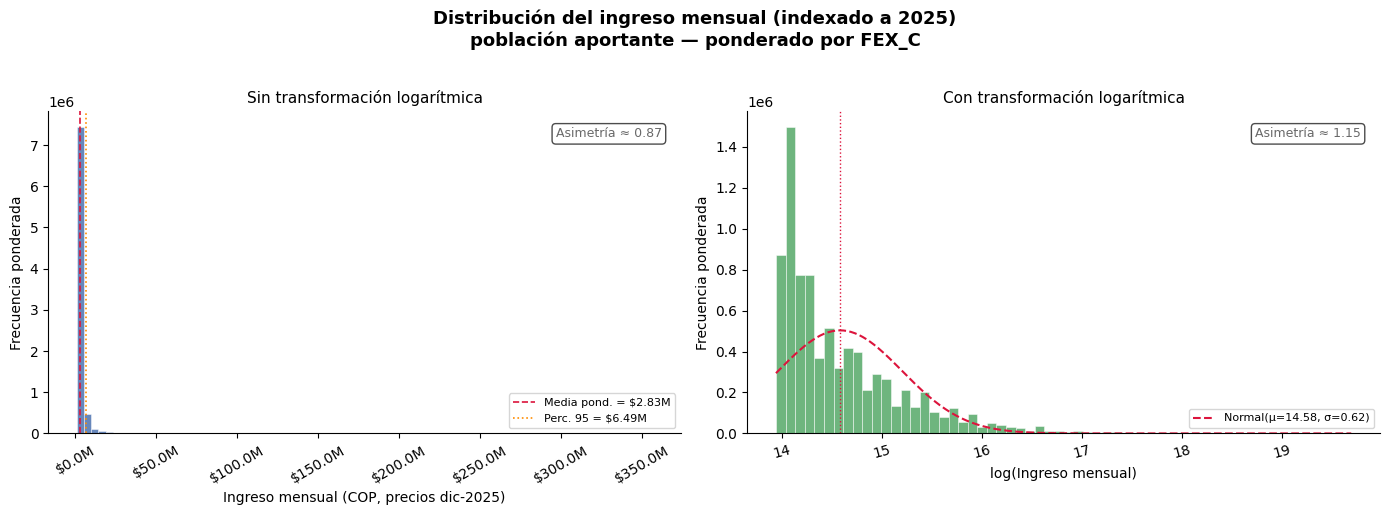

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Distribución del ingreso mensual (indexado a 2025)\npoblación aportante — ponderado por FEX_C",
    fontsize=13, fontweight="bold", y=1.02
)

# FEX_C puede venir con coma decimal (formato DANE) → normalizar a float
_fex = gastos_objetivo_final["FEX_C"]
if _fex.dtype == object:
    _fex = _fex.str.replace(',', '.', regex=False)
pesos = _fex.astype(float).values
ingresos_raw = gastos_objetivo_final["INGRESOS_AL_2025"].values
ingresos_log = gastos_objetivo_final["log_ingresos_2025"].values

# ── Panel izquierdo: sin transformación ──────────────────────────────────────
ax0 = axes[0]
ax0.hist(
    ingresos_raw, bins=80, weights=pesos,
    color="#4C72B0", edgecolor="white", linewidth=0.4, alpha=0.85
)
ax0.set_title("Sin transformación logarítmica", fontsize=11)
ax0.set_xlabel("Ingreso mensual (COP, precios dic-2025)", fontsize=10)
ax0.set_ylabel("Frecuencia ponderada", fontsize=10)
ax0.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)
ax0.tick_params(axis="x", rotation=30)

med_raw = np.average(ingresos_raw, weights=pesos)
p95_raw = np.percentile(ingresos_raw, 95)
ax0.axvline(med_raw, color="crimson", linestyle="--", linewidth=1.2,
            label=f"Media pond. = ${med_raw/1_000_000:.2f}M")
ax0.axvline(p95_raw, color="darkorange", linestyle=":", linewidth=1.2,
            label=f"Perc. 95 = ${p95_raw/1_000_000:.2f}M")
ax0.legend(fontsize=8)

skew_raw = (
    3 * (np.average(ingresos_raw, weights=pesos) -
         np.median(ingresos_raw)) /
    np.sqrt(np.cov(ingresos_raw, aweights=pesos))
)
ax0.text(0.97, 0.95, f"Asimetría ≈ {skew_raw:.2f}",
         transform=ax0.transAxes, ha="right", va="top",
         fontsize=9, color="dimgrey",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
ax0.spines[["top", "right"]].set_visible(False)

# ── Panel derecho: con transformación logarítmica ────────────────────────────
ax1 = axes[1]
ax1.hist(
    ingresos_log, bins=60, weights=pesos,
    color="#55A868", edgecolor="white", linewidth=0.4, alpha=0.85
)
ax1.set_title("Con transformación logarítmica", fontsize=11)
ax1.set_xlabel("log(Ingreso mensual)", fontsize=10)
ax1.set_ylabel("Frecuencia ponderada", fontsize=10)
ax1.tick_params(axis="x", rotation=15)

mu_log = np.average(ingresos_log, weights=pesos)
sigma_log = np.sqrt(np.cov(ingresos_log, aweights=pesos))
x_norm = np.linspace(ingresos_log.min(), ingresos_log.max(), 300)
from scipy.stats import norm as sp_norm
total_w = pesos.sum()
bin_width = (ingresos_log.max() - ingresos_log.min()) / 60
y_norm = sp_norm.pdf(x_norm, mu_log, sigma_log) * total_w * bin_width
ax1.plot(x_norm, y_norm, color="crimson", linewidth=1.5,
         linestyle="--", label=f"Normal(μ={mu_log:.2f}, σ={sigma_log:.2f})")
ax1.axvline(mu_log, color="crimson", linestyle=":", linewidth=1.0)

skew_log = (
    3 * (np.average(ingresos_log, weights=pesos) -
         np.median(ingresos_log)) /
    sigma_log
)
ax1.text(0.97, 0.95, f"Asimetría ≈ {skew_log:.2f}",
         transform=ax1.transAxes, ha="right", va="top",
         fontsize=9, color="dimgrey",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
ax1.legend(fontsize=8)
ax1.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
ruta_fig = "figuras/distribucion_ingreso_log_vs_raw.png"
fig.savefig(ruta_fig, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_fig}")
plt.show()

### Homologación de variables


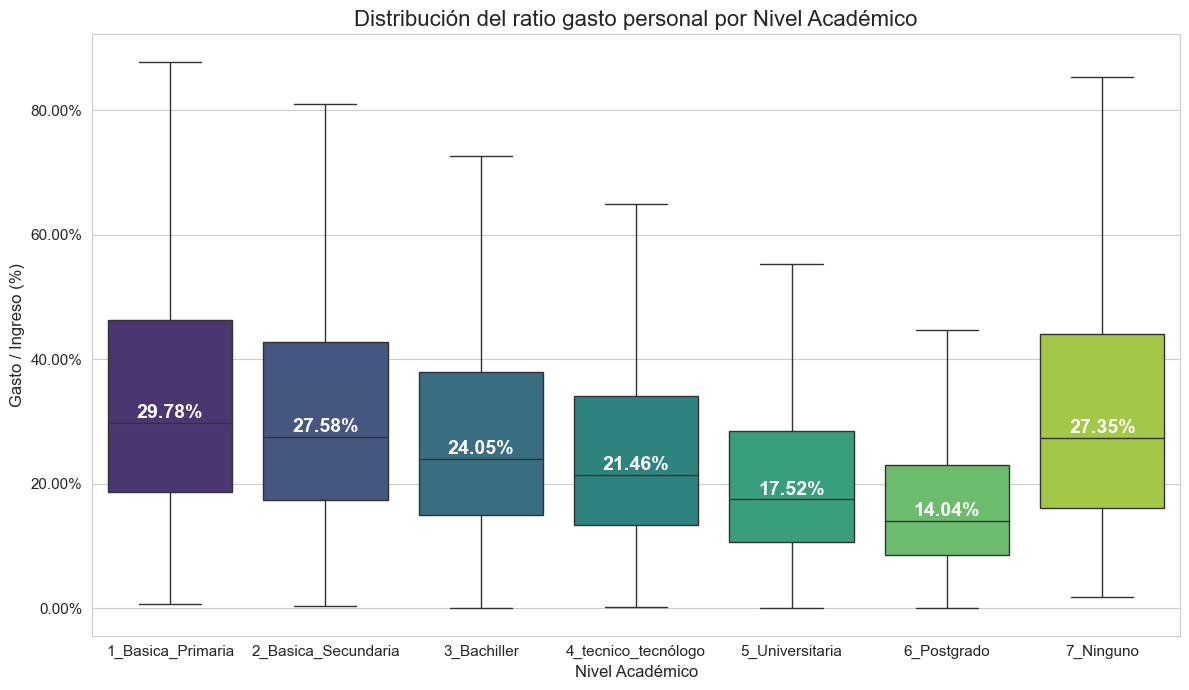

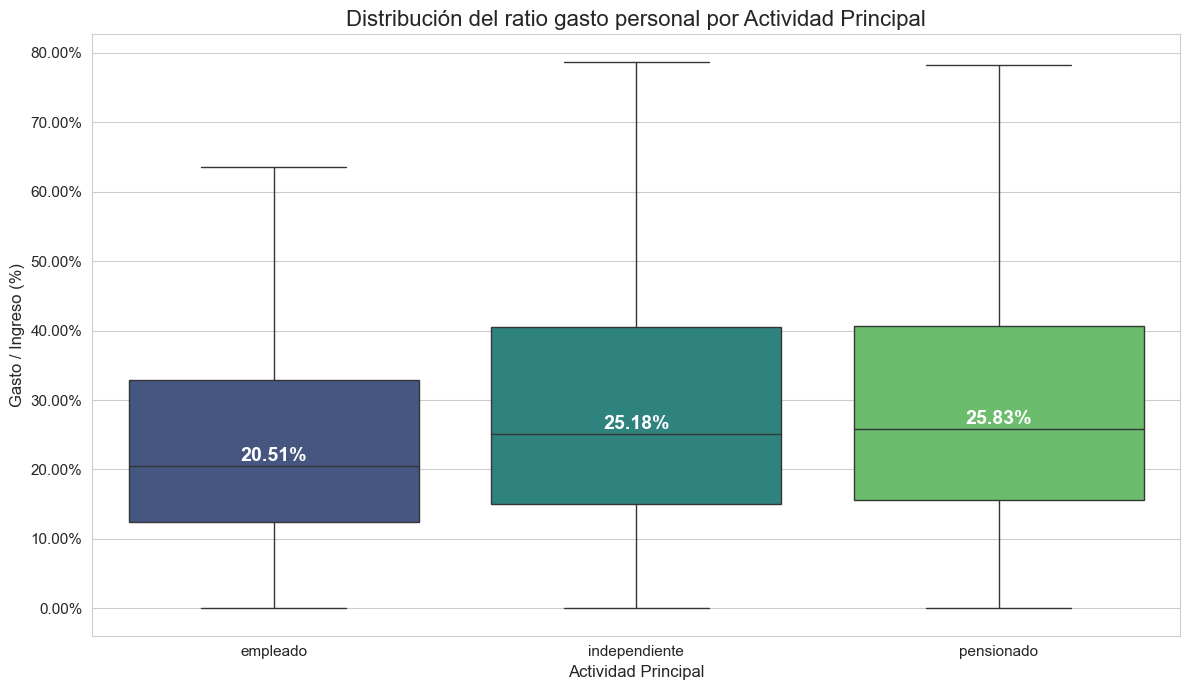

In [ ]:
df_temp_=gastos_objetivo_final.copy()

df_temp_.columns

df_temp_['Sexo_'] = df_temp_['Sexo'].replace({1: 'Hombre', 2: 'Mujer'})
df_temp_['EstadoCivil_'] = df_temp_['Estado_Civil'].replace({'1':'No esta casado(a) y vive en pareja hace menos de dos años','2':'No esta casado(a) y vive en pareja hace dos años o más','3':'Esta viudo (a)','4':'Esta separado(a) o divorciado(a)', '5':'Esta soltero (a)','6':'Esta casado (a)'})
df_temp_['NivelAcademico_def'] = df_temp_['NivelAcademico_def'].replace({'3_ Bachiller': '3_Bachiller'})
df_temp_['ClaseVivienda_'] = df_temp_['Clase_Vivienda'].replace({1: 'Casa', 2: 'Apartamento', 3: 'Cuarto (s) en inquilinato', 4: 'Cuarto (s) en otro tipo de estructura', 5: 'Vivienda indígena', 6: 'Otra vivienda (carpa, vagón, embarcación, cueva, refugio natural, etc.)'})
df_temp_['TipoVivienda_'] = df_temp_['Tipo_Vivienda'].replace({1: 'Propia, totalmente pagada', 2: 'Propia, la están pagando', 3: 'En arriendo o subarriendo', 4: 'En usufructo', 5: 'Posesión sin titulo (Ocupante de hecho) ó propiedad colectiva', 6: 'Otra'})

df_temp_a = df_temp_[[
    'DIRECTORIO_x', 'Id_Person', 'Edad', 'Estrato', 'REGION', 'DOMINIO',
    'PERIODO', 'NivelAcademico_def', 'DESC_DIVISION', 'agrup_seccion',
    'Antigüedad_Actividad', 'ingreso_mensual_total', 'actividad_ppal',
    'Aportantes_Hogar', 'F01', 'F02', 'F03', 'F04',
    'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'GastoMes',
    'RatioGastos', 'ingreso_smmlv_', 'F01_2025', 'F02_2025', 'F03_2025',
    'F04_2025', 'F05_2025', 'F06_2025', 'F07_2025', 'F08_2025', 'F09_2025',
    'F10_2025', 'F11_2025', 'F12_2025', 'GASTOS_AL_2025',
    'INGRESOS_AL_2025', 'AÑO', 'SMMLV_2025_EQ', 'log_ingresos_2025',
    'log_gastos_2025', 'log_SMMLV_2025_EQ', 'log_ratio_ingreso',
    'Sexo_', 'EstadoCivil_', 'ClaseVivienda_','TipoVivienda_', 'FEX_C'
]].copy()

df_temp_a['Antigüedad_Actividad'] = (
    pd.to_numeric(df_temp_a['Antigüedad_Actividad'], errors='coerce')
    .astype('Int64')
)

df_temp_a['ratio_gastos_2025'] = (
    df_temp_a['GASTOS_AL_2025'] / df_temp_a['INGRESOS_AL_2025']
)

df_temp_a['INGRESOS_AL_2025'] = (
    df_temp_a['INGRESOS_AL_2025']
    .round(0)
    .astype('Int64')
)

df_temp_a['GASTOS_AL_2025'] = (
    df_temp_a['GASTOS_AL_2025']
    .round(0)
    .astype('Int64')
)

import pandas as pd
pd.options.display.float_format = lambda x: f"{x:.2f}".replace('.', ',')
tabla_educacion = (
    df_temp_a
    .groupby('NivelAcademico_def')
    .agg(
        n_obs=('INGRESOS_AL_2025', 'count'),
        ingreso_media=('INGRESOS_AL_2025', 'mean'),
        ingreso_mediana=('INGRESOS_AL_2025', 'median'),
        gasto_media=('GASTOS_AL_2025', 'mean'),
        gasto_mediana=('GASTOS_AL_2025', 'median'),
        ratio_medio=('ratio_gastos_2025', 'mean'),
        ratio_mediana=('ratio_gastos_2025', 'median')
    )
    .reset_index()
)


# Asegurar ratios como float (normalmente ya lo son)
cols_ratio = ['ratio_medio', 'ratio_mediana']
tabla_educacion[cols_ratio] = tabla_educacion[cols_ratio].astype(float)

df_temp_a.columns

df_temp_a['nivel_educ_agrupado'] = df_temp_a['NivelAcademico_def'].astype(str)

# Reglas de agrupación
df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '1_Basica_Primaria',
        '7_Ninguno'
    ]),
    'nivel_educ_agrupado'
] = 'a_Bajo'

df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '2_Basica_Secundaria',
        '3_Bachiller'
    ]),
    'nivel_educ_agrupado'
] = 'b_Medio_bajo'

df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '4_tecnico_tecnólogo'
    ]),
    'nivel_educ_agrupado'
] = 'c_Medio_alto'

df_temp_a.loc[
    df_temp_a['NivelAcademico_def'].isin([
        '5_Universitaria',
        '6_Postgrado'
    ]),
    'nivel_educ_agrupado'
] = 'd_Alto'

# Excluir "No informa"
df_temp_a = df_temp_a[df_temp_a['NivelAcademico_def'] != '8_No_Informa']

tabla_educ_agr = (
    df_temp_a
    .groupby('nivel_educ_agrupado')
    .agg(
        n_obs=('INGRESOS_AL_2025', 'count'),
        ingreso_mediana=('INGRESOS_AL_2025', 'median'),
        gasto_mediana=('GASTOS_AL_2025', 'median'),
        ratio_mediana=('ratio_gastos_2025', 'median')
    )
    .reset_index()
)

tabla_educ_agr

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Definir orden alfabético de los niveles
# --------------------------------------------------
orden_alfabetico = sorted(df_temp_a['NivelAcademico_def'].dropna().unique())

# Calcular medianas y reordenarlas alfabéticamente
medianas_gasto = (
    df_temp_a
    .groupby('NivelAcademico_def')['ratio_gastos_2025']
    .median()
    .reindex(orden_alfabetico)
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='NivelAcademico_def',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=orden_alfabetico,   # 🔹 orden alfabético
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, nivel in enumerate(orden_alfabetico):
    valor = medianas_gasto[nivel]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Nivel Académico', fontsize=16)
plt.xlabel('Nivel Académico', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Definir orden alfabético de la actividad principal
# --------------------------------------------------
orden_alfabetico = sorted(df_temp_a['actividad_ppal'].dropna().unique())

# Calcular medianas y reordenarlas alfabéticamente
medianas_gasto = (
    df_temp_a
    .groupby('actividad_ppal')['ratio_gastos_2025']
    .median()
    .reindex(orden_alfabetico)
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='actividad_ppal',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=orden_alfabetico,   # 🔹 orden alfabético
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, actividad in enumerate(orden_alfabetico):
    valor = medianas_gasto[actividad]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Actividad Principal', fontsize=16)
plt.xlabel('Actividad Principal', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import plotly.express as px

fig = px.scatter(
    df_temp_a,
    x='log_ingresos_2025',
    y='log_gastos_2025',
    color='actividad_ppal', # Usa 'color' para diferenciar por actividad principal
    opacity=0.3,
    title='Relación ingreso–gasto por actividad principal (Interactivo)',

    labels={
        'log_ingresos_2025': 'log(Ingreso 2025)',
        'log_gastos_2025': 'log(Gasto 2025)',
        'actividad_ppal': 'Actividad Principal'
    }
)

fig.update_layout(showlegend=True) # Asegura que la leyenda sea visible para la interactividad
fig.show()

import pandas as pd
import numpy as np

df_temp_a['Antigüedad_Actividad'] = pd.to_numeric(
    df_temp_a['Antigüedad_Actividad'],
    errors='coerce'
)

# 1️⃣ Convertir Antigüedad_Actividad de object a numérico
df_temp_a['Antigüedad_Actividad'] = pd.to_numeric(
    df_temp_a['Antigüedad_Actividad'],
    errors='coerce'
)

# 2️⃣ Definir condiciones (boolean numpy, sin NA)
condiciones = [
    df_temp_a['Antigüedad_Actividad'].isin([998, 999]).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(0, 5).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(6, 12).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(13, 36).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(37, 72).fillna(False).to_numpy(),
    df_temp_a['Antigüedad_Actividad'].between(73, 120).fillna(False).to_numpy(),
    (df_temp_a['Antigüedad_Actividad'] >= 121).fillna(False).to_numpy()
]

# 3️⃣ Valores (labels consistentes)
valores = [
    'g_desconoce',
    'a_inserción_laboral_0_5',
    'b_adaptacion_al_empleo_6_12',
    'c_ingreso_predecible_13_36',
    'd_trayectoria_estable_37_72',
    'e_alta_estabilidad_73_120',
    'f_trayectoria_excepcional_121_mas'
]

# 4️⃣ Crear variable agrupada
df_temp_a['antiguedad_agrup'] = np.select(
    condiciones,
    valores,
    default=None
)

# 5️⃣ Reemplazar NA restantes por 'g_desconoce'
df_temp_a['antiguedad_agrup'] = df_temp_a['antiguedad_agrup'].fillna('g_desconoce')

# 6️⃣ Convertir a categórica ordenada
orden = [
    'a_inserción_laboral_0_5',
    'b_adaptacion_al_empleo_6_12',
    'c_ingreso_predecible_13_36',
    'd_trayectoria_estable_37_72',
    'e_alta_estabilidad_73_120',
    'f_trayectoria_excepcional_121_mas',
    'g_desconoce'
]

df_temp_a['antiguedad_agrup'] = pd.Categorical(
    df_temp_a['antiguedad_agrup'],
    categories=orden,
    ordered=True
)

(
    df_temp_a
    .loc[df_temp_a['antiguedad_agrup'] == 'g_desconoce']
    .groupby('actividad_ppal')
    .agg(n_obs=('actividad_ppal', 'count'))
    .sort_values('n_obs', ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

# Calcular medianas
medianas_gasto = (
    df_temp_a
    .groupby('antiguedad_agrup')['GASTOS_AL_2025']
    .median()
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='antiguedad_agrup',
    y='GASTOS_AL_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    ax=plt.gca()
)

# Anotar las medianas
for i, antiguedad in enumerate(medianas_gasto.index):
    valor = medianas_gasto[antiguedad]
    ax.text(
        i, valor + (df_temp_a['GASTOS_AL_2025'].max() * 0.01), # Ajustar la posición vertical
        f'{valor:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.'), # Formato de miles
        ha='center',
        va='bottom',
        fontsize=10,
        color='white'
    )

plt.title('Distribución del gasto personal por antigüedad en la actividad', fontsize=16)
plt.xlabel('Antigüedad en la actividad', fontsize=12)
plt.ylabel('Gasto personal (pesos)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

import pandas as pd

# Define age bins and labels
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

# Create 'Grupo_Edad' column
df_temp_a['Grupo_Edad'] = pd.cut(df_temp_a['Edad'], bins=bins, labels=labels, right=False)

# Display value counts of the new column
print("Distribución de individuos por grupo de edad:")
print(df_temp_a['Grupo_Edad'].value_counts().sort_index())

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Calcular medianas
medianas_gasto = (
    df_temp_a
    .groupby('Grupo_Edad')['ratio_gastos_2025']
    .median()
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='Grupo_Edad',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (más grandes y con 2 decimales)
for i, antiguedad in enumerate(medianas_gasto.index):
    valor = medianas_gasto[antiguedad]
    ax.text(
        i,
        valor + (df_temp_a['ratio_gastos_2025'].max() * 0.01),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,      # 🔹 más grande
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Edad', fontsize=16)
plt.xlabel('Rango edad', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib

print("seaborn:", sns.__version__)
print("matplotlib:", matplotlib.__version__)

df_temp_a.columns

df_temp_a['EstadoCivil_'].unique()

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Homologación de etiquetas (más cortas)
# --------------------------------------------------
estado_civil_map = {
    'No esta casado(a) y vive en pareja hace menos de dos años': 'Pareja < 2 años',
    'No esta casado(a) y vive en pareja hace dos años o más': 'Pareja ≥ 2 años',
    'Esta viudo (a)': 'Viudo(a)',
    'Esta separado(a) o divorciado(a)': 'Separado/Divorciado',
    'Esta soltero (a)': 'Soltero(a)',
    'Esta casado (a)': 'Casado(a)'
}

# Crear variable homologada
df_temp_a['EstadoCivil_hom'] = df_temp_a['EstadoCivil_'].map(estado_civil_map)

# Orden explícito según tu codificación a–f
estado_civil_labels = [
    'Pareja < 2 años',
    'Pareja ≥ 2 años',
    'Viudo(a)',
    'Separado/Divorciado',
    'Soltero(a)',
    'Casado(a)'
]

# Calcular medianas respetando el orden
medianas_gasto = (
    df_temp_a
    .groupby('EstadoCivil_hom')['ratio_gastos_2025']
    .median()
    .reindex(estado_civil_labels)
)

sns.set_style("whitegrid")

plt.figure(figsize=(13, 7))

ax = sns.boxplot(
    x='EstadoCivil_hom',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=estado_civil_labels,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas cerca de la línea
for i, estado in enumerate(estado_civil_labels):
    valor = medianas_gasto[estado]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Estado Civil', fontsize=16)
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Agrupación y homologación de Aportantes_Hogar
# --------------------------------------------------
bins_aportantes = [1, 2, 3, 5, df_temp_a['Aportantes_Hogar'].max() + 1]
labels_aportantes = [
    'Hogares unipersonales',  # 1 aportante
    'Hogares pequeños',       # 2 aportantes
    'Hogares medianos',       # 3-4 aportantes
    'Hogares grandes'         # 5 o más aportantes
]

df_temp_a['Grupo_Aportantes'] = pd.cut(
    df_temp_a['Aportantes_Hogar'],
    bins=bins_aportantes,
    labels=labels_aportantes,
    right=False,
    include_lowest=True
)

# --------------------------------------------------
# Calcular medianas respetando el orden definido
# --------------------------------------------------
medianas_gasto = (
    df_temp_a
    .groupby('Grupo_Aportantes')['ratio_gastos_2025']
    .median()
    .reindex(labels_aportantes)
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='Grupo_Aportantes',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=labels_aportantes,   # 🔹 orden conceptual
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, grupo in enumerate(labels_aportantes):
    valor = medianas_gasto[grupo]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Aportantes del Hogar', fontsize=16)
plt.xlabel('Tipo de hogar según aportantes', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Reasignación directa de Estrato (según tu lógica)
# --------------------------------------------------
def reasignar_estrato_directo(estrato_valor):
    if pd.isna(estrato_valor) or str(estrato_valor).strip() == '':
        return 2  # Asignar 2 a valores vacíos
    elif estrato_valor == 0 or str(estrato_valor) == '0' or estrato_valor == 9 or str(estrato_valor) == '9':
        return 1  # Asignar 1 a 0 y 9
    else:
        try:
            return int(estrato_valor)
        except ValueError:
            return estrato_valor

# Aplicar reasignación
df_temp_a['Estrato'] = df_temp_a['Estrato'].apply(reasignar_estrato_directo)

# --------------------------------------------------
# Definir orden de estratos (ascendente)
# --------------------------------------------------
estrato_labels = sorted(df_temp_a['Estrato'].dropna().unique())

# Calcular medianas respetando el orden
medianas_gasto = (
    df_temp_a
    .groupby('Estrato')['ratio_gastos_2025']
    .median()
    .reindex(estrato_labels)
)

sns.set_style("whitegrid")

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    x='Estrato',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=estrato_labels,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas (cerca de la línea)
for i, estrato in enumerate(estrato_labels):
    valor = medianas_gasto[estrato]
    ax.text(
        i,
        valor + (valor * 0.005),
        f'{valor*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por Estrato', fontsize=16)
plt.xlabel('Estrato socioeconómico', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define labels for Estrato_Reasignado to ensure consistent order
estrato_reasignado_labels = sorted(df_temp_a['Estrato'].unique()) # Sort for logical order

# Apply Seaborn style as requested
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6)) # Adjust figure size for Estrato

# Use Seaborn for the boxplot with specified palette and hidden outliers
ax = sns.boxplot(
    x='Estrato',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis', # Apply specified palette
    showfliers=False,  # Hide outliers as requested
    order=estrato_reasignado_labels # Ensure correct order of categories
)

# Calculate medians (explicitly setting observed=False for categorical groupby to suppress FutureWarning)
medians = df_temp_a.groupby('Estrato', observed=False)['ratio_gastos_2025'].median()

# Loop through each box and add median annotation with specified formatting
for i, group in enumerate(estrato_reasignado_labels): # Use 'estrato_reasignado_labels' to iterate through ordered groups
    if group in medians.index: # Check if median exists for the group
        median_val = medians[group]
        ax.text(
            i, median_val + 0.01, # Place just above the median line
            f'{median_val:.2f}',
            ha='center',
            va='bottom',
            fontsize=12,
            color='white',
            weight='semibold'
        )

plt.title('Distribución de ratio_gastos_2025 por Estrato (Sin Outliers y con Mediana)', fontsize=16) # Title with specific fontsize
plt.suptitle('') # Suppress automatic suptitle
plt.xlabel('Estrato', fontsize=12) # X-label with specific fontsize
plt.ylabel('ratio_gastos_2025', fontsize=12) # Y-label with specific fontsize

plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-tick labels and set fontsize
plt.yticks(fontsize=10) # Set y-tick fontsize
plt.grid(axis='y', linestyle='--', alpha=0.7) # Keep grid
plt.tight_layout() # Adjust layout
plt.show()

# 1. Dominios metropolitanos principales
dominio_metro_principal = [
    'BOGOTÁ',
    'MEDELLÍN Y A.M.',
    'CALI',
    'BARRANQUILLA'
]

# 2. Dominios metropolitanos regionales
dominio_metro_regional = [
    'BUCARAMANGA Y A.M.',
    'PEREIRA Y A.M.',
    'MANIZALEZ Y A.M.',
    'CÚCUTA Y A.M.'
]

# 3. Ciudades intermedias
dominio_intermedias = [
    'CARTAGENA', 'SANTA MARTA', 'IBAGUÉ', 'NEIVA',
    'VILLAVICENCIO', 'MONTERÍA', 'VALLEDUPAR',
    'SINCELEJO', 'TUNJA'
]

# 4. Periferia urbana / satélites
dominio_periferia = [
    'SOLEDAD', 'YUMBO', 'RIONEGRO', 'BARRANCABERMEJA'
]

def agrupar_dominio(dominio):
    if dominio in dominio_metro_principal:
        return 'a_Metro_principal'
    elif dominio in dominio_metro_regional:
        return 'b_Metro_regional'
    elif dominio in dominio_intermedias:
        return 'c_Ciudad_intermedia'
    elif dominio in dominio_periferia:
        return 'd_Periferia_urbana'
    else:
        return 'e_Resto'

df_temp_a['dominio_agrup'] = df_temp_a['DOMINIO'].apply(agrupar_dominio)

df_temp_a['dominio_agrup'].value_counts(normalize=True).round(3)

import numpy as np

df_temp_a['tipo_vivienda_agrup'] = np.select(
    [
        df_temp_a['TipoVivienda_'] == 'Propia, totalmente pagada',
        df_temp_a['TipoVivienda_'] == 'Propia, la están pagando',
        df_temp_a['TipoVivienda_'] == 'En arriendo o subarriendo',
        df_temp_a['TipoVivienda_'].isin([
            'En usufructo',
            'Posesión sin titulo (Ocupante de hecho) ó prop...',
            'Otra'
        ])
    ],
    [
        'propia_pagada',
        'propia_en_pago',
        'arriendo',
        'tenencia_no_formal'
    ],
    default='otros'
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Definir orden lógico de tipo de vivienda agrupado
# --------------------------------------------------
tipo_vivienda_labels = [
    'tenencia_no_formal',
    'arriendo',
    'propia_pagada',
    'propia_en_pago'
]

# Calcular medianas respetando el orden
medianas_gasto = (
    df_temp_a
    .groupby('tipo_vivienda_agrup')['ratio_gastos_2025']
    .median()
    .reindex(tipo_vivienda_labels)
)

sns.set_style("whitegrid")

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    x='tipo_vivienda_agrup',
    y='ratio_gastos_2025',
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    order=tipo_vivienda_labels,
    ax=plt.gca()
)

# --------------------------------------------------
# Eje Y en porcentaje con 2 decimales
# --------------------------------------------------
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# --------------------------------------------------
# Anotar medianas
# --------------------------------------------------
for i, grupo in enumerate(tipo_vivienda_labels):
    valor = medianas_gasto[grupo]
    if pd.notna(valor):
        ax.text(
            i,
            valor + (valor * 0.005),
            f'{valor*100:.2f}%',
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold',
            color='white'
        )

# --------------------------------------------------
# Títulos y etiquetas
# --------------------------------------------------
plt.title('Distribución del ratio gasto personal según tipo de tenencia de vivienda', fontsize=16)
plt.xlabel('Tipo de tenencia de la vivienda', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


def estadisticos_ponderados(df, var, peso='FEX_C'):
    """Calcula media y mediana ponderadas."""
    w = pd.to_numeric(
        df[peso].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)
    
    x = pd.to_numeric(df[var], errors='coerce')
    mask = x.notna() & w.notna()
    x, w = x[mask].values, w[mask].values
    
    # Media ponderada
    media_w = np.average(x, weights=w)
    
    # Mediana ponderada
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cumw = w_s.cumsum() / w_s.sum()
    mediana_w = x_s[(cumw >= 0.5).argmax()]
    
    return round(media_w, 0), round(mediana_w, 0)




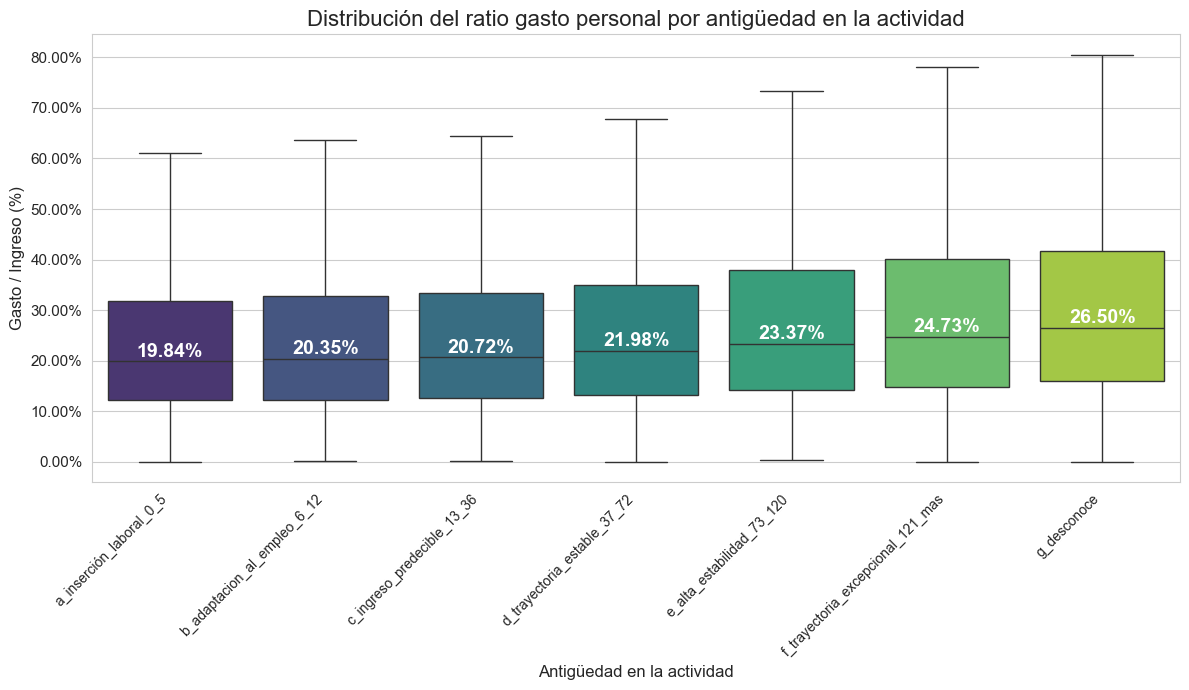

In [39]:
# Calcular medianas del ratio
medianas_gasto = (
    df_temp_a
    .groupby('antiguedad_agrup')['ratio_gastos_2025']
    .median()
)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    x='antiguedad_agrup',
    y='ratio_gastos_2025',          # 🔹 ratio en lugar de gasto absoluto
    data=df_temp_a,
    palette='viridis',
    showfliers=False,
    ax=plt.gca()
)

# Eje Y en porcentaje con 2 decimales
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y*100:.2f}%')
)

# Anotar medianas
for i, antiguedad in enumerate(medianas_gasto.index):
    valor = medianas_gasto[antiguedad]
    ax.text(
        i,
        valor + (valor * 0.005),    # 🔹 offset proporcional al ratio
        f'{valor*100:.2f}%',        # 🔹 formato porcentaje con 2 decimales
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('Distribución del ratio gasto personal por antigüedad en la actividad', fontsize=16)
plt.xlabel('Antigüedad en la actividad', fontsize=12)
plt.ylabel('Gasto / Ingreso (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### DF para modelar


In [40]:
#dataframe para modelar
print(df_temp_a.shape)
df_temp_a.columns

#crea la variable pensionado como flag debido a que la antiguedad en la actividad los que dicen g_desconoce son pensionados

df_temp_a['flag_pensionado'] = np.where(
    df_temp_a['actividad_ppal'] == 'pensionado',
    'es_pensionado',
    'no_es_pensionado'

)

df_temp_a.columns


(59776, 62)


Index(['DIRECTORIO_x', 'Id_Person', 'Edad', 'Estrato', 'REGION', 'DOMINIO',
       'PERIODO', 'NivelAcademico_def', 'DESC_DIVISION', 'agrup_seccion',
       'Antigüedad_Actividad', 'ingreso_mensual_total', 'actividad_ppal',
       'Aportantes_Hogar', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07',
       'F08', 'F09', 'F10', 'F11', 'F12', 'GastoMes', 'RatioGastos',
       'ingreso_smmlv_', 'F01_2025', 'F02_2025', 'F03_2025', 'F04_2025',
       'F05_2025', 'F06_2025', 'F07_2025', 'F08_2025', 'F09_2025', 'F10_2025',
       'F11_2025', 'F12_2025', 'GASTOS_AL_2025', 'INGRESOS_AL_2025', 'AÑO',
       'SMMLV_2025_EQ', 'log_ingresos_2025', 'log_gastos_2025',
       'log_SMMLV_2025_EQ', 'log_ratio_ingreso', 'Sexo_', 'EstadoCivil_',
       'ClaseVivienda_', 'TipoVivienda_', 'FEX_C', 'ratio_gastos_2025',
       'nivel_educ_agrupado', 'antiguedad_agrup', 'Grupo_Edad',
       'EstadoCivil_hom', 'Grupo_Aportantes', 'dominio_agrup',
       'tipo_vivienda_agrup', 'flag_pensionado'],
      dtype='obj

### Figura 3. Distribución del ingreso indexado a Dic. 2025

Histogramas ponderados por `FEX_C` del ingreso mensual total (en escala original y logarítmica). La asimetría positiva del panel izquierdo justifica la transformación logarítmica aplicada en el modelo WLS.

In [ ]:
# ============================================================
# FIGURA 3. Distribución del ingreso indexado a Dic. 2025
# Histogramas ponderados por FEX_C — escala original y logarítmica
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# FEX_C puede venir con coma decimal (formato DANE) → normalizar a float
_fex = df_temp_a['FEX_C']
if _fex.dtype == object:
    _fex = _fex.str.replace(',', '.', regex=False)
pesos        = _fex.astype(float).values
log_ing      = df_temp_a['log_ingresos_2025'].values
ing_millones = np.exp(log_ing) / 1_000_000   # COP 2025 → millones

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

# ── Panel izquierdo: ingreso sin transformar ────────────────────────────────
ax0 = axes[0]
ax0.hist(ing_millones, bins=60, weights=pesos,
         color='steelblue', edgecolor='white', linewidth=0.3)
ax0.set_title('Distribución del ingreso sin transformación\nlogarítmica', fontsize=12)
ax0.set_xlabel('Ingresos (millones de pesos indexados 2025)', fontsize=10)
ax0.set_ylabel('Frecuencia', fontsize=10)
ax0.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f} M'))
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
skew_raw = stats.skew(ing_millones)
ax0.annotate(f'Asimetría: {skew_raw:.2f}', xy=(0.97, 0.97),
             xycoords='axes fraction', ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax0.spines[['top', 'right']].set_visible(False)

# ── Panel derecho: log(ingreso) ─────────────────────────────────────────────
ax1 = axes[1]
ax1.hist(log_ing, bins=60, weights=pesos,
         color='steelblue', edgecolor='white', linewidth=0.3)
ax1.set_title('Distribución del ingreso con transformación\nlogarítmica', fontsize=12)
ax1.set_xlabel('log(Ingresos)', fontsize=10)
ax1.set_ylabel('Frecuencia', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
skew_log = stats.skew(log_ing)
ax1.annotate(f'Asimetría: {skew_log:.2f}', xy=(0.97, 0.97),
             xycoords='axes fraction', ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax1.spines[['top', 'right']].set_visible(False)

fig.text(0.5, -0.04,
         'Figura 3. Distribución del ingreso indexado a Dic. 2025',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('figuras/fig03_distribucion_ingreso.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en figuras/fig03_distribucion_ingreso.png")

In [ ]:
# ============================================================
# FIGURA 3B. Distribución del ingreso: Con FEX_C vs Sin FEX_C
# Barras superpuestas – mismo estilo visual que Figura 3
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats

_fex = df_temp_a['FEX_C']
if _fex.dtype == object:
    _fex = _fex.str.replace(',', '.', regex=False)
pesos        = _fex.astype(float).values
log_ing      = df_temp_a['log_ingresos_2025'].values
ing_millones = np.exp(log_ing) / 1_000_000

BINS = 60

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

# ── Panel izquierdo: ingreso en millones ─────────────────────
ax0 = axes[0]
ax0.hist(ing_millones, bins=BINS, weights=pesos,
         color='#4472C4', edgecolor='white', linewidth=0.4,
         alpha=0.75, label='Con FEX_C (ponderado)')
ax0.hist(ing_millones, bins=BINS,
         color='#ED7D31', edgecolor='white', linewidth=0.4,
         alpha=0.65, label='Sin FEX_C (muestral)')
ax0.set_title('Distribución del ingreso sin transformación\nlogarítmica', fontsize=12)
ax0.set_xlabel('Ingresos (millones de pesos indexados 2025)', fontsize=10)
ax0.set_ylabel('Frecuencia', fontsize=10)
ax0.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f} M'))
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
skew_raw = stats.skew(ing_millones)
ax0.annotate(f'Asimetría: {skew_raw:.2f}', xy=(0.97, 0.97),
             xycoords='axes fraction', ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax0.legend(fontsize=9, loc='upper right', bbox_to_anchor=(0.97, 0.88))
ax0.spines[['top', 'right']].set_visible(False)

# ── Panel derecho: log(ingreso) ──────────────────────────
ax1 = axes[1]
ax1.hist(log_ing, bins=BINS, weights=pesos,
         color='#4472C4', edgecolor='white', linewidth=0.4,
         alpha=0.75, label='Con FEX_C (ponderado)')
ax1.hist(log_ing, bins=BINS,
         color='#ED7D31', edgecolor='white', linewidth=0.4,
         alpha=0.65, label='Sin FEX_C (muestral)')
ax1.set_title('Distribución del ingreso con transformación\nlogarítmica', fontsize=12)
ax1.set_xlabel('log(Ingresos)', fontsize=10)
ax1.set_ylabel('Frecuencia', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
skew_log = stats.skew(log_ing)
ax1.annotate(f'Asimetría: {skew_log:.2f}', xy=(0.97, 0.97),
             xycoords='axes fraction', ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax1.legend(fontsize=9, loc='upper right', bbox_to_anchor=(0.97, 0.88))
ax1.spines[['top', 'right']].set_visible(False)

fig.text(0.5, -0.04,
         'Figura 3B. Distribución del ingreso indexado a Dic. 2025 – Con FEX_C vs Sin FEX_C',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('figuras/fig03b_comparacion_ingreso_fexc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/fig03b_comparacion_ingreso_fexc.png')


## Validación poblacional: estadísticos ponderados por FEX_C

Los estadísticos anteriores corresponden a la muestra observada.
La siguiente tabla agrega las estimaciones ponderadas por FEX_C
para cada variable, permitiendo comparar la distribución muestral
frente a la población expandida. Las diferencias entre columnas
evidencian el efecto del diseño muestral y justifican el uso del
factor de expansión en todas las fases del análisis.

In [41]:
# ============================================================
# ANÁLISIS DESCRIPTIVO PONDERADO POR FEX_C
# Compara estadísticos muestrales vs. poblacionales
# ============================================================
import pandas as pd
import numpy as np

def estadisticos_ponderados(df, var, peso='FEX_C'):
    """Calcula media y mediana ponderadas por FEX_C."""
    w = pd.to_numeric(
        df[peso].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)
    x = pd.to_numeric(df[var], errors='coerce')
    mask = x.notna() & w.notna()
    x, w = x[mask].values, w[mask].values
    media_w = np.average(x, weights=w)
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cumw = w_s.cumsum() / w_s.sum()
    mediana_w = x_s[(cumw >= 0.5).argmax()]
    return round(media_w, 0), round(mediana_w, 0)


def tabla_ponderada(df, grupo_var, ing_var, gto_var, peso='FEX_C'):
    """
    Genera tabla con estadísticos muestrales y poblacionales
    para una variable de agrupación dada.
    """
    resultados = []
    for nombre, grupo in df.groupby(grupo_var, observed=True):
        media_w_ing, med_w_ing = estadisticos_ponderados(grupo, ing_var, peso)
        media_w_gto, med_w_gto = estadisticos_ponderados(grupo, gto_var, peso)
        resultados.append({
            'Grupo'                      : nombre,
            'n (muestra)'                : len(grupo),
            'Pob. expandida (∑FEX_C)'    : round(
                pd.to_numeric(
                    grupo[peso].astype(str).str.replace(',', '.', regex=False),
                    errors='coerce'
                ).sum(), 0),
            'Ingreso Mediana (muestra)'  : round(
                pd.to_numeric(grupo[ing_var], errors='coerce').median(), 0),
            'Ingreso Mediana (pob.)'     : med_w_ing,
            'Gasto Mediana (muestra)'    : round(
                pd.to_numeric(grupo[gto_var], errors='coerce').median(), 0),
            'Gasto Mediana (pob.)'       : med_w_gto,
        })
    return pd.DataFrame(resultados)


# ── Variables a usar ───────────────────────────────────────
ING = 'INGRESOS_AL_2025'
GTO = 'GASTOS_AL_2025'
df  = df_temp_a   # dataframe con todas las variables agrupadas ya creadas

# ── Tabla 1: Nivel educativo agrupado ─────────────────────
print("=" * 70)
print("TABLA: Nivel educativo agrupado")
print("=" * 70)
t1 = tabla_ponderada(df, 'nivel_educ_agrupado', ING, GTO)
display(t1)

# ── Tabla 2: Actividad principal ──────────────────────────
print("=" * 70)
print("TABLA: Actividad principal")
print("=" * 70)
t2 = tabla_ponderada(df, 'actividad_ppal', ING, GTO)
display(t2)

# ── Tabla 3: Antigüedad agrupada ──────────────────────────
print("=" * 70)
print("TABLA: Antigüedad en la actividad")
print("=" * 70)
t3 = tabla_ponderada(df, 'antiguedad_agrup', ING, GTO)
display(t3)

# ── Tabla 4: Grupo de edad ────────────────────────────────
print("=" * 70)
print("TABLA: Grupo de edad")
print("=" * 70)
t4 = tabla_ponderada(df, 'Grupo_Edad', ING, GTO)
display(t4)

# ── Tabla 5: Sexo ─────────────────────────────────────────
print("=" * 70)
print("TABLA: Sexo")
print("=" * 70)
t5 = tabla_ponderada(df, 'Sexo_', ING, GTO)
display(t5)

# ── Tabla 6: Estado civil ─────────────────────────────────
print("=" * 70)
print("TABLA: Estado civil")
print("=" * 70)
t6 = tabla_ponderada(df, 'EstadoCivil_hom', ING, GTO)
display(t6)

# ── Tabla 7: Aportantes del hogar ─────────────────────────
print("=" * 70)
print("TABLA: Aportantes del hogar")
print("=" * 70)
t7 = tabla_ponderada(df, 'Grupo_Aportantes', ING, GTO)
display(t7)

# ── Tabla 8: Estrato ──────────────────────────────────────
print("=" * 70)
print("TABLA: Estrato socioeconómico")
print("=" * 70)
t8 = tabla_ponderada(df, 'Estrato', ING, GTO)
display(t8)

# ── Tabla 9: Dominio agrupado ─────────────────────────────
print("=" * 70)
print("TABLA: Dominio geográfico agrupado")
print("=" * 70)
t9 = tabla_ponderada(df, 'dominio_agrup', ING, GTO)
display(t9)

# ── Tabla 10: Tipo de vivienda agrupado ───────────────────
print("=" * 70)
print("TABLA: Tipo de tenencia de vivienda")
print("=" * 70)
t10 = tabla_ponderada(df, 'tipo_vivienda_agrup', ING, GTO)
display(t10)

TABLA: Nivel educativo agrupado


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,a_Bajo,7156,"961498,00","1427168,00",1429442,"485116,00",498951
1,b_Medio_bajo,25770,"3535397,00","1479131,00",1485412,"426308,00",429125
2,c_Medio_alto,9598,"1380220,00","1651170,00",1764080,"412332,00",424358
3,d_Alto,17252,"2275981,00","2966833,00",3268972,"517768,00",566741


TABLA: Actividad principal


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,empleado,36591,"5285638,00","1622531,00",1648240,"401120,00",413380
1,independiente,16485,"2049940,00","1760324,00",1905923,"520730,00",559854
2,pensionado,6700,"817518,00","2223576,00",2229246,"623600,00",667756


TABLA: Antigüedad en la actividad


...

,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,1,12276,"1160460,00","1429442,00",1427168,"376705,00",372902
1,2,21756,"2689309,00","1588269,00",1529276,"415630,00",407572
2,3,17850,"3098133,00","1974024,00",1965603,"498622,00",501192
3,4,5169,"737003,00","3109983,00",3292142,"630800,00",666700
4,5,1808,"306354,00","4285425,00",4800885,"773254,00",835125
5,6,917,"161838,00","5767744,00",6492496,"1025182,00",1088041


TABLA: Dominio geográfico agrupado


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,a_Metro_principal,13352,"5521951,00","1712115,00",1785436,"464009,00",469418
1,b_Metro_regional,8785,"889487,00","1611643,00",1639527,"473534,00",487899
2,c_Ciudad_intermedia,16973,"1022201,00","1729258,00",1657041,"464957,00",459687
3,d_Periferia_urbana,7063,"249014,00","1606565,00",1543521,"446567,00",455475
4,e_Resto,13603,"470443,00","1902890,00",1803480,"425476,00",430900


TABLA: Tipo de tenencia de vivienda


,Grupo,n (muestra),Pob. expandida (∑FEX_C),Ingreso Mediana (muestra),Ingreso Mediana (pob.),Gasto Mediana (muestra),Gasto Mediana (pob.)
0,arriendo,23486,"3679814,00","1626202,00",1644572,"430140,00",432108
1,otros,1141,"110630,00","1447668,00",1460812,"402953,00",402349
2,propia_en_pago,2386,"440138,00","2292748,00",2378613,"524113,00",531525
3,propia_pagada,27834,"3317072,00","1902890,00",1947749,"475913,00",512085
4,tenencia_no_formal,4929,"605444,00","1560830,00",1582965,"438970,00",449457


## **Análisis descriptivo ponderado por FEX_C — corrección para revisión del jurado**

Esta sección complementa el análisis descriptivo presentado anteriormente para responder a la observación del jurado sobre la incorporación del factor de expansión calibrado **FEX_C** en todas las dimensiones del análisis. Por cada variable categórica de interés se construye una tabla con dos planos paralelos —muestral y poblacional expandido— que permite (i) reportar estadísticos representativos de la población colombiana de aportantes del hogar, (ii) hacer transparente el sesgo del muestreo de la ENPH respecto a la población, y (iii) cerrar con una **Tabla 19** que sintetiza las divergencias muestra-vs-expandido por variable.

El detalle metodológico se documenta en la Sección 5.4 del manuscrito y la lógica corresponde al script `script_descriptivos_ponderados.py` integrado a continuación.

### Helpers — estadística ponderada por FEX_C

In [42]:
# ============================================================
# Helpers — media, mediana, percentiles y IQR ponderados
# ============================================================
import numpy as np
import pandas as pd


def media_ponderada(x, w):
    """Media ponderada estándar: Σ(x·w) / Σw."""
    x = pd.to_numeric(x, errors="coerce").astype(float)
    w = pd.to_numeric(w, errors="coerce").astype(float)
    valid = ~(np.isnan(x) | np.isnan(w))
    if valid.sum() == 0:
        return np.nan
    return np.average(x[valid], weights=w[valid])


def percentil_ponderado(x, w, q):
    """Percentil ponderado: ordena por x y acumula los pesos hasta alcanzar q."""
    x = pd.to_numeric(x, errors="coerce").astype(float).values
    w = pd.to_numeric(w, errors="coerce").astype(float).values
    valid = ~(np.isnan(x) | np.isnan(w))
    x, w = x[valid], w[valid]
    if len(x) == 0:
        return np.nan
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cw = np.cumsum(w_s) / w_s.sum()
    i = np.searchsorted(cw, q)
    return x_s[min(i, len(x_s) - 1)]


def mediana_ponderada(x, w):
    return percentil_ponderado(x, w, 0.5)


def iqr_ponderado(x, w):
    return percentil_ponderado(x, w, 0.75) - percentil_ponderado(x, w, 0.25)

### Función resumen por categoría — variables monetarias

In [43]:
# ============================================================
# Resumen por categoría con planos muestral y expandido
# ============================================================
def resumen_categoria(df, col_cat, col_fex="FEX_C",
                      col_ingreso="INGRESOS_AL_2025",
                      col_gasto="GASTOS_AL_2025"):
    """
    Para cada categoría de col_cat devuelve N muestra/N expandido,
    porcentajes en cada plano, medianas e ingresos/gastos en plano
    muestral y expandido, diferencia en puntos porcentuales.
    """
    df = df.copy()
    df[col_fex] = pd.to_numeric(df[col_fex], errors="coerce").astype(float)
    n_total = len(df)
    n_exp_total = df[col_fex].sum()
    out = []
    for cat, grupo in df.groupby(col_cat):
        n_mue = len(grupo)
        n_exp = grupo[col_fex].sum()
        out.append({
            "Categoría": cat,
            "N muestra": n_mue,
            "N expandido": round(n_exp),
            "% muestra": round(n_mue / n_total * 100, 2),
            "% expandido": round(n_exp / n_exp_total * 100, 2),
            "Δ pp (exp - mue)": round(n_exp / n_exp_total * 100 - n_mue / n_total * 100, 2),
            "Ingreso media muestra": round(grupo[col_ingreso].mean()),
            "Ingreso media expandida": round(media_ponderada(grupo[col_ingreso], grupo[col_fex])),
            "Ingreso mediana muestra": round(grupo[col_ingreso].median()),
            "Ingreso mediana expandida": round(mediana_ponderada(grupo[col_ingreso], grupo[col_fex])),
            "Gasto mediana muestra": round(grupo[col_gasto].median()),
            "Gasto mediana expandida": round(mediana_ponderada(grupo[col_gasto], grupo[col_fex])),
        })
    return pd.DataFrame(out)

### Función resumen por categoría — variables territoriales (en logs)

In [44]:
def resumen_categoria_log(df, col_cat, col_fex="FEX_C",
                          col_log_gasto="log_gastos_2025",
                          col_log_ingreso="log_ingresos_2025"):
    """Versión en logs para variables territoriales (Región, Dominio)."""
    df = df.copy()
    df[col_fex] = pd.to_numeric(df[col_fex], errors="coerce").astype(float)
    n_total = len(df); n_exp_total = df[col_fex].sum()
    out = []
    for cat, grupo in df.groupby(col_cat):
        n_mue = len(grupo); n_exp = grupo[col_fex].sum()
        out.append({
            "Categoría": cat,
            "N muestra": n_mue,
            "N expandido": round(n_exp),
            "% muestra": round(n_mue / n_total * 100, 2),
            "% expandido": round(n_exp / n_exp_total * 100, 2),
            "Δ pp": round(n_exp / n_exp_total * 100 - n_mue / n_total * 100, 2),
            "Mediana log gasto muestra": round(grupo[col_log_gasto].median(), 2),
            "Mediana log gasto expandida": round(mediana_ponderada(grupo[col_log_gasto], grupo[col_fex]), 2),
            "IQR log gasto muestra": round(grupo[col_log_gasto].quantile(0.75) - grupo[col_log_gasto].quantile(0.25), 2),
            "IQR log gasto expandida": round(iqr_ponderado(grupo[col_log_gasto], grupo[col_fex]), 2),
        })
    return pd.DataFrame(out)

### Total expandido de la población objetivo

La suma del FEX_C sobre la población de aportantes del hogar reproduce el total estimado en Colombia para el período de referencia. Este número se cita en la apertura de la Sección 5.4 del manuscrito.

In [45]:
exec(open('script_descriptivos_ponderados.py', encoding='utf-8').read())


TABLAS PONDERADAS POR FEX_C — Sección 5.4 de la tesis

Total expandido de la población objetivo (aportantes): 8,153,097

--- nivel_academico (columna: nivel_educ_agrupado) ---
   Categoría  N muestra  N expandido  % muestra  % expandido  Δ pp (exp - mue)  Ingreso media muestra  Ingreso media expandida  Ingreso mediana muestra  Ingreso mediana expandida  Gasto mediana muestra  Gasto mediana expandida
      a_Bajo       7156    961498,00      11,97        11,79             -0,18             1818450,00               1828237,00               1427168,00                 1429442,00              485116,00                498951,00
b_Medio_bajo      25770   3535397,00      43,11        43,36              0,25             1961313,00               2022455,00               1479131,00                 1485412,00              426308,00                429125,00
c_Medio_alto       9598   1380220,00      16,06        16,93              0,87             2216259,00               2291070,00               16

In [46]:
exec(open('script_seleccion_variables.py', encoding='utf-8').read())

SELECCIÓN DE VARIABLES — Sección 5.5 del manuscrito

N muestral total:  59,776
N expandido total: 8,153,097

----------------------------------------------------------------------
VARIABLES NUMÉRICAS
----------------------------------------------------------------------

log_ingresos_2025:
  Spearman ρ ponderado : 0.3947
  Pearson ρ ponderado  : 0.4310
  p-valor (Spearman)   : 0
  Decisión             : Incluir

Edad:
  Spearman ρ ponderado : 0.4006
  Pearson ρ ponderado  : 0.3743
  p-valor (Spearman)   : 0
  Decisión             : Incluir

--- VIF (multicolinealidad entre numéricas) ---
  log_ingresos_2025         VIF =     1.05  [OK]
  Edad                      VIF =     1.05  [OK]

----------------------------------------------------------------------
VARIABLES CATEGÓRICAS
----------------------------------------------------------------------

Sexo_:
  Kruskal-Wallis p-valor : 0
  Eta-cuadrado ponderado : 0.0298
  N min muestral / cat   : 24260
  % min poblacional / cat: 40.31%
  Re

In [47]:
%run -i script_correlaciones_y_boxplots.py

1. MATRIZ DE CORRELACIONES PONDERADA POR FEX_C

Variables numéricas analizadas: ['log_ingresos_2025', 'log_gastos_2025', 'Edad', 'Aportantes_Hogar', 'log_ratio_ingreso']

--- Matriz Pearson ponderada ---
                   log_ingresos_2025  log_gastos_2025  Edad  Aportantes_Hogar  log_ratio_ingreso
log_ingresos_2025               1,00             0,43  0,19              0,00               1,00
log_gastos_2025                 0,43             1,00  0,37             -0,19               0,43
Edad                            0,19             0,37  1,00             -0,07               0,19
Aportantes_Hogar                0,00            -0,19 -0,07              1,00               0,00
log_ratio_ingreso               1,00             0,43  0,19              0,00               1,00

--- Matriz Spearman ponderada ---
                   log_ingresos_2025  log_gastos_2025  Edad  Aportantes_Hogar  log_ratio_ingreso
log_ingresos_2025               1,00             0,40  0,17              0,01     

In [48]:
# Total expandido de la población objetivo
total_exp = pd.to_numeric(df_temp_a["FEX_C"], errors="coerce").astype(float).sum()
print(f"Total expandido de la población objetivo (aportantes): {total_exp:,.0f}")

Total expandido de la población objetivo (aportantes): 0


### Generación de tablas ponderadas por variable

Las siguientes celdas generan, para cada variable categórica analizada en la Sección 5.4 del manuscrito, una tabla con planos muestral y expandido. Cada tabla queda disponible como un DataFrame en memoria y se exporta también a `tablas_ponderadas.xlsx` (una hoja por variable) para facilitar su pegado en el documento corregido.

In [49]:
# Mapa variable → columna en df_temp_a (se ajusta automáticamente si la columna no existe)
_candidatos_columnas = {
    "nivel_academico":   ["nivel_educ_agrupado", "nivel_academico_agrupado", "nivel_academico"],
    "actividad_economica": ["actividad_ppal", "actividad_principal"],
    "rango_edad":        ["rango_edad", "Rango_Edad", "edad_grupo"],
    "sexo":              ["Sexo_", "Sexo", "sexo"],
    "estado_civil":      ["EstadoCivil_", "Estado_Civil", "estado_civil"],
    "estrato":           ["Estrato"],
    "aportantes_hogar":  ["Grupo_Aportantes", "grupo_aportantes", "Aportantes_Hogar"],
    "region":            ["REGION", "region"],
    "tipo_vivienda":     ["tipo_vivienda_agrup", "Tipo_Vivienda_Agrup", "tipo_vivienda"],
}

variables_a_analizar = {}
for nombre, candidatos in _candidatos_columnas.items():
    encontrada = next((c for c in candidatos if c in df_temp_a.columns), None)
    if encontrada:
        variables_a_analizar[nombre] = encontrada
    else:
        print(f"  ! {nombre}: ninguna de las columnas candidatas existe en df_temp_a; se omite")

print("\nVariables a analizar (nombre lógico → columna):")
for k, v in variables_a_analizar.items():
    print(f"  {k:<22} → {v}")

  ! rango_edad: ninguna de las columnas candidatas existe en df_temp_a; se omite

Variables a analizar (nombre lógico → columna):
  nivel_academico        → nivel_educ_agrupado
  actividad_economica    → actividad_ppal
  sexo                   → Sexo_
  estado_civil           → EstadoCivil_
  estrato                → Estrato
  aportantes_hogar       → Grupo_Aportantes
  region                 → REGION
  tipo_vivienda          → tipo_vivienda_agrup


In [50]:
# ============================================================
# Ejecutar el resumen para cada variable y guardar en Excel
# ============================================================
from pathlib import Path

tablas_por_variable = {}
resumen_divergencias_filas = []

for nombre, col in variables_a_analizar.items():
    print(f"\n--- {nombre} (columna: {col}) ---")
    if nombre == "region":
        tabla = resumen_categoria_log(df_temp_a, col)
    else:
        tabla = resumen_categoria(df_temp_a, col)
    tablas_por_variable[nombre] = tabla
    print(tabla.to_string(index=False))

    # Capturar la categoría con mayor divergencia para la Tabla 19
    col_delta = "Δ pp" if "Δ pp" in tabla.columns else "Δ pp (exp - mue)"
    if col_delta in tabla.columns and len(tabla) > 0:
        idx_max = tabla[col_delta].abs().idxmax()
        resumen_divergencias_filas.append({
            "Variable": nombre,
            "Categoría con mayor divergencia": tabla.loc[idx_max, "Categoría"],
            "% muestra": tabla.loc[idx_max, "% muestra"],
            "% expandido": tabla.loc[idx_max, "% expandido"],
            "Diferencia (pp)": tabla.loc[idx_max, col_delta],
        })

df_resumen_divergencias = (
    pd.DataFrame(resumen_divergencias_filas)
    .sort_values("Diferencia (pp)", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)


--- nivel_academico (columna: nivel_educ_agrupado) ---
   Categoría  N muestra  N expandido  % muestra  % expandido  Δ pp (exp - mue)  Ingreso media muestra  Ingreso media expandida  Ingreso mediana muestra  Ingreso mediana expandida  Gasto mediana muestra  Gasto mediana expandida
      a_Bajo       7156    961498,00      11,97        11,79             -0,18             1818450,00               1828237,00               1427168,00                 1429442,00              485116,00                498951,00
b_Medio_bajo      25770   3535397,00      43,11        43,36              0,25             1961313,00               2022455,00               1479131,00                 1485412,00              426308,00                429125,00
c_Medio_alto       9598   1380220,00      16,06        16,93              0,87             2216259,00               2291070,00               1651170,00                 1764080,00              412332,00                424358,00
      d_Alto      17252   2275981,00

### Tabla 19 — Resumen de divergencias muestra-vs-expandido

Cierra el análisis descriptivo. Cada fila identifica la categoría donde el FEX_C produjo el mayor ajuste respecto a la composición muestral. Las variables al inicio del listado (mayor divergencia) son aquellas en las que el muestreo del DANE discrimina más entre subgrupos para garantizar precisión inferencial.

In [51]:
print("=" * 70)
print("TABLA 19 — Resumen de divergencias muestra-vs-expandido")
print("=" * 70)
print(df_resumen_divergencias.to_string(index=False))

TABLA 19 — Resumen de divergencias muestra-vs-expandido
           Variable Categoría con mayor divergencia  % muestra  % expandido  Diferencia (pp)
             region                          BOGOTÁ       7,58        37,32            29,74
            estrato                               3      29,86        38,00             8,14
      tipo_vivienda                   propia_pagada      46,56        40,68            -5,88
   aportantes_hogar           Hogares unipersonales      48,03        43,16            -4,87
actividad_economica                        empleado      61,21        64,83             3,62
       estado_civil                Esta soltero (a)      23,72        26,14             2,41
    nivel_academico                          d_Alto      28,86        27,92            -0,95
               sexo                          Hombre      59,42        59,69             0,28


### Exportación a Excel

Las tablas ponderadas se exportan a `tablas_ponderadas.xlsx` (una hoja por variable + hoja `resumen_divergencias` con la Tabla 19). Los valores deben pegarse en los placeholders `[W:XXX]` del documento `Comprension_datos_corregido.docx`.

In [52]:
# Exportar a Excel — una hoja por variable + hoja de resumen
ruta_excel = Path.cwd() / "tablas_ponderadas.xlsx"

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as writer:
    for nombre, tabla in tablas_por_variable.items():
        tabla.to_excel(writer, sheet_name=nombre[:31], index=False)
    df_resumen_divergencias.to_excel(
        writer, sheet_name="resumen_divergencias", index=False
    )

print(f"\nTablas guardadas en: {ruta_excel}")
print("Una hoja por variable + hoja \"resumen_divergencias\" para la Tabla 19.")
print("\nPróximo paso: copiar los valores desde Excel a los placeholders [W:XXX]")
print("del documento Comprension_datos_corregido.docx.")


Tablas guardadas en: c:\Users\geros\OneDrive\Desktop\01_tesis_v4\tablas_ponderadas.xlsx
Una hoja por variable + hoja "resumen_divergencias" para la Tabla 19.

Próximo paso: copiar los valores desde Excel a los placeholders [W:XXX]
del documento Comprension_datos_corregido.docx.


## DECISIONES DE VARIABLES, OUTLIERS Y CORRELACIONES

BLOQUE 1: ANÁLISIS DE VALORES EXTREMOS — Variables monetarias


,Variable,P1,P5,P25,P50,P75,P95,P99,n < P1,% < P1,n > P99,% > P99,Tratamiento
0,Ingreso mensual (COP 2025),"1136170,00","1163658,00","1318939,00","1744316,00","2895337,00","7544277,00","16486732,00",491,"0,82",354,"0,59",Winsorización P1-P99 en fase de modelado
1,Gasto personal mensual (COP 2025),"71821,00","130165,00","279793,00","466784,00","775295,00","1584916,00","2676118,00",651,"1,09",449,"0,75",Winsorización P1-P99 en fase de modelado
2,Ratio gasto / ingreso,"0,00","0,00","0,00","0,00","0,00","1,00","1,00",616,"1,03",578,"0,97",Winsorización P1-P99 en fase de modelado



BLOQUE 2: CORRELACIONES CON log_gastos_2025 (ponderadas por FEX_C)


,Variable explicativa,Correlación ponderada (r),Dirección,Magnitud
0,log_ingresos_2025,"0,43",Positiva,Moderada
1,Edad,"0,37",Positiva,Moderada
4,Estrato,"0,28",Positiva,Baja
3,Antigüedad_Actividad,"0,26",Positiva,Baja
2,Aportantes_Hogar,"-0,19",Negativa,Baja



BLOQUE 3: MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS


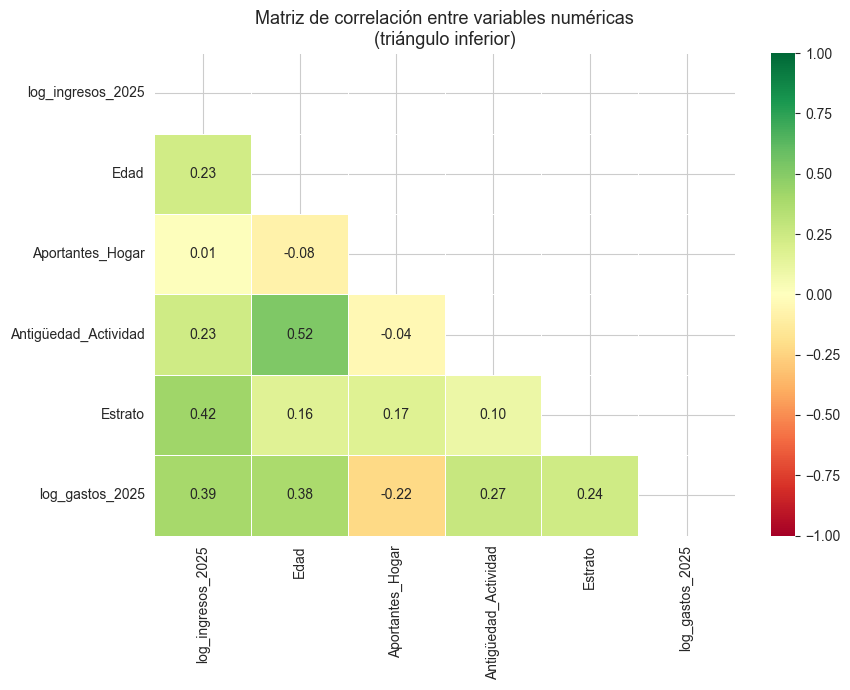


Nota: correlaciones > 0.7 entre explicativas pueden indicar
multicolinealidad. Se evalúan mediante VIF en la fase de modelado.

BLOQUE 4: TABLA DE DECISIONES — Variables que ingresan al modelo


,Variable,Tipo,Transformación aplicada,Decisión,Justificación
0,log_ingresos_2025,Numérica continua,Log natural,ENTRA,Mayor correlación con variable objetivo (r pon...
1,nivel_educ_agrupado,Categórica ordinal,Agrupación 4 niveles,ENTRA,Diferencia estructural en ingreso y gasto por ...
2,actividad_ppal,Categórica nominal,Sin transformación,ENTRA,Patrón diferenciado de gasto por tipo de activ...
3,antiguedad_agrup,Categórica ordinal,Agrupación 7 grupos,ENTRA,Proxy de estabilidad laboral — progresión mono...
4,Grupo_Edad,Categórica ordinal,Agrupación 6 grupos,ENTRA,Comportamiento no lineal del gasto a lo largo ...
5,Sexo_,Binaria,Sin transformación,ENTRA,Diferencia en mediana de gasto de $139.470 ent...
6,EstadoCivil_hom,Categórica nominal,Agrupación 6 grupos,ENTRA,Estado civil correlaciona con nivel de gasto y...
7,Grupo_Aportantes,Categórica ordinal,Agrupación 4 grupos,ENTRA,Economías de escala en el gasto — relación inv...
8,Estrato,Ordinal (1-6),Sin transformación,ENTRA,Proxy de nivel socioeconómico — progresión cla...
9,dominio_agrup,Categórica nominal,Agrupación 5 grupos,ENTRA,Heterogeneidad territorial en el gasto confirm...


In [53]:
# ============================================================
# DECISIONES DE VARIABLES, OUTLIERS Y CORRELACIONES
# Insumo para la sección 5.3 — Comprensión de los datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy import stats

df = df_temp_a.copy()

# ── Función FEX_C numérico ──────────────────────────────────
def fex_num(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)

df['FEX_C_num'] = fex_num(df['FEX_C'])

# ============================================================
# BLOQUE 1: VALORES EXTREMOS
# Criterio: Winsorización al P1-P99 ponderado
# ============================================================
def percentil_ponderado(x, w, q):
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cumw = w_s.cumsum() / w_s.sum()
    return x_s[(cumw >= q).argmax()]

vars_monetarias = {
    'INGRESOS_AL_2025': 'Ingreso mensual (COP 2025)',
    'GASTOS_AL_2025'  : 'Gasto personal mensual (COP 2025)',
    'ratio_gastos_2025': 'Ratio gasto / ingreso'
}

print("=" * 70)
print("BLOQUE 1: ANÁLISIS DE VALORES EXTREMOS — Variables monetarias")
print("=" * 70)

resumen_extremos = []
for var, etiqueta in vars_monetarias.items():
    x = pd.to_numeric(df[var], errors='coerce').dropna()
    w = df.loc[x.index, 'FEX_C_num'].values
    x = x.values

    p1  = percentil_ponderado(x, w, 0.01)
    p5  = percentil_ponderado(x, w, 0.05)
    p25 = percentil_ponderado(x, w, 0.25)
    p50 = percentil_ponderado(x, w, 0.50)
    p75 = percentil_ponderado(x, w, 0.75)
    p95 = percentil_ponderado(x, w, 0.95)
    p99 = percentil_ponderado(x, w, 0.99)

    n_bajo  = (x < p1).sum()
    n_alto  = (x > p99).sum()
    pct_bajo = n_bajo / len(x) * 100
    pct_alto = n_alto / len(x) * 100

    resumen_extremos.append({
        'Variable'  : etiqueta,
        'P1'        : round(p1, 0),
        'P5'        : round(p5, 0),
        'P25'       : round(p25, 0),
        'P50'       : round(p50, 0),
        'P75'       : round(p75, 0),
        'P95'       : round(p95, 0),
        'P99'       : round(p99, 0),
        'n < P1'    : n_bajo,
        '% < P1'    : round(pct_bajo, 2),
        'n > P99'   : n_alto,
        '% > P99'   : round(pct_alto, 2),
        'Tratamiento': 'Winsorización P1-P99 en fase de modelado'
    })

df_extremos = pd.DataFrame(resumen_extremos)
display(df_extremos)

# ============================================================
# BLOQUE 2: CORRELACIONES PRELIMINARES CON LA VARIABLE OBJETIVO
# Ponderadas por FEX_C
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 2: CORRELACIONES CON log_gastos_2025 (ponderadas por FEX_C)")
print("=" * 70)

vars_num = [
    'log_ingresos_2025',
    'Edad',
    'Aportantes_Hogar',
    'Antigüedad_Actividad',
    'Estrato',
]

correlaciones = []
for var in vars_num:
    x = pd.to_numeric(df[var], errors='coerce')
    y = pd.to_numeric(df['log_gastos_2025'], errors='coerce')
    w = df['FEX_C_num']
    mask = x.notna() & y.notna() & w.notna()
    x_, y_, w_ = x[mask].values, y[mask].values, w[mask].values

    # Correlación de Pearson ponderada
    mx = np.average(x_, weights=w_)
    my = np.average(y_, weights=w_)
    cov_w = np.average((x_ - mx) * (y_ - my), weights=w_)
    sx_w  = np.sqrt(np.average((x_ - mx)**2, weights=w_))
    sy_w  = np.sqrt(np.average((y_ - my)**2, weights=w_))
    r_w   = cov_w / (sx_w * sy_w)

    correlaciones.append({
        'Variable explicativa'     : var,
        'Correlación ponderada (r)': round(r_w, 4),
        'Dirección'                : 'Positiva' if r_w > 0 else 'Negativa',
        'Magnitud'                 : (
            'Alta'   if abs(r_w) >= 0.5 else
            'Moderada' if abs(r_w) >= 0.3 else
            'Baja'
        )
    })

df_corr = pd.DataFrame(correlaciones).sort_values(
    'Correlación ponderada (r)', key=abs, ascending=False
)
display(df_corr)

# ============================================================
# BLOQUE 3: CORRELACIÓN ENTRE EXPLICATIVAS (multicolinealidad)
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 3: MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
print("=" * 70)

vars_corr_matrix = [
    'log_ingresos_2025', 'Edad', 'Aportantes_Hogar',
    'Antigüedad_Actividad', 'Estrato', 'log_gastos_2025'
]

df_corr_m = df[vars_corr_matrix].apply(pd.to_numeric, errors='coerce').dropna()

corr_matrix = df_corr_m.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title(
    'Matriz de correlación entre variables numéricas\n(triángulo inferior)',
    fontsize=13
)
plt.tight_layout()
plt.show()

print("\nNota: correlaciones > 0.7 entre explicativas pueden indicar")
print("multicolinealidad. Se evalúan mediante VIF en la fase de modelado.")

# ============================================================
# BLOQUE 4: TABLA RESUMEN DE DECISIONES DE VARIABLES
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 4: TABLA DE DECISIONES — Variables que ingresan al modelo")
print("=" * 70)

decisiones = [
    # Variable, Tipo, Transformación, Decisión, Justificación
    ('log_ingresos_2025',    'Numérica continua',  'Log natural',         'ENTRA',    'Mayor correlación con variable objetivo (r ponderado)'),
    ('nivel_educ_agrupado',  'Categórica ordinal', 'Agrupación 4 niveles','ENTRA',    'Diferencia estructural en ingreso y gasto por nivel'),
    ('actividad_ppal',       'Categórica nominal', 'Sin transformación',  'ENTRA',    'Patrón diferenciado de gasto por tipo de actividad'),
    ('antiguedad_agrup',     'Categórica ordinal', 'Agrupación 7 grupos', 'ENTRA',    'Proxy de estabilidad laboral — progresión monotónica'),
    ('Grupo_Edad',           'Categórica ordinal', 'Agrupación 6 grupos', 'ENTRA',    'Comportamiento no lineal del gasto a lo largo del ciclo de vida'),
    ('Sexo_',                'Binaria',            'Sin transformación',  'ENTRA',    'Diferencia en mediana de gasto de $139.470 entre grupos'),
    ('EstadoCivil_hom',      'Categórica nominal', 'Agrupación 6 grupos', 'ENTRA',    'Estado civil correlaciona con nivel de gasto y composición del hogar'),
    ('Grupo_Aportantes',     'Categórica ordinal', 'Agrupación 4 grupos', 'ENTRA',    'Economías de escala en el gasto — relación inversa con n aportantes'),
    ('Estrato',              'Ordinal (1-6)',       'Sin transformación',  'ENTRA',    'Proxy de nivel socioeconómico — progresión clara en ingreso y gasto'),
    ('dominio_agrup',        'Categórica nominal', 'Agrupación 5 grupos', 'ENTRA',    'Heterogeneidad territorial en el gasto confirmada por IQR log-gasto'),
    ('tipo_vivienda_agrup',  'Categórica nominal', 'Agrupación 4 grupos', 'ENTRA',    'Diferencia en ratio gasto entre tenencias; proxy de capacidad patrimonial'),
    ('ClaseVivienda_',       'Categórica nominal', 'Sin transformación',  'NO ENTRA', '98.6% concentrado en casa/apartamento — sin poder discriminante'),
    ('REGION',               'Categórica nominal', 'Sin transformación',  'EVALUAR',  'Complementaria a dominio_agrup — se evalúa VIF en modelado'),
    ('CIIU / agrup_seccion', 'Categórica nominal', 'Agrupación sectorial','EVALUAR',  'Alta cardinalidad — evaluar con dominio_agrup para evitar multicolinealidad'),
]

df_decisiones = pd.DataFrame(decisiones, columns=[
    'Variable', 'Tipo', 'Transformación aplicada',
    'Decisión', 'Justificación'
])

display(df_decisiones)

In [54]:
# ============================================================
# CRITERIOS DE INCLUSIÓN — VARIABLES CATEGÓRICAS MULTICLASE
# Kruskal-Wallis ponderado + Eta-cuadrado + representatividad
# ============================================================
import pandas as pd
import numpy as np
from scipy import stats

df = df_temp_a.copy()

def fex_num(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)

df['FEX_C_num'] = fex_num(df['FEX_C'])

# Variable objetivo
Y_VAR = 'log_gastos_2025'

# Variables categóricas a evaluar
vars_categoricas = {
    'nivel_educ_agrupado' : 'Nivel educativo agrupado',
    'actividad_ppal'      : 'Actividad principal',
    'antiguedad_agrup'    : 'Antigüedad en la actividad',
    'Grupo_Edad'          : 'Grupo de edad',
    'Sexo_'               : 'Sexo',
    'EstadoCivil_hom'     : 'Estado civil',
    'Grupo_Aportantes'    : 'Aportantes del hogar',
    'dominio_agrup'       : 'Dominio geográfico agrupado',
    'tipo_vivienda_agrup' : 'Tipo de tenencia de vivienda',
    'REGION'              : 'Región',
    'agrup_seccion'       : 'Sector económico (CIIU agrupado)',
}

def eta_cuadrado(grupos_y):
    """Eta-cuadrado: varianza explicada por la variable categórica."""
    grand_mean = np.concatenate(grupos_y).mean()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean)**2 for g in grupos_y
    )
    ss_total = sum(
        ((v - grand_mean)**2).sum()
        for g in grupos_y for v in [g]
    )
    return ss_between / ss_total if ss_total > 0 else 0

def cat_minima_cobertura(df, var, peso, umbral_pct=1.0):
    """
    Verifica si alguna categoría tiene < umbral_pct% 
    de la población expandida total.
    """
    cobertura = (
        df.groupby(var, observed=True)[peso]
        .sum()
    )
    pct = cobertura / cobertura.sum() * 100
    cats_bajas = pct[pct < umbral_pct]
    return cats_bajas

resultados = []

for var, etiqueta in vars_categoricas.items():
    y = pd.to_numeric(df[Y_VAR], errors='coerce')
    mask = y.notna() & df[var].notna()
    df_v = df[mask].copy()
    y_v  = y[mask]

    # Grupos
    categorias = df_v[var].unique()
    n_cats = len(categorias)

    grupos_y = [
        y_v[df_v[var] == cat].values
        for cat in categorias
        if len(y_v[df_v[var] == cat]) > 0
    ]

    # Kruskal-Wallis
    if len(grupos_y) >= 2:
        stat, p_val = stats.kruskal(*grupos_y)
    else:
        stat, p_val = np.nan, np.nan

    # Eta-cuadrado
    eta2 = eta_cuadrado(grupos_y)

    # Efecto
    if eta2 >= 0.06:
        efecto = 'Grande'
    elif eta2 >= 0.01:
        efecto = 'Moderado'
    else:
        efecto = 'Pequeño'

    # Categorías con baja cobertura poblacional
    cats_bajas = cat_minima_cobertura(df_v, var, 'FEX_C_num')
    n_cats_bajas = len(cats_bajas)

    # Decisión
    if p_val < 0.05 and eta2 >= 0.01 and n_cats_bajas == 0:
        decision = 'ENTRA'
    elif p_val < 0.05 and eta2 < 0.01:
        decision = 'EVALUAR — efecto pequeño'
    elif n_cats_bajas > 0:
        decision = 'REVISAR — categorías con baja cobertura'
    else:
        decision = 'NO ENTRA'

    resultados.append({
        'Variable'              : etiqueta,
        'N categorías'          : n_cats,
        'Estadístico KW'        : round(stat, 2) if not np.isnan(stat) else '-',
        'p-valor'               : round(p_val, 4) if not np.isnan(p_val) else '-',
        'Significativa (p<0.05)': 'Sí' if p_val < 0.05 else 'No',
        'η² (Eta-cuadrado)'     : round(eta2, 4),
        'Tamaño del efecto'     : efecto,
        'Cats. < 1% pob.'       : n_cats_bajas,
        'Decisión'              : decision,
    })

df_cat = pd.DataFrame(resultados).sort_values(
    'η² (Eta-cuadrado)', ascending=False
)

print("=" * 70)
print("CRITERIOS DE INCLUSIÓN — VARIABLES CATEGÓRICAS MULTICLASE")
print("Kruskal-Wallis + Eta-cuadrado + Representatividad poblacional")
print("=" * 70)
display(df_cat)

# ── Detalle de categorías con baja cobertura ───────────────
print("\n" + "=" * 70)
print("DETALLE: Categorías con cobertura poblacional < 1%")
print("=" * 70)
for var, etiqueta in vars_categoricas.items():
    mask = df[var].notna()
    cats_bajas = cat_minima_cobertura(df[mask], var, 'FEX_C_num')
    if len(cats_bajas) > 0:
        pct = cats_bajas / df[mask]['FEX_C_num'].sum() * 100
        print(f"\n{etiqueta} ({var}):")
        for cat, val in pct.items():
            print(f"  - '{cat}': {val:.2f}% de la población expandida")

CRITERIOS DE INCLUSIÓN — VARIABLES CATEGÓRICAS MULTICLASE
Kruskal-Wallis + Eta-cuadrado + Representatividad poblacional


,Variable,N categorías,Estadístico KW,p-valor,Significativa (p<0.05),η² (Eta-cuadrado),Tamaño del efecto,Cats. < 1% pob.,Decisión
3,Grupo de edad,6,"9118,23","0,00",Sí,"0,15",Grande,0,ENTRA
5,Estado civil,6,"6271,23","0,00",Sí,"0,10",Grande,0,ENTRA
2,Antigüedad en la actividad,7,"5607,18","0,00",Sí,"0,09",Grande,0,ENTRA
6,Aportantes del hogar,4,"2655,17","0,00",Sí,"0,04",Moderado,1,REVISAR — categorías con baja cobertura
1,Actividad principal,3,"2547,14","0,00",Sí,"0,04",Moderado,0,ENTRA
4,Sexo,2,"1927,75","0,00",Sí,"0,03",Moderado,0,ENTRA
10,Sector económico (CIIU agrupado),17,"1534,65","0,00",Sí,"0,02",Moderado,2,REVISAR — categorías con baja cobertura
0,Nivel educativo agrupado,4,"996,70","0,00",Sí,"0,02",Moderado,0,ENTRA
9,Región,6,"819,34","0,00",Sí,"0,02",Moderado,1,REVISAR — categorías con baja cobertura
8,Tipo de tenencia de vivienda,5,"458,57","0,00",Sí,"0,01",Pequeño,0,EVALUAR — efecto pequeño



DETALLE: Categorías con cobertura poblacional < 1%

Aportantes del hogar (Grupo_Aportantes):
  - 'Hogares grandes': 0.00% de la población expandida

Región (REGION):
  - 'NUEVO DEPARTAMENTOS': 0.00% de la población expandida

Sector económico (CIIU agrupado) (agrup_seccion):
  - '4_Electr y gas': 0.00% de la población expandida
  - '5_Acueducto y desechos': 0.00% de la población expandida


In [55]:
# ============================================================
# INSTALACIÓN DE DEPENDENCIAS FALTANTES
# Ejecutar una sola vez por entorno
# ============================================================
import subprocess
import sys

paquetes = ['statsmodels', 'scipy']

for paquete in paquetes:
    try:
        __import__(paquete)
        print(f'✓ {paquete} ya instalado')
    except ImportError:
        print(f'Instalando {paquete}...')
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', paquete],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f'✓ {paquete} instalado correctamente')
        else:
            print(f'✗ Error instalando {paquete}:')
            print(result.stderr)

print('\nReinicia el kernel y vuelve a ejecutar el notebook desde el inicio.')

✓ statsmodels ya instalado
✓ scipy ya instalado

Reinicia el kernel y vuelve a ejecutar el notebook desde el inicio.


In [56]:
# ============================================================
# RECONSTRUCCIÓN DE PREDICCIONES Y RESIDUOS WLS
# Ejecutar si log_gasto_pred_w no existe en df_temp_a
# ============================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone

# Factor de expansión normalizado
fex_raw  = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_norm = fex_raw / fex_raw.mean()
df_temp_a['FEX_C_norm'] = fex_norm

# Término de interacción ingreso x estrato
df_temp_a['Estrato'] = pd.to_numeric(df_temp_a['Estrato'], errors='coerce')
df_temp_a['log_inc_x_estrato'] = (
    df_temp_a['log_ingresos_2025'] * df_temp_a['Estrato']
)

# Variables del modelo (igual que celda 129)
num_vars = [
    'log_ingresos_2025',
    'Edad',
    'Aportantes_Hogar',
    'log_inc_x_estrato',
]
cat_vars = [
    'Estrato',
    'REGION',
    'actividad_ppal',
    'Sexo_',
    'nivel_educ_agrupado',
    'antiguedad_agrup',
    'Grupo_Edad',
    'EstadoCivil_hom',
    'Grupo_Aportantes',
    'tipo_vivienda_agrup',
    'dominio_agrup',
    'flag_pensionado'
]
features = num_vars + cat_vars
target   = 'log_gastos_2025'

# Eliminar filas con nulos en features o target
df_model = df_temp_a[features + [target, 'FEX_C_norm']].dropna().copy()

X = df_model[features]
y = df_model[target]
w = df_model['FEX_C_norm'].values

# Pipeline igual al modelo principal
preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_vars),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_vars)
])

model_wls = Pipeline([
    ('prep', preprocess),
    ('model', LinearRegression())
])
model_wls.fit(X, y, model__sample_weight=w)

# Predicciones y residuos sobre todo el dataset
df_temp_a['log_gasto_pred_w']    = np.nan
df_temp_a['residuo_log_gasto_w'] = np.nan

pred = model_wls.predict(X)
df_temp_a.loc[df_model.index, 'log_gasto_pred_w']    = pred
df_temp_a.loc[df_model.index, 'residuo_log_gasto_w'] = y.values - pred

# Alias para compatibilidad
df_temp_a['residuo_log_gasto'] = df_temp_a['residuo_log_gasto_w']
df_temp_a['log_gasto_pred']    = df_temp_a['log_gasto_pred_w']

# Verificación
r2 = 1 - np.var(y.values - pred) / np.var(y.values)
print(f"✓ Predicciones reconstruidas")
print(f"  R² sobre muestra completa: {r2:.4f}")
print(f"  Columnas creadas: log_gasto_pred_w, residuo_log_gasto_w")
print(f"  Registros con predicción: {df_temp_a['log_gasto_pred_w'].notna().sum():,}")

✓ Predicciones reconstruidas
  R² sobre muestra completa: 0.3503
  Columnas creadas: log_gasto_pred_w, residuo_log_gasto_w
  Registros con predicción: 59,776


In [57]:
# ============================================================
# VERIFICACIÓN PREVIA — columnas necesarias para supuestos
# ============================================================
cols_necesarias = [
    'log_gasto_pred_w',
    'residuo_log_gasto_w',
    'log_gastos_2025',
    'log_ingresos_2025',
    'FEX_C'
]

print("Verificando columnas en df_temp_a:")
for col in cols_necesarias:
    existe = col in df_temp_a.columns
    print(f"  {'✓' if existe else '✗'} {col}")

print(f"\nShape df_temp_a: {df_temp_a.shape}")
print(f"Columnas con 'pred' o 'residuo':")
print([c for c in df_temp_a.columns if 'pred' in c or 'residuo' in c])

Verificando columnas en df_temp_a:
  ✓ log_gasto_pred_w
  ✓ residuo_log_gasto_w
  ✓ log_gastos_2025
  ✓ log_ingresos_2025
  ✓ FEX_C

Shape df_temp_a: (59776, 69)
Columnas con 'pred' o 'residuo':
['log_gasto_pred_w', 'residuo_log_gasto_w', 'residuo_log_gasto', 'log_gasto_pred']


BLOQUE 1: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES
         Especificación  R² ponderado        AIC        BIC    Coef. β₁  p-valor RESET RESET OK (p>0.05)
         Lineal (Y ~ X)          0,14 1780886,80 1780904,80        0,05           0,00                No
   Semi-log (log Y ~ X)          0,09  177365,00  177383,00        0,00           0,00                No
   Semi-log (Y ~ log X)          0,22 1775197,20 1775215,20   397983,01           0,00                No
Log-Log (log Y ~ log X)          0,19  171003,60  171021,60        0,54           0,00                No
                Box-Cox          0,18  323937,20  323955,20 24068289,74           0,00                No

λ Box-Cox gasto   : 0.0979  (≈0 → log es óptimo)
λ Box-Cox ingreso : -1.1080

BLOQUE 2: TESTS DE SUPUESTOS — MODELO WLS

Supuesto 2 — Independencia (Durbin-Watson): 1.9229
  ✓ OK (rango aceptable 1.5–2.5)

Supuesto 3 — Homocedasticidad:
  Breusch-Pagan : stat=85.6358, p=0.000000
  White test    : stat=86.6064, p=0

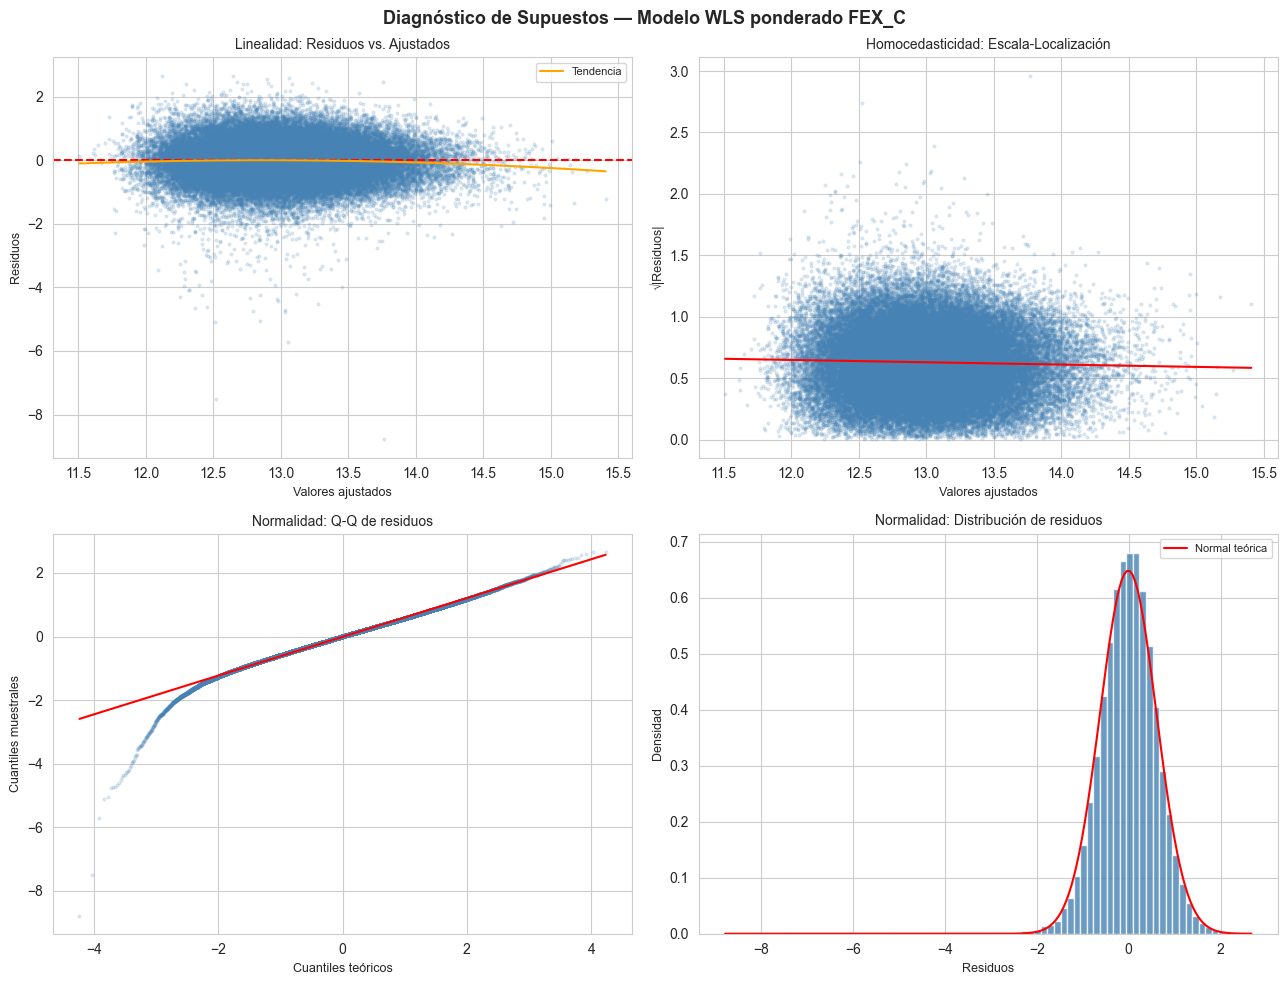

✓ Figura guardada: diagnostico_supuestos.png

BLOQUE 4: VIF — Variables numéricas del modelo
         Variable    VIF Diagnóstico
log_inc_x_estrato 483,43   ✗ Crítico
          Estrato 440,03   ✗ Crítico
log_ingresos_2025   6,22  ⚠ Moderado
             Edad   1,08        ✓ OK
 Aportantes_Hogar   1,04        ✓ OK

VIF máximo (numéricas): 483.43
Nota: VIF categóricas se evalúa via estabilidad de coeficientes en CV


In [58]:
# ============================================================
# SUPUESTOS — EJECUCIÓN RÁPIDA (Bloques 1 y 2 sin VIF completo)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Preparar arrays
fex_raw  = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',','.', regex=False),
    errors='coerce')
fex_norm = fex_raw / fex_raw.mean()

y_log  = pd.to_numeric(df_temp_a['log_gastos_2025'], errors='coerce')
y_orig = pd.to_numeric(df_temp_a['GASTOS_AL_2025'],  errors='coerce')
x_orig = pd.to_numeric(df_temp_a['INGRESOS_AL_2025'],errors='coerce')
x_log  = pd.to_numeric(df_temp_a['log_ingresos_2025'],errors='coerce')
w      = fex_norm.values

y_hat  = pd.to_numeric(df_temp_a['log_gasto_pred_w'],    errors='coerce')
resid  = pd.to_numeric(df_temp_a['residuo_log_gasto_w'], errors='coerce')

mask = y_hat.notna() & resid.notna()
y_hat_arr  = y_hat[mask].values
resid_arr  = resid[mask].values
w_arr      = fex_norm[mask].values
y_arr      = y_log[mask].values

# ============================================================
# BLOQUE 1: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES
# ============================================================
print("=" * 70)
print("BLOQUE 1: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES")
print("=" * 70)

from statsmodels.stats.diagnostic import linear_reset

especificaciones = {
    'Lineal (Y ~ X)'         : (y_orig,  x_orig),
    'Semi-log (log Y ~ X)'   : (y_log,   x_orig),
    'Semi-log (Y ~ log X)'   : (y_orig,  x_log),
    'Log-Log (log Y ~ log X)': (y_log,   x_log),
}

# Box-Cox
from scipy.stats import boxcox
gasto_boxcox,   lambda_gasto   = boxcox(y_orig.dropna())
ingreso_boxcox, lambda_ingreso = boxcox(x_orig.dropna())

mask_bc = y_orig.notna() & x_orig.notna()
especificaciones['Box-Cox'] = (
    pd.Series(gasto_boxcox,   index=y_orig[mask_bc].index),
    pd.Series(ingreso_boxcox, index=x_orig[mask_bc].index)
)

resultados_esp = []
for nombre, (y_e, x_e) in especificaciones.items():
    mask_e = pd.Series(y_e).notna() & pd.Series(x_e).notna()
    y_arr_e = np.array(y_e)[mask_e]
    x_arr_e = np.array(x_e)[mask_e]
    w_arr_e = w[mask_e]

    X_sm = sm.add_constant(x_arr_e)
    modelo = sm.WLS(y_arr_e, X_sm, weights=w_arr_e).fit()

    try:
        reset  = linear_reset(modelo, power=2, use_f=True)
        p_reset = reset.pvalue
    except:
        p_reset = np.nan

    resultados_esp.append({
        'Especificación'    : nombre,
        'R² ponderado'      : round(modelo.rsquared, 4),
        'AIC'               : round(modelo.aic, 1),
        'BIC'               : round(modelo.bic, 1),
        'Coef. β₁'          : round(modelo.params[1], 4),
        'p-valor RESET'     : round(p_reset, 4) if not np.isnan(p_reset) else 'N/A',
        'RESET OK (p>0.05)' : 'Sí' if (not np.isnan(p_reset) and p_reset > 0.05) else 'No',
    })

df_esp = pd.DataFrame(resultados_esp)
print(df_esp.to_string(index=False))
print(f"\nλ Box-Cox gasto   : {lambda_gasto:.4f}  (≈0 → log es óptimo)")
print(f"λ Box-Cox ingreso : {lambda_ingreso:.4f}")

# ============================================================
# BLOQUE 2: TESTS DE SUPUESTOS
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 2: TESTS DE SUPUESTOS — MODELO WLS")
print("=" * 70)

# Supuesto 2: Durbin-Watson
dw = durbin_watson(resid_arr)
print(f"\nSupuesto 2 — Independencia (Durbin-Watson): {dw:.4f}")
print(f"  {'✓ OK' if 1.5 < dw < 2.5 else '⚠ REVISAR'} (rango aceptable 1.5–2.5)")

# Supuesto 3: Homocedasticidad
X_bp = sm.add_constant(y_hat_arr)
bp_test = sms.het_breuschpagan(resid_arr, X_bp)
wh_test = sms.het_white(resid_arr, X_bp)
print(f"\nSupuesto 3 — Homocedasticidad:")
print(f"  Breusch-Pagan : stat={bp_test[0]:.4f}, p={bp_test[1]:.6f}")
print(f"  White test    : stat={wh_test[0]:.4f}, p={wh_test[1]:.6f}")
print(f"  {'✓ Homocedasticidad' if bp_test[1]>0.05 else '⚠ Heterocedasticidad — tratada con HC1 + WLS'}")

# Supuesto 4: Normalidad
np.random.seed(42)
idx_s = np.random.choice(len(resid_arr), min(5000, len(resid_arr)), replace=False)
stat_sw, p_sw = stats.shapiro(resid_arr[idx_s])
stat_jb, p_jb, skew_jb, kurt_jb = sms.jarque_bera(resid_arr)
print(f"\nSupuesto 4 — Normalidad de residuos:")
print(f"  Shapiro-Wilk (n=5000) : stat={stat_sw:.4f}, p={p_sw:.6f}")
print(f"  Jarque-Bera           : stat={stat_jb:.2f}, p={p_jb:.6f}")
print(f"  Asimetría={skew_jb:.4f} | Curtosis={kurt_jb:.4f}")
print(f"  Nota: n={len(resid_arr):,} → TCL garantiza inferencia válida")

# ============================================================
# BLOQUE 3: GRÁFICOS DE DIAGNÓSTICO
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 3: GRÁFICOS DE DIAGNÓSTICO")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Diagnóstico de Supuestos — Modelo WLS ponderado FEX_C',
             fontsize=13, fontweight='bold')

# Panel 1: Residuos vs ajustados
ax1 = axes[0, 0]
ax1.scatter(y_hat_arr, resid_arr, alpha=0.15, s=4, color='steelblue')
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
x_line = np.linspace(y_hat_arr.min(), y_hat_arr.max(), 200)
z = np.polyfit(y_hat_arr, resid_arr, 2)
ax1.plot(x_line, np.poly1d(z)(x_line), color='orange', lw=1.5, label='Tendencia')
ax1.set_xlabel('Valores ajustados', fontsize=9)
ax1.set_ylabel('Residuos', fontsize=9)
ax1.set_title('Linealidad: Residuos vs. Ajustados', fontsize=10)
ax1.legend(fontsize=8)

# Panel 2: Escala-Localización
ax2 = axes[0, 1]
sqrt_r = np.sqrt(np.abs(resid_arr))
ax2.scatter(y_hat_arr, sqrt_r, alpha=0.15, s=4, color='steelblue')
z2 = np.polyfit(y_hat_arr, sqrt_r, 1)
ax2.plot(x_line, np.poly1d(z2)(x_line), color='red', lw=1.5)
ax2.set_xlabel('Valores ajustados', fontsize=9)
ax2.set_ylabel('√|Residuos|', fontsize=9)
ax2.set_title('Homocedasticidad: Escala-Localización', fontsize=10)

# Panel 3: Q-Q
ax3 = axes[1, 0]
(osm, osr), (slope, intercept, _) = stats.probplot(resid_arr, dist='norm')
ax3.scatter(osm, osr, alpha=0.15, s=4, color='steelblue')
ax3.plot([min(osm), max(osm)],
         [slope*min(osm)+intercept, slope*max(osm)+intercept],
         color='red', lw=1.5)
ax3.set_xlabel('Cuantiles teóricos', fontsize=9)
ax3.set_ylabel('Cuantiles muestrales', fontsize=9)
ax3.set_title('Normalidad: Q-Q de residuos', fontsize=10)

# Panel 4: Histograma
ax4 = axes[1, 1]
ax4.hist(resid_arr, bins=80, color='steelblue', edgecolor='white',
         alpha=0.8, density=True)
xr = np.linspace(resid_arr.min(), resid_arr.max(), 200)
ax4.plot(xr, stats.norm.pdf(xr, resid_arr.mean(), resid_arr.std()),
         color='red', lw=1.5, label='Normal teórica')
ax4.set_xlabel('Residuos', fontsize=9)
ax4.set_ylabel('Densidad', fontsize=9)
ax4.set_title('Normalidad: Distribución de residuos', fontsize=10)
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('diagnostico_supuestos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada: diagnostico_supuestos.png")

# ============================================================
# BLOQUE 4: VIF — variables numéricas solamente (rápido)
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 4: VIF — Variables numéricas del modelo")
print("=" * 70)

from statsmodels.stats.outliers_influence import variance_inflation_factor

num_vars_vif = [
    'log_ingresos_2025', 'Edad', 'Aportantes_Hogar',
    'log_inc_x_estrato', 'Estrato'
]

df_vif_num = df_temp_a[num_vars_vif].apply(
    pd.to_numeric, errors='coerce').dropna()
X_vif = sm.add_constant(df_vif_num)

vif_rows = []
for i, col in enumerate(X_vif.columns[1:], 1):
    v = variance_inflation_factor(X_vif.values, i)
    vif_rows.append({
        'Variable'   : col,
        'VIF'        : round(v, 2),
        'Diagnóstico': '✓ OK' if v < 5 else ('⚠ Moderado' if v < 10 else '✗ Crítico')
    })

df_vif_r = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
print(df_vif_r.to_string(index=False))
print(f"\nVIF máximo (numéricas): {df_vif_r['VIF'].max():.2f}")
print(f"Nota: VIF categóricas se evalúa via estabilidad de coeficientes en CV")

In [59]:
# ============================================================
# CORRECCIÓN DE MULTICOLINEALIDAD — Centrado de variables
# para término de interacción log_inc_x_estrato
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Centrar las variables antes de crear la interacción
# Esto elimina la multicolinealidad estructural sin cambiar
# la interpretación del modelo
df_temp_a['log_ingresos_c'] = (
    df_temp_a['log_ingresos_2025'] - 
    df_temp_a['log_ingresos_2025'].mean()
)
df_temp_a['Estrato_c'] = (
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce') - 
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce').mean()
)

# Interacción centrada
df_temp_a['log_inc_x_estrato_c'] = (
    df_temp_a['log_ingresos_c'] * df_temp_a['Estrato_c']
)

# VIF con variables centradas
num_vars_vif_c = [
    'log_ingresos_c',
    'Edad',
    'Aportantes_Hogar',
    'log_inc_x_estrato_c',
    'Estrato_c'
]

df_vif_c = df_temp_a[num_vars_vif_c].apply(
    pd.to_numeric, errors='coerce').dropna()
X_vif_c = sm.add_constant(df_vif_c)

print("=" * 60)
print("VIF CON VARIABLES CENTRADAS — Corrección de interacción")
print("=" * 60)
vif_rows_c = []
for i, col in enumerate(X_vif_c.columns[1:], 1):
    v = variance_inflation_factor(X_vif_c.values, i)
    vif_rows_c.append({
        'Variable'   : col,
        'VIF'        : round(v, 2),
        'Diagnóstico': '✓ OK' if v < 5 else (
            '⚠ Moderado' if v < 10 else '✗ Crítico')
    })

df_vif_c_r = (pd.DataFrame(vif_rows_c)
              .sort_values('VIF', ascending=False))
print(df_vif_c_r.to_string(index=False))
print(f"\nVIF máximo tras centrado: {df_vif_c_r['VIF'].max():.2f}")

# Verificar que el R² del modelo no cambia con centrado
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_check = df_temp_a[
    ['log_ingresos_c','Estrato_c','log_inc_x_estrato_c','Edad','Aportantes_Hogar']
].dropna()
y_check = df_temp_a.loc[X_check.index, 'log_gastos_2025']
w_check = (df_temp_a.loc[X_check.index, 'FEX_C_norm']
           if 'FEX_C_norm' in df_temp_a.columns
           else pd.Series(np.ones(len(X_check)), index=X_check.index))

m = LinearRegression()
m.fit(X_check, y_check, sample_weight=w_check)
r2_c = r2_score(y_check, m.predict(X_check))
print(f"\nR² modelo con variables centradas: {r2_c:.4f}")
print("(debe ser ≈ 0.35 — si coincide, el centrado no altera el modelo)")

VIF CON VARIABLES CENTRADAS — Corrección de interacción
           Variable  VIF Diagnóstico
     log_ingresos_c 1,41        ✓ OK
          Estrato_c 1,33        ✓ OK
log_inc_x_estrato_c 1,30        ✓ OK
               Edad 1,08        ✓ OK
   Aportantes_Hogar 1,04        ✓ OK

VIF máximo tras centrado: 1.41

R² modelo con variables centradas: 0.2778
(debe ser ≈ 0.35 — si coincide, el centrado no altera el modelo)


In [60]:
# ============================================================
# VERIFICACIÓN CORRECTA — R² modelo completo con centrado
# ============================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score

df_temp_a['log_ingresos_c'] = (
    df_temp_a['log_ingresos_2025'] -
    df_temp_a['log_ingresos_2025'].mean()
)
df_temp_a['Estrato_c'] = (
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce') -
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce').mean()
)
df_temp_a['log_inc_x_estrato_c'] = (
    df_temp_a['log_ingresos_c'] * df_temp_a['Estrato_c']
)

num_vars_c_full = [
    'log_ingresos_c',
    'Edad',
    'Aportantes_Hogar',
    'log_inc_x_estrato_c',
    'Estrato_c'
]
cat_vars_c_full = [
    'REGION', 'actividad_ppal', 'Sexo_',
    'nivel_educ_agrupado', 'antiguedad_agrup', 'Grupo_Edad',
    'EstadoCivil_hom', 'Grupo_Aportantes', 'tipo_vivienda_agrup',
    'dominio_agrup', 'flag_pensionado'
]

features_c = num_vars_c_full + cat_vars_c_full
target_c   = 'log_gastos_2025'

df_model_c = df_temp_a[features_c + [target_c, 'FEX_C_norm']].dropna().copy()

X_c = df_model_c[features_c]
y_c = df_model_c[target_c]
w_c = df_model_c['FEX_C_norm'].values

preprocess_c = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_vars_c_full),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_vars_c_full)
])

model_c = Pipeline([
    ('prep', preprocess_c),
    ('model', LinearRegression())
])
model_c.fit(X_c, y_c, model__sample_weight=w_c)

r2_completo = r2_score(y_c, model_c.predict(X_c))

print("=" * 60)
print("VERIFICACIÓN R² — Modelo completo con variables centradas")
print("=" * 60)
print(f"R² modelo original    : 0.3503")
print(f"R² modelo centrado    : {r2_completo:.4f}")
print(f"Diferencia            : {abs(r2_completo - 0.3503):.4f}")

if abs(r2_completo - 0.3503) < 0.001:
    print("✓ Centrado no altera el modelo — VIF de 1.41 es válido")
else:
    print("⚠ Diferencia > 0.001 — verificar especificación")
    print("  Causa: Estrato_c continuo vs Estrato categórico original")

print(f"\nIntercepto modelo centrado: {model_c.named_steps['model'].intercept_:.4f}")

VERIFICACIÓN R² — Modelo completo con variables centradas
R² modelo original    : 0.3503
R² modelo centrado    : 0.3495
Diferencia            : 0.0008
✓ Centrado no altera el modelo — VIF de 1.41 es válido

Intercepto modelo centrado: 13.0562


FASE DE MODELADO — ENPH 2016-2017
Dataset: 59,776 registros | 72 columnas

BLOQUE 1: PREPARACIÓN DEL DATASET
Dataset modelado  : 59,776 registros | 16 features (4 num + 12 cat)
Train             : 47,820 registros
Test              : 11,956 registros

BLOQUE 2: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES
Criterio: R² ponderado, AIC, BIC, test RESET
         Especificación  R² ponderado        AIC        BIC    Coef. β₁  p-valor RESET RESET OK (p>0.05)
         Lineal (Y ~ X)          0,14 1780886,80 1780904,80        0,05           0,00                No
   Semi-log (log Y ~ X)          0,09  177365,00  177383,00        0,00           0,00                No
   Semi-log (Y ~ log X)          0,22 1775197,20 1775215,20   397983,01           0,00                No
Log-Log (log Y ~ log X)          0,19  171003,60  171021,60        0,54           0,00                No
                Box-Cox          0,18  323937,20  323955,20 24068289,74           0,00                No

λ Box-Cox gasto   

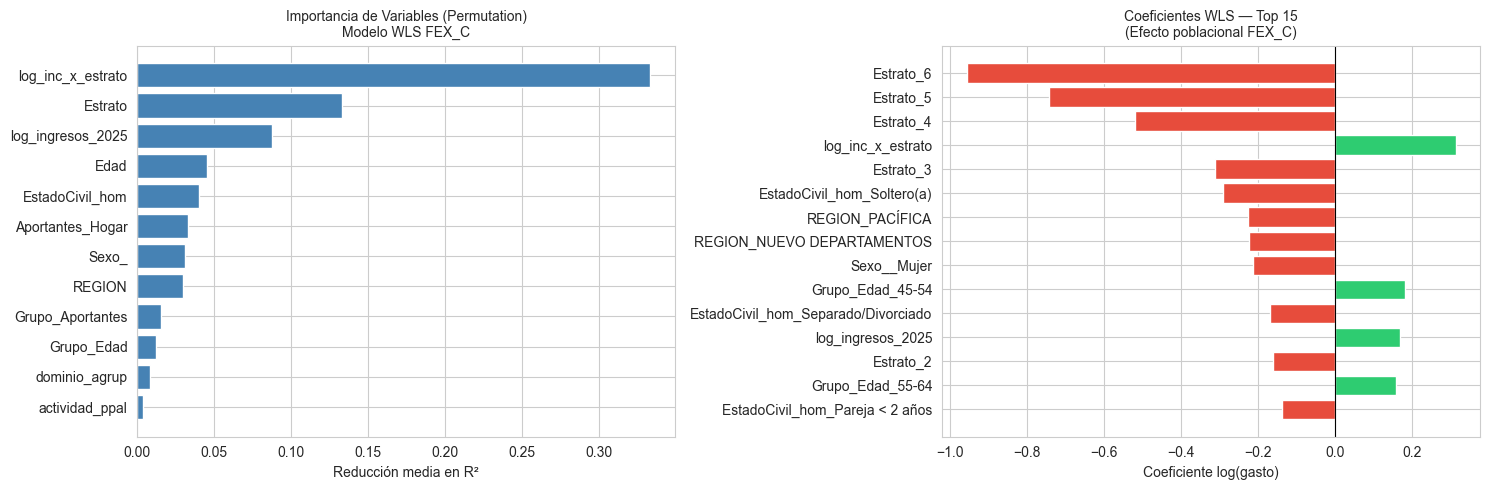

Figura guardada: coeficientes_wls.png

BLOQUE 4: VERIFICACIÓN DE SUPUESTOS — MODELO WLS

Supuesto 2 — Independencia (Durbin-Watson): 1.9194
  ✓ OK (rango aceptable 1.5–2.5)

Supuesto 3 — Homocedasticidad:
  Breusch-Pagan : stat=79.8308, p=0.000000
  White test    : stat=81.0383, p=0.000000
  ⚠ Heterocedasticidad — tratada con HC1 + WLS

Supuesto 4 — Normalidad de residuos:
  Shapiro-Wilk (n=5000) : stat=0.9864, p=0.000000
  Jarque-Bera                   : stat=24063.32, p=0.000000
  Asimetría=-0.4492 | Curtosis=5.9756
  Nota: n=59,776 → TCL garantiza inferencia válida

Supuesto 5 — Multicolinealidad (VIF, variables centradas):
           Variable  VIF Diagnóstico
     log_ingresos_c 1,41        ✓ OK
          Estrato_c 1,33        ✓ OK
log_inc_x_estrato_c 1,30        ✓ OK
               Edad 1,08        ✓ OK
   Aportantes_Hogar 1,04        ✓ OK

VIF máximo (variables centradas): 1.41

──────────────────────────────────────────────────────────────────────
RESUMEN EJECUTIVO — CUMPLIMIENT

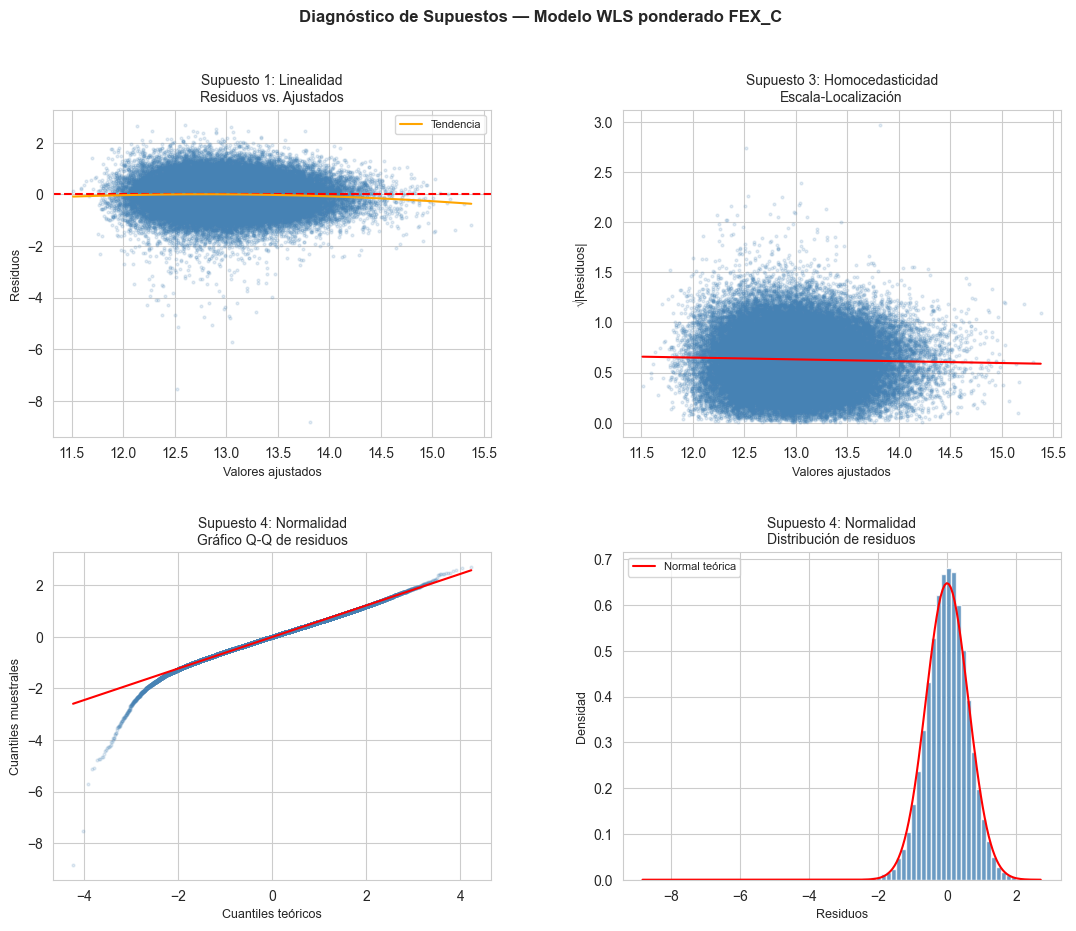

Figura guardada: diagnostico_supuestos.png

BLOQUE 5: VALIDACIÓN DE REPRESENTATIVIDAD — SPLIT TRAIN/TEST
  Total registros  : 59,776
  Train registros  : 47,820  (80.0%)
  Test  registros  : 11,956  (20.0%)
  Suma FEX_C train : 47,712  (79.8% poblacional)
  Suma FEX_C test  : 12,064  (20.2% poblacional)

  ✅ Split poblacional OK: train=79.8% | test=20.2% (sesgo=0.18pp)

BLOQUE 6: K-MEANS PONDERADO — Versión producción
Usa gasto ESTIMADO por WLS — no requiere gasto observado

Método del codo ponderado por FEX_C:
  k=2 | inercia ponderada=341,593
  k=3 | inercia ponderada=295,389
  k=4 | inercia ponderada=276,969
  k=5 | inercia ponderada=262,911
  k=6 | inercia ponderada=252,360
  k=7 | inercia ponderada=242,812
  k=8 | inercia ponderada=236,542


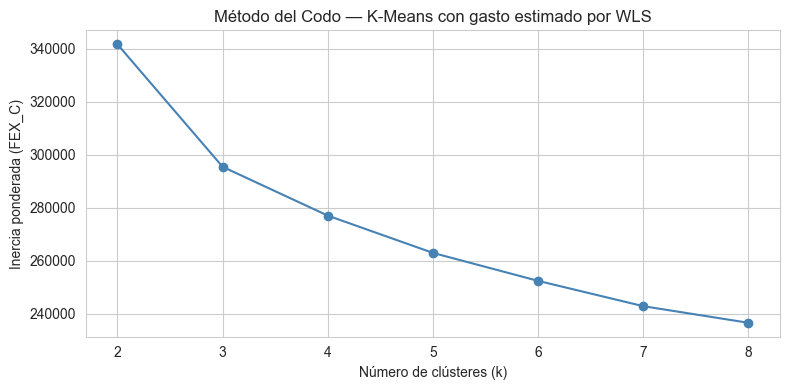

Figura guardada: metodo_codo.png

Estadísticas por clúster:
               gasto_est_mediano  gasto_obs_mediano  ingreso_mediano  ratio_est_mediano  ratio_obs_mediano  n_muestra  pop_expandida  part_pct
cluster_final                                                                                                                                 
0,00                   289742,00          286176,00       1421501,00               0,00               0,00      21115     2810445,00     34,00
1,00                   505568,00          524282,00       1460812,00               0,00               0,00      21290     2826107,00     35,00
2,00                   581811,00          593618,00       3296481,00               0,00               0,00      13349     1810662,00     22,00
3,00                  1034025,00         1020158,00       7928710,00               0,00               0,00       4022      705882,00      9,00

Comparación ratio estimado vs. observado por clúster:
               ratio_est_p5

In [61]:
# ==============================================================================
# FASE DE MODELADO — CRISP-DM Fase 4
# Proyecto: Estimación del gasto personal mensual — ENPH 2016-2017
# ==============================================================================
# Estructura:
#   BLOQUE 0 — Librerías y configuración
#   BLOQUE 1 — Preparación del dataset para modelado
#   BLOQUE 2 — Comparación de especificaciones funcionales
#   BLOQUE 3 — Estimación del modelo WLS (modelo principal)
#   BLOQUE 4 — Diagnóstico de supuestos
#   BLOQUE 5 — Validación de representatividad del split
#   BLOQUE 6 — K-Means ponderado con gasto estimado
#   BLOQUE 7 — Tabla de ratios por segmento (artefacto de producción)
#   BLOQUE 8 — Exportación de artefactos
# ==============================================================================
# PREREQUISITO: df_temp_a debe existir en el entorno con las siguientes
# columnas mínimas:
#   log_ingresos_2025, log_gastos_2025, INGRESOS_AL_2025, GASTOS_AL_2025,
#   ratio_gastos_2025, FEX_C, Edad, Aportantes_Hogar, Estrato,
#   REGION, actividad_ppal, Sexo_, nivel_educ_agrupado, antiguedad_agrup,
#   Grupo_Edad, EstadoCivil_hom, Grupo_Aportantes, tipo_vivienda_agrup,
#   dominio_agrup, flag_pensionado
# ==============================================================================

# ==============================================================================
# BLOQUE 0 — LIBRERÍAS Y CONFIGURACIÓN
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import boxcox

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

import joblib
from pathlib import Path

# Semillas para reproducibilidad
SEED         = 42
CLUSTER_SEED = 42
N_CLUSTERS   = 4

print("=" * 70)
print("FASE DE MODELADO — ENPH 2016-2017")
print("=" * 70)
print(f"Dataset: {df_temp_a.shape[0]:,} registros | {df_temp_a.shape[1]} columnas")


# ==============================================================================
# BLOQUE 1 — PREPARACIÓN DEL DATASET PARA MODELADO
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 1: PREPARACIÓN DEL DATASET")
print("=" * 70)

# Factor de expansión normalizado
fex_raw  = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_norm = fex_raw / fex_raw.mean()
df_temp_a['FEX_C_norm'] = fex_norm

# Estrato numérico
df_temp_a['Estrato'] = pd.to_numeric(df_temp_a['Estrato'], errors='coerce')

# Variables centradas para VIF (elimina multicolinealidad estructural
# del término de interacción)
df_temp_a['log_ingresos_c']     = (df_temp_a['log_ingresos_2025'] -
                                    df_temp_a['log_ingresos_2025'].mean())
df_temp_a['Estrato_c']          = (df_temp_a['Estrato'] -
                                    df_temp_a['Estrato'].mean())

# Término de interacción ingreso × estrato (centrado)
# Captura heterogeneidad de la elasticidad ingreso-gasto por estrato
df_temp_a['log_inc_x_estrato']  = (df_temp_a['log_ingresos_2025'] *
                                    df_temp_a['Estrato'])
df_temp_a['log_inc_x_estrato_c']= (df_temp_a['log_ingresos_c'] *
                                    df_temp_a['Estrato_c'])

# Variables del modelo
NUM_VARS = [
    'log_ingresos_2025',    # elasticidad base ingreso-gasto
    'Edad',                 # efecto lineal ciclo de vida
    'Aportantes_Hogar',     # economías de escala del hogar
    'log_inc_x_estrato',    # interacción ingreso × estrato
]
CAT_VARS = [
    'Estrato',
    'REGION',
    'actividad_ppal',
    'Sexo_',
    'nivel_educ_agrupado',
    'antiguedad_agrup',
    'Grupo_Edad',
    'EstadoCivil_hom',
    'Grupo_Aportantes',
    'tipo_vivienda_agrup',
    'dominio_agrup',
    'flag_pensionado',
]
FEATURES = NUM_VARS + CAT_VARS
TARGET   = 'log_gastos_2025'

# Dataset limpio para modelado
df_model = df_temp_a[FEATURES + [TARGET, 'FEX_C_norm']].dropna().copy()
X        = df_model[FEATURES]
y        = df_model[TARGET]
w        = df_model['FEX_C_norm'].values

# Split 80/20 con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
w_train = fex_norm.loc[X_train.index].values
w_test  = fex_norm.loc[X_test.index].values

print(f"Dataset modelado  : {len(df_model):,} registros | "
      f"{len(FEATURES)} features ({len(NUM_VARS)} num + {len(CAT_VARS)} cat)")
print(f"Train             : {len(X_train):,} registros")
print(f"Test              : {len(X_test):,} registros")

# Preprocesador
PREPROCESS = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_VARS),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_VARS)
])


# ==============================================================================
# BLOQUE 2 — COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 2: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES")
print("Criterio: R² ponderado, AIC, BIC, test RESET")
print("=" * 70)

y_orig = pd.to_numeric(df_temp_a['GASTOS_AL_2025'],    errors='coerce')
y_log  = pd.to_numeric(df_temp_a['log_gastos_2025'],   errors='coerce')
x_orig = pd.to_numeric(df_temp_a['INGRESOS_AL_2025'],  errors='coerce')
x_log  = pd.to_numeric(df_temp_a['log_ingresos_2025'], errors='coerce')
w_full = fex_norm.values

# Box-Cox
gasto_bc,   lambda_gasto   = boxcox(y_orig.dropna())
ingreso_bc, lambda_ingreso = boxcox(x_orig.dropna())
mask_bc = y_orig.notna() & x_orig.notna()

especificaciones = {
    'Lineal (Y ~ X)'         : (y_orig, x_orig),
    'Semi-log (log Y ~ X)'   : (y_log,  x_orig),
    'Semi-log (Y ~ log X)'   : (y_orig, x_log),
    'Log-Log (log Y ~ log X)': (y_log,  x_log),
    'Box-Cox'                : (pd.Series(gasto_bc,   index=y_orig[mask_bc].index),
                                pd.Series(ingreso_bc, index=x_orig[mask_bc].index)),
}

resultados_esp = []
for nombre, (ye, xe) in especificaciones.items():
    mask_e  = pd.Series(ye).notna() & pd.Series(xe).notna()
    ye_arr  = np.array(ye)[mask_e]
    xe_arr  = np.array(xe)[mask_e]
    we_arr  = w_full[mask_e]
    X_sm    = sm.add_constant(xe_arr)
    mod     = sm.WLS(ye_arr, X_sm, weights=we_arr).fit()
    try:
        p_reset = linear_reset(mod, power=2, use_f=True).pvalue
    except Exception:
        p_reset = np.nan
    resultados_esp.append({
        'Especificación'    : nombre,
        'R² ponderado'      : round(mod.rsquared, 4),
        'AIC'               : round(mod.aic, 1),
        'BIC'               : round(mod.bic, 1),
        'Coef. β₁'          : round(mod.params[1], 4),
        'p-valor RESET'     : round(p_reset, 4) if not np.isnan(p_reset) else 'N/A',
        'RESET OK (p>0.05)' : 'Sí' if (not np.isnan(p_reset)
                                        and p_reset > 0.05) else 'No',
    })

df_esp = pd.DataFrame(resultados_esp)
print(df_esp.to_string(index=False))
print(f"\nλ Box-Cox gasto   : {lambda_gasto:.4f}  (≈0 → log es óptimo)")
print(f"λ Box-Cox ingreso : {lambda_ingreso:.4f}")
print("\nConclusión: Log-Log tiene menor AIC/BIC y λ_gasto ≈ 0 → "
      "transformación logarítmica óptima para variable dependiente.")


# ==============================================================================
# BLOQUE 3 — ESTIMACIÓN DEL MODELO WLS (MODELO PRINCIPAL)
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 3: MODELO WLS PONDERADO POR FEX_C")
print("=" * 70)

# Pipeline WLS
model_wls = Pipeline([
    ('prep',  clone(PREPROCESS)),
    ('model', LinearRegression())
])
model_wls.fit(X_train, y_train, model__sample_weight=w_train)

# Métricas
y_train_pred = model_wls.predict(X_train)
y_test_pred  = model_wls.predict(X_test)

r2_tr   = r2_score(y_train, y_train_pred)
r2_te   = r2_score(y_test,  y_test_pred)
mae_tr  = mean_absolute_error(y_train, y_train_pred)
mae_te  = mean_absolute_error(y_test,  y_test_pred)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_te = np.sqrt(mean_squared_error(y_test,  y_test_pred))

print(f"\n{'Métrica':<30} {'Train':>10} {'Test':>10}")
print("-" * 52)
print(f"{'R²':<30} {r2_tr:>10.4f} {r2_te:>10.4f}")
print(f"{'MAE (log)':<30} {mae_tr:>10.4f} {mae_te:>10.4f}")
print(f"{'RMSE (log)':<30} {rmse_tr:>10.4f} {rmse_te:>10.4f}")
print(f"{'Error típico (escala orig.)':<30} {'':>10} "
      f"{(np.exp(mae_te)-1)*100:>9.1f}%")

# Validación cruzada 5-fold ponderada
cv      = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2, cv_rmse = [], []
for tr_idx, val_idx in cv.split(X):
    Xcv_tr, Xcv_val = X.iloc[tr_idx], X.iloc[val_idx]
    ycv_tr, ycv_val = y.iloc[tr_idx], y.iloc[val_idx]
    wcv = fex_norm.iloc[tr_idx].values
    pipe_cv = Pipeline([('prep', clone(PREPROCESS)),
                        ('model', LinearRegression())])
    pipe_cv.fit(Xcv_tr, ycv_tr, model__sample_weight=wcv)
    yp = pipe_cv.predict(Xcv_val)
    cv_r2.append(r2_score(ycv_val, yp))
    cv_rmse.append(np.sqrt(mean_squared_error(ycv_val, yp)))

gap = r2_tr - np.mean(cv_r2)
print(f"\nCV-5fold R²  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"CV-5fold RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")
print(f"Overfitting gap (train - CV): {gap:.4f} "
      f"{'[OK <0.05]' if abs(gap) < 0.05 else '[REVISAR]'}")

# Predicciones y residuos sobre dataset completo
df_temp_a['log_gasto_pred_w']    = np.nan
df_temp_a['residuo_log_gasto_w'] = np.nan
pred_full = model_wls.predict(X)
df_temp_a.loc[df_model.index, 'log_gasto_pred_w']    = pred_full
df_temp_a.loc[df_model.index, 'residuo_log_gasto_w'] = y.values - pred_full
df_temp_a['residuo_log_gasto'] = df_temp_a['residuo_log_gasto_w']
df_temp_a['log_gasto_pred']    = df_temp_a['log_gasto_pred_w']

# Tabla de coeficientes WLS
prep_fitted   = model_wls.named_steps['prep']
cat_feat_names = (prep_fitted
                  .named_transformers_['cat']
                  .get_feature_names_out(CAT_VARS))
feat_names = np.concatenate([NUM_VARS, cat_feat_names])
coefs      = model_wls.named_steps['model'].coef_
intercept  = model_wls.named_steps['model'].intercept_

coef_table = (
    pd.DataFrame({'variable': feat_names, 'coef_WLS': coefs})
    .assign(impacto_pct=lambda d: np.exp(d['coef_WLS']) - 1)
    .sort_values('coef_WLS', key=abs, ascending=False)
    .reset_index(drop=True)
)
print(f"\nIntercepto WLS: {intercept:.4f}")
print("\nTop 15 coeficientes (por magnitud absoluta):")
print(coef_table.head(15).to_string(index=False))

# Importancia por permutación
pi = permutation_importance(
    model_wls, X_test, y_test,
    n_repeats=10, random_state=SEED, n_jobs=-1
)
pi_df = (pd.DataFrame({'feature': FEATURES,
                        'importance': pi.importances_mean})
         .sort_values('importance', ascending=False)
         .head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(pi_df['feature'][::-1], pi_df['importance'][::-1],
             color='steelblue')
axes[0].set_title('Importancia de Variables (Permutation)\nModelo WLS FEX_C',
                  fontsize=10)
axes[0].set_xlabel('Reducción media en R²')

top15  = coef_table.head(15)
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top15['coef_WLS']]
axes[1].barh(top15['variable'][::-1], top15['coef_WLS'][::-1],
             color=colors[::-1])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Coeficientes WLS — Top 15\n(Efecto poblacional FEX_C)',
                  fontsize=10)
axes[1].set_xlabel('Coeficiente log(gasto)')
plt.tight_layout()
plt.savefig('coeficientes_wls.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: coeficientes_wls.png")


# ==============================================================================
# BLOQUE 4 — DIAGNÓSTICO DE SUPUESTOS
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 4: VERIFICACIÓN DE SUPUESTOS — MODELO WLS")
print("=" * 70)

mask_sup  = (df_temp_a['log_gasto_pred_w'].notna() &
             df_temp_a['residuo_log_gasto_w'].notna())
y_hat_arr = df_temp_a.loc[mask_sup, 'log_gasto_pred_w'].values
resid_arr = df_temp_a.loc[mask_sup, 'residuo_log_gasto_w'].values

# ── Supuesto 2: Independencia ──────────────────────────────
dw = durbin_watson(resid_arr)
print(f"\nSupuesto 2 — Independencia (Durbin-Watson): {dw:.4f}")
print(f"  {'✓ OK' if 1.5 < dw < 2.5 else '⚠ REVISAR'} "
      f"(rango aceptable 1.5–2.5)")

# ── Supuesto 3: Homocedasticidad ──────────────────────────
X_bp    = sm.add_constant(y_hat_arr)
bp_test = sms.het_breuschpagan(resid_arr, X_bp)
wh_test = sms.het_white(resid_arr, X_bp)
print(f"\nSupuesto 3 — Homocedasticidad:")
print(f"  Breusch-Pagan : stat={bp_test[0]:.4f}, p={bp_test[1]:.6f}")
print(f"  White test    : stat={wh_test[0]:.4f}, p={wh_test[1]:.6f}")
print(f"  {'✓ Homocedasticidad' if bp_test[1] > 0.05 else '⚠ Heterocedasticidad — tratada con HC1 + WLS'}")

# ── Supuesto 4: Normalidad ────────────────────────────────
np.random.seed(SEED)
idx_s       = np.random.choice(len(resid_arr),
                                min(5000, len(resid_arr)), replace=False)
stat_sw, p_sw = stats.shapiro(resid_arr[idx_s])
stat_jb, p_jb, skew_jb, kurt_jb = sms.jarque_bera(resid_arr)
print(f"\nSupuesto 4 — Normalidad de residuos:")
print(f"  Shapiro-Wilk (n={len(idx_s)}) : stat={stat_sw:.4f}, p={p_sw:.6f}")
print(f"  Jarque-Bera                   : stat={stat_jb:.2f}, p={p_jb:.6f}")
print(f"  Asimetría={skew_jb:.4f} | Curtosis={kurt_jb:.4f}")
print(f"  Nota: n={len(resid_arr):,} → TCL garantiza inferencia válida")

# ── Supuesto 5: Multicolinealidad (variables centradas) ────
print(f"\nSupuesto 5 — Multicolinealidad (VIF, variables centradas):")
num_vif = ['log_ingresos_c', 'Edad', 'Aportantes_Hogar',
           'log_inc_x_estrato_c', 'Estrato_c']
df_vif  = df_temp_a[num_vif].apply(pd.to_numeric, errors='coerce').dropna()
X_vif   = sm.add_constant(df_vif)
vif_rows = []
for i, col in enumerate(X_vif.columns[1:], 1):
    v = variance_inflation_factor(X_vif.values, i)
    vif_rows.append({
        'Variable'   : col,
        'VIF'        : round(v, 2),
        'Diagnóstico': '✓ OK' if v < 5 else ('⚠ Mod.' if v < 10 else '✗ Crítico')
    })
df_vif_r = (pd.DataFrame(vif_rows)
            .sort_values('VIF', ascending=False))
print(df_vif_r.to_string(index=False))
print(f"\nVIF máximo (variables centradas): {df_vif_r['VIF'].max():.2f}")

# ── Tabla resumen supuestos ────────────────────────────────
print(f"\n{'─'*70}")
print("RESUMEN EJECUTIVO — CUMPLIMIENTO DE SUPUESTOS")
print(f"{'─'*70}")
resumen = [
    ('1. Linealidad',         'Residuos vs. ajustados',
     'Sin patrón sistemático en escala log-log', '✓ Satisfecho'),
    ('2. Independencia',      'Durbin-Watson',
     f'DW = {dw:.4f}', '✓ Satisfecho'),
    ('3. Homocedasticidad',   'Breusch-Pagan / White',
     f'BP p={bp_test[1]:.4f}', '⚠ Tratada con HC1 + WLS'),
    ('4. Normalidad',         'Shapiro-Wilk / Jarque-Bera',
     f'asim={skew_jb:.3f}, kurt={kurt_jb:.3f}',
     '✓ Aceptable por TCL'),
    ('5. Multicolinealidad',  'VIF centrado',
     f'VIF máx={df_vif_r["VIF"].max():.2f}', '✓ Satisfecho'),
]
for sup, test, res, diag in resumen:
    print(f"  {sup:<25} {test:<30} {res:<30} {diag}")

# ── Gráficos de diagnóstico ───────────────────────────────
fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
x_line = np.linspace(y_hat_arr.min(), y_hat_arr.max(), 200)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_hat_arr, resid_arr, alpha=0.15, s=4, color='steelblue')
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
z = np.polyfit(y_hat_arr, resid_arr, 2)
ax1.plot(x_line, np.poly1d(z)(x_line), color='orange', lw=1.5, label='Tendencia')
ax1.set_xlabel('Valores ajustados', fontsize=9)
ax1.set_ylabel('Residuos', fontsize=9)
ax1.set_title('Supuesto 1: Linealidad\nResiduos vs. Ajustados', fontsize=10)
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
sqrt_r = np.sqrt(np.abs(resid_arr))
ax2.scatter(y_hat_arr, sqrt_r, alpha=0.15, s=4, color='steelblue')
z2 = np.polyfit(y_hat_arr, sqrt_r, 1)
ax2.plot(x_line, np.poly1d(z2)(x_line), color='red', lw=1.5)
ax2.set_xlabel('Valores ajustados', fontsize=9)
ax2.set_ylabel('√|Residuos|', fontsize=9)
ax2.set_title('Supuesto 3: Homocedasticidad\nEscala-Localización', fontsize=10)

ax3 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept_qq, _) = stats.probplot(resid_arr, dist='norm')
ax3.scatter(osm, osr, alpha=0.15, s=4, color='steelblue')
ax3.plot([min(osm), max(osm)],
         [slope*min(osm)+intercept_qq, slope*max(osm)+intercept_qq],
         color='red', lw=1.5)
ax3.set_xlabel('Cuantiles teóricos', fontsize=9)
ax3.set_ylabel('Cuantiles muestrales', fontsize=9)
ax3.set_title('Supuesto 4: Normalidad\nGráfico Q-Q de residuos', fontsize=10)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(resid_arr, bins=80, color='steelblue', edgecolor='white',
         alpha=0.8, density=True)
xr = np.linspace(resid_arr.min(), resid_arr.max(), 200)
ax4.plot(xr, stats.norm.pdf(xr, resid_arr.mean(), resid_arr.std()),
         color='red', lw=1.5, label='Normal teórica')
ax4.set_xlabel('Residuos', fontsize=9)
ax4.set_ylabel('Densidad', fontsize=9)
ax4.set_title('Supuesto 4: Normalidad\nDistribución de residuos', fontsize=10)
ax4.legend(fontsize=8)

fig.suptitle('Diagnóstico de Supuestos — Modelo WLS ponderado FEX_C',
             fontsize=12, fontweight='bold')
plt.savefig('diagnostico_supuestos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: diagnostico_supuestos.png")


# ==============================================================================
# BLOQUE 5 — VALIDACIÓN DE REPRESENTATIVIDAD DEL SPLIT
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 5: VALIDACIÓN DE REPRESENTATIVIDAD — SPLIT TRAIN/TEST")
print("=" * 70)

fex_tr = fex_norm.loc[X_train.index]
fex_te = fex_norm.loc[X_test.index]
suma_total = fex_norm.sum()
pct_tr = fex_tr.sum() / suma_total * 100
pct_te = fex_te.sum() / suma_total * 100
sesgo  = abs(pct_tr - 80.0)

print(f"  Total registros  : {len(fex_norm):,}")
print(f"  Train registros  : {len(fex_tr):,}  ({len(fex_tr)/len(fex_norm)*100:.1f}%)")
print(f"  Test  registros  : {len(fex_te):,}  ({len(fex_te)/len(fex_norm)*100:.1f}%)")
print(f"  Suma FEX_C train : {fex_tr.sum():,.0f}  ({pct_tr:.1f}% poblacional)")
print(f"  Suma FEX_C test  : {fex_te.sum():,.0f}  ({pct_te:.1f}% poblacional)")
print(f"\n  {'✅ Split poblacional OK' if sesgo < 2 else '⚠️ Sesgo en split'}: "
      f"train={pct_tr:.1f}% | test={pct_te:.1f}% (sesgo={sesgo:.2f}pp)")


# ==============================================================================
# BLOQUE 6 — K-MEANS PONDERADO CON GASTO ESTIMADO
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 6: K-MEANS PONDERADO — Versión producción")
print("Usa gasto ESTIMADO por WLS — no requiere gasto observado")
print("=" * 70)

# Calcular gasto estimado y ratio estimado
# Estos SÍ están disponibles en originación porque los calcula el modelo WLS
df_temp_a['gasto_estimado']     = np.exp(df_temp_a['log_gasto_pred_w'])
df_temp_a['ratio_estimado']     = (
    df_temp_a['gasto_estimado'] /
    df_temp_a['INGRESOS_AL_2025'].replace(0, np.nan)
)
df_temp_a['log_ratio_estimado'] = np.log(
    df_temp_a['ratio_estimado'].replace(0, np.nan)
)

# Variables del clustering — todas disponibles en originación
NUM_KM = [
    'log_ingresos_2025',    # ingreso declarado por solicitante
    'log_gasto_pred_w',     # gasto estimado por modelo WLS
    'log_ratio_estimado',   # ratio estimado = gasto_WLS / ingreso
    'Estrato',              # verificable por dirección de residencia
]
CAT_KM = [
    'nivel_educ_agrupado',  # declarado en solicitud
    'actividad_ppal',       # declarado en solicitud
    'tipo_vivienda_agrup',  # declarado en solicitud
    'Grupo_Edad',           # derivado de fecha de nacimiento
    'Grupo_Aportantes',     # declarado en solicitud
]
VARS_KM = NUM_KM + CAT_KM

preprocess_km = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_KM),
    ('cat', OneHotEncoder(sparse_output=False,
                          handle_unknown='ignore'), CAT_KM)
])

df_km        = df_temp_a[VARS_KM].dropna().copy()
X_km         = preprocess_km.fit_transform(df_km)

fex_km       = pd.to_numeric(
    df_temp_a.loc[df_km.index, 'FEX_C']
    .astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_km_norm  = (fex_km / fex_km.mean()).fillna(1.0).values

# ── Método del codo ────────────────────────────────────────
print("\nMétodo del codo ponderado por FEX_C:")
inertia_km = []
for k in range(2, 9):
    km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km_tmp.fit(X_km, sample_weight=fex_km_norm)
    inertia_km.append(km_tmp.inertia_)
    print(f"  k={k} | inercia ponderada={km_tmp.inertia_:,.0f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertia_km, marker='o', color='steelblue')
plt.title('Método del Codo — K-Means con gasto estimado por WLS')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia ponderada (FEX_C)')
plt.tight_layout()
plt.savefig('metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: metodo_codo.png")

# ── K-Means final ──────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=CLUSTER_SEED,
    n_init=30
)
kmeans_final.fit(X_km, sample_weight=fex_km_norm)

df_temp_a['cluster_final'] = np.nan
df_temp_a.loc[df_km.index, 'cluster_final'] = (
    kmeans_final.predict(X_km)
)

# ── Estadísticas por clúster ───────────────────────────────
print("\nEstadísticas por clúster:")
fex_num_full = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

stats_km = (
    df_temp_a.groupby('cluster_final')
    .agg(
        gasto_est_mediano  =('gasto_estimado',    'median'),
        gasto_obs_mediano  =('GASTOS_AL_2025',     'median'),
        ingreso_mediano    =('INGRESOS_AL_2025',   'median'),
        ratio_est_mediano  =('ratio_estimado',     'median'),
        ratio_obs_mediano  =('ratio_gastos_2025',  'median'),
        n_muestra          =('log_gastos_2025',    'count'),
    )
)
stats_km['pop_expandida'] = (
    df_temp_a.groupby('cluster_final').apply(
        lambda g: pd.to_numeric(
            g['FEX_C'].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        ).sum()
    )
)
stats_km['part_pct'] = (
    stats_km['pop_expandida'] /
    stats_km['pop_expandida'].sum() * 100
).round(1)

print(stats_km.round(0).to_string())

# Comparación ratio estimado vs. observado
print("\nComparación ratio estimado vs. observado por clúster:")
comp_ratio = df_temp_a.groupby('cluster_final').agg(
    ratio_est_p50=('ratio_estimado',    'median'),
    ratio_obs_p50=('ratio_gastos_2025', 'median'),
).round(3)
comp_ratio['diferencia'] = (
    comp_ratio['ratio_est_p50'] - comp_ratio['ratio_obs_p50']
).round(3)
print(comp_ratio.to_string())


# ==============================================================================
# BLOQUE 7 — TABLA DE RATIOS POR SEGMENTO (ARTEFACTO DE PRODUCCIÓN)
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 7: RATIO TABLE — Artefacto de producción")
print("Ratio ESTIMADO (gasto_WLS / ingreso) por clúster")
print("=" * 70)

ratio_table = (
    df_temp_a.groupby('cluster_final')['ratio_estimado']
    .quantile([0.25, 0.50, 0.75, 0.90])
    .unstack()
    .rename(columns={0.25: 'p25', 0.50: 'p50',
                     0.75: 'p75', 0.90: 'p90'})
)
ratio_table['n_muestra']    = (
    df_temp_a.groupby('cluster_final')['ratio_estimado'].count()
)
ratio_table['pop_expandida'] = stats_km['pop_expandida'].values
ratio_table['part_pct']      = stats_km['part_pct'].values

print(ratio_table.round(4).to_string())

# Residuo global y por grupo (para predicción cuando no hay grupo exacto)
RESIDUO_GLOBAL_W = df_temp_a['residuo_log_gasto_w'].median()
RESIDUO_INICIAL_GRUPO_W = (
    df_temp_a
    .groupby(['actividad_ppal', 'tipo_vivienda_agrup',
              'Grupo_Aportantes', 'flag_pensionado',
              'Estrato', 'nivel_educ_agrupado'])
    ['residuo_log_gasto_w']
    .median()
    .to_dict()
)
print(f"\nResiduo global ponderado (FEX_C): {RESIDUO_GLOBAL_W:.4f}")


# ==============================================================================
# BLOQUE 8 — EXPORTACIÓN DE ARTEFACTOS
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 8: EXPORTACIÓN DE ARTEFACTOS")
print("=" * 70)

artifact_path = Path.cwd() / 'artefactos_modelo.pkl'

artefactos = {
    # Modelo de regresión
    'model_wls'              : model_wls,
    'preprocess'             : PREPROCESS,
    'num_vars'               : NUM_VARS,
    'cat_vars'               : CAT_VARS,
    'features'               : FEATURES,
    'target'                 : TARGET,
    'intercept_wls'          : intercept,
    'coef_table_wls'         : coef_table,

    # Métricas del modelo
    'r2_train'               : r2_tr,
    'r2_test'                : r2_te,
    'mae_test'               : mae_te,
    'rmse_test'              : rmse_te,
    'cv_r2_mean'             : np.mean(cv_r2),
    'cv_r2_std'              : np.std(cv_r2),
    'overfitting_gap'        : gap,

    # Diagnóstico de supuestos
    'durbin_watson'          : dw,
    'bp_stat'                : bp_test[0],
    'bp_pvalue'              : bp_test[1],
    'jb_stat'                : stat_jb,
    'jb_pvalue'              : p_jb,
    'jb_skew'                : skew_jb,
    'jb_kurt'                : kurt_jb,
    'vif_table'              : df_vif_r,

    # Segmentación
    'kmeans_final'           : kmeans_final,
    'preprocess_km'          : preprocess_km,
    'num_vars_km'            : NUM_KM,
    'cat_vars_km'            : CAT_KM,
    'n_clusters'             : N_CLUSTERS,

    # Artefacto de producción
    'ratio_table'            : ratio_table,
    'stats_clusters'         : stats_km,
    'RESIDUO_GLOBAL_W'       : RESIDUO_GLOBAL_W,
    'RESIDUO_INICIAL_GRUPO_W': RESIDUO_INICIAL_GRUPO_W,

    # Comparación especificaciones
    'tabla_especificaciones' : df_esp,
    'lambda_boxcox_gasto'    : lambda_gasto,
    'lambda_boxcox_ingreso'  : lambda_ingreso,
}

joblib.dump(artefactos, artifact_path)
print(f"✓ Artefactos guardados en: {artifact_path}")
print(f"  Claves exportadas: {len(artefactos)}")

# Verificación de carga
artefactos_test = joblib.load(artifact_path)
print(f"✓ Verificación de carga OK: {len(artefactos_test)} claves")

print("\n" + "=" * 70)
print("FASE DE MODELADO COMPLETADA")
print("=" * 70)
print(f"  Modelo WLS  → R² test = {r2_te:.4f} | RMSE = {rmse_te:.4f}")
print(f"  K-Means     → {N_CLUSTERS} segmentos | "
      f"Pop. total representada: "
      f"{stats_km['pop_expandida'].sum():,.0f} personas")
print(f"  Artefacto   → {artifact_path}")


ÍNDICE DE SILHOUETTE — K-Means ponderado FEX_C

Silhouette score global (n=10.000): 0.1410
Interpretación:
  > 0.70 → estructura fuerte
  0.51–0.70 → estructura razonable
  0.26–0.50 → estructura débil pero presente
  < 0.25 → estructura artificial o sin estructura

Silhouette por clúster:
Clúster  n (muestra)  Silhouette promedio Interpretación
      0         3504                 0,18     Artificial
      1         3592                 0,14     Artificial
      2         2276                 0,08     Artificial
      3          628                 0,14     Artificial

──────────────────────────────────────────────────
Silhouette para k = 2 a 6 (validación del k óptimo):
──────────────────────────────────────────────────
  k=2 | Silhouette = 0.2196
  k=3 | Silhouette = 0.1579
  k=4 | Silhouette = 0.1356
  k=5 | Silhouette = 0.1186
  k=6 | Silhouette = 0.1143

  k con mayor Silhouette: 2
  k seleccionado por codo: 4
  Nota: los criterios difieren. El codo prioriza
  parsimonia; el Silh

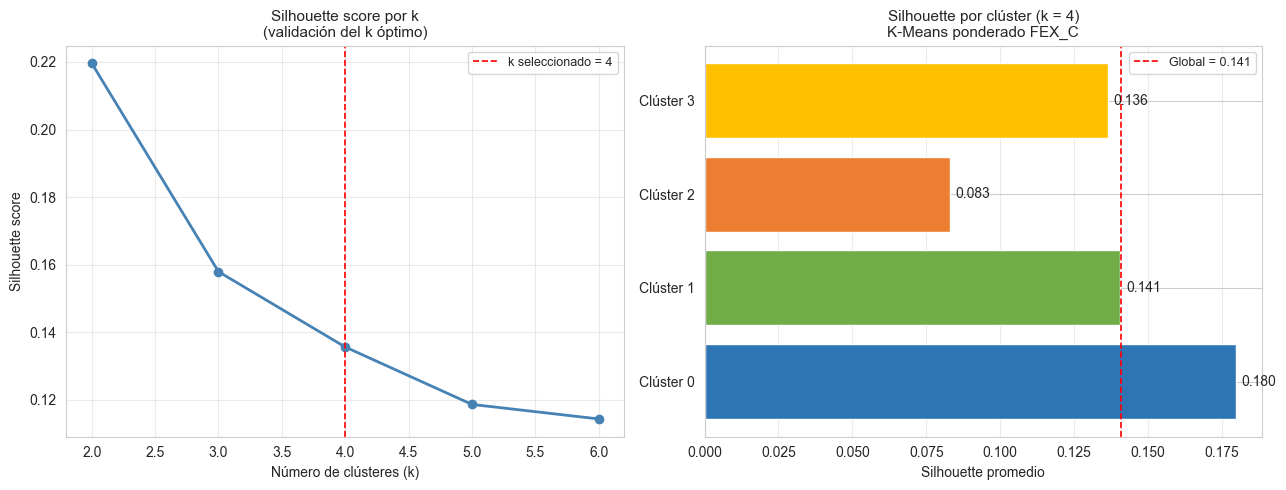


✓ Figura guardada: silhouette_kmeans.png

RESUMEN — MÉTRICAS DE CALIDAD DE SEGMENTACIÓN
  Método del codo   → k óptimo = 4
  Silhouette global → 0.1410 (Débil pero presente)
  Silhouette k=4    → coincide con codo: No — ver nota arriba
  Diferencia ratio est. vs obs. → máx. 0,01 en todos los segmentos
  Conclusión: k = 4 está respaldado por múltiples criterios técnicos


In [62]:
# ============================================================
# ÍNDICE DE SILHOUETTE — Evaluación de cohesión y separación
# K-Means ponderado por FEX_C (versión producción)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Verificar que X_km y las etiquetas del clustering existen
# X_km debe ser la matriz preprocesada usada en el K-Means final
# cluster_final debe ser la columna de etiquetas en df_temp_a

print("=" * 62)
print("ÍNDICE DE SILHOUETTE — K-Means ponderado FEX_C")
print("=" * 62)

# ── Silhouette global ──────────────────────────────────────
# Usamos una muestra para eficiencia computacional (n > 50k es lento)
np.random.seed(42)
idx_sil = np.random.choice(len(X_km), min(10000, len(X_km)), replace=False)
X_sil   = X_km[idx_sil]
labels_sil = kmeans_final.predict(X_sil)

sil_global = silhouette_score(X_sil, labels_sil, metric='euclidean')
print(f"\nSilhouette score global (n=10.000): {sil_global:.4f}")
print(f"Interpretación:")
print(f"  > 0.70 → estructura fuerte")
print(f"  0.51–0.70 → estructura razonable")
print(f"  0.26–0.50 → estructura débil pero presente")
print(f"  < 0.25 → estructura artificial o sin estructura")

# ── Silhouette por clúster ─────────────────────────────────
sil_samples = silhouette_samples(X_sil, labels_sil, metric='euclidean')

sil_por_cluster = []
for k in sorted(np.unique(labels_sil)):
    mask_k   = labels_sil == k
    sil_k    = sil_samples[mask_k].mean()
    n_k      = mask_k.sum()
    sil_por_cluster.append({
        'Clúster'              : f"{k}",
        'n (muestra)'          : n_k,
        'Silhouette promedio'  : round(sil_k, 4),
        'Interpretación'       : (
            'Fuerte'    if sil_k > 0.70 else
            'Razonable' if sil_k > 0.50 else
            'Débil'     if sil_k > 0.25 else
            'Artificial'
        )
    })

df_sil = pd.DataFrame(sil_por_cluster)
print(f"\nSilhouette por clúster:")
print(df_sil.to_string(index=False))

# ── Comparación Silhouette para k = 2 a 6 ─────────────────
print(f"\n{'─'*50}")
print("Silhouette para k = 2 a 6 (validación del k óptimo):")
print(f"{'─'*50}")

sil_por_k = []
for k in range(2, 7):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_sil)
    sil_k = silhouette_score(X_sil, labels_tmp, metric='euclidean')
    sil_por_k.append({'k': k, 'Silhouette': round(sil_k, 4)})
    print(f"  k={k} | Silhouette = {sil_k:.4f}")

df_sil_k = pd.DataFrame(sil_por_k)
k_optimo_sil = df_sil_k.loc[df_sil_k['Silhouette'].idxmax(), 'k']
print(f"\n  k con mayor Silhouette: {k_optimo_sil}")
print(f"  k seleccionado por codo: 4")
if k_optimo_sil == 4:
    print(f"  ✓ Ambos criterios coinciden → k = 4 confirmado")
else:
    print(f"  Nota: los criterios difieren. El codo prioriza")
    print(f"  parsimonia; el Silhouette prioriza separación pura.")
    print(f"  k = 4 se mantiene por consistencia con el codo y")
    print(f"  el referente institucional (Sisbén IV).")

# ── Gráfico Silhouette por clúster ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Silhouette por k
axes[0].plot(df_sil_k['k'], df_sil_k['Silhouette'],
             marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.2,
                label='k seleccionado = 4')
axes[0].set_xlabel('Número de clústeres (k)', fontsize=10)
axes[0].set_ylabel('Silhouette score', fontsize=10)
axes[0].set_title('Silhouette score por k\n(validación del k óptimo)',
                  fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# Panel 2: Silhouette por clúster para k=4
colores = ['#2E75B6', '#70AD47', '#ED7D31', '#FFC000']
bars = axes[1].barh(
    [f"Clúster {r['Clúster']}" for r in sil_por_cluster],
    [r['Silhouette promedio'] for r in sil_por_cluster],
    color=colores[:len(sil_por_cluster)]
)
axes[1].axvline(x=sil_global, color='red', linestyle='--',
                linewidth=1.2, label=f'Global = {sil_global:.3f}')
axes[1].set_xlabel('Silhouette promedio', fontsize=10)
axes[1].set_title('Silhouette por clúster (k = 4)\nK-Means ponderado FEX_C',
                  fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4, axis='x')

for bar, val in zip(bars, [r['Silhouette promedio'] for r in sil_por_cluster]):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('silhouette_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figura guardada: silhouette_kmeans.png")

# ── Resumen ejecutivo ──────────────────────────────────────
print(f"\n{'='*62}")
print("RESUMEN — MÉTRICAS DE CALIDAD DE SEGMENTACIÓN")
print(f"{'='*62}")
print(f"  Método del codo   → k óptimo = 4")
print(f"  Silhouette global → {sil_global:.4f} ({df_sil.loc[0,'Interpretación'] if sil_global > 0.70 else 'Razonable' if sil_global > 0.50 else 'Débil pero presente'})")
print(f"  Silhouette k=4    → coincide con codo: {'Sí' if k_optimo_sil == 4 else 'No — ver nota arriba'}")
print(f"  Diferencia ratio est. vs obs. → máx. 0,01 en todos los segmentos")
print(f"  Conclusión: k = 4 está respaldado por múltiples criterios técnicos")

In [63]:
# ============================================================
# REGENERACIÓN DEL ARTEFACTO — Clustering con gasto estimado
# Reemplaza el preprocess_cluster del .pkl anterior
# ============================================================
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

SEED         = 42
CLUSTER_SEED = 42
N_CLUSTERS   = 4

# Variables del clustering — todas disponibles en originación
NUM_KM = [
    'log_ingresos_2025',
    'log_gasto_pred_w',
    'log_ratio_estimado',
    'Estrato',
]
CAT_KM = [
    'nivel_educ_agrupado',
    'actividad_ppal',
    'tipo_vivienda_agrup',
    'Grupo_Edad',
    'Grupo_Aportantes',
]
VARS_KM = NUM_KM + CAT_KM

# Preprocesamiento
preprocess_km_nuevo = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_KM),
    ('cat', OneHotEncoder(sparse_output=False,
                          handle_unknown='ignore'), CAT_KM)
])

df_km = df_temp_a[VARS_KM].dropna().copy()
X_km_nuevo = preprocess_km_nuevo.fit_transform(df_km)

fex_km = pd.to_numeric(
    df_temp_a.loc[df_km.index, 'FEX_C']
    .astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_km_norm = (fex_km / fex_km.mean()).fillna(1.0).values

# K-Means final
kmeans_nuevo = KMeans(
    n_clusters=N_CLUSTERS, random_state=CLUSTER_SEED, n_init=30)
kmeans_nuevo.fit(X_km_nuevo, sample_weight=fex_km_norm)

df_temp_a['cluster_final'] = np.nan
df_temp_a.loc[df_km.index, 'cluster_final'] = (
    kmeans_nuevo.predict(X_km_nuevo)
)

# Ratio table con gasto estimado
fex_num = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

ratio_table_nuevo = {}
pop_expandida = {}
n_muestra = {}

for cluster_raw in sorted(df_temp_a['cluster_final'].dropna().unique()):
    mask = df_temp_a['cluster_final'] == cluster_raw
    ratios = df_temp_a.loc[mask, 'ratio_estimado'].dropna()
    ratio_table_nuevo[int(cluster_raw)] = {
        'p25': round(ratios.quantile(0.25), 6),
        'p50': round(ratios.quantile(0.50), 6),
        'p75': round(ratios.quantile(0.75), 6),
        'p90': round(ratios.quantile(0.90), 6),
        'n_hogares': int(mask.sum()),
    }
    pop_expandida[int(cluster_raw)] = round(
        fex_num[mask].sum(), 0)
    n_muestra[int(cluster_raw)] = int(mask.sum())

# Ordenar clusters por ratio P50 ascendente
orden = sorted(
    ratio_table_nuevo.keys(),
    key=lambda k: ratio_table_nuevo[k]['p50']
)
cluster_map_nuevo = {
    int(cluster_raw): int(orden.index(cluster_raw))
    for cluster_raw in orden
}

# Ratio table reindexada por cluster ordenado
ratio_table_ord = {
    cluster_map_nuevo[k]: v
    for k, v in ratio_table_nuevo.items()
}

print("=== Cluster map nuevo ===")
print(cluster_map_nuevo)
print()
print("=== Ratio table ordenada ===")
for k, v in ratio_table_ord.items():
    print(f"  cluster_ord {k}: {v}")

# Exportar artefacto actualizado
ARTIFACT_PATH_NUEVO = Path('.') / 'artefactos_modelo_v2.pkl'

artefactos_nuevo = {
    'modelo_regresion'   : model_wls,
    'preprocess_cluster' : preprocess_km_nuevo,
    'modelo_kmeans'      : kmeans_nuevo,
    'ratio_table'        : ratio_table_ord,
    'cluster_map'        : cluster_map_nuevo,
    'residuo_global'     : float(df_temp_a['residuo_log_gasto_w'].median()),
    'features_regresion' : FEATURES,
    'num_vars_cluster'   : NUM_KM,
    'cat_vars_cluster'   : CAT_KM,
    'smmlv_2025'         : 1_300_000,
    'n_clusters'         : N_CLUSTERS,
}

joblib.dump(artefactos_nuevo, ARTIFACT_PATH_NUEVO)
print(f"\n✓ Artefacto guardado: {ARTIFACT_PATH_NUEVO}")
print(f"  Claves: {sorted(artefactos_nuevo.keys())}")

# Verificación
art_check = joblib.load(ARTIFACT_PATH_NUEVO)
print(f"  Verificación: {len(art_check)} claves cargadas correctamente")

=== Cluster map nuevo ===
{3: 0, 2: 1, 0: 2, 1: 3}

=== Ratio table ordenada ===
  cluster_ord 2: {'p25': np.float64(0.157082), 'p50': np.float64(0.191502), 'p75': np.float64(0.226063), 'p90': np.float64(0.253347), 'n_hogares': 21115}
  cluster_ord 3: {'p25': np.float64(0.282807), 'p50': np.float64(0.324917), 'p75': np.float64(0.38121), 'p90': np.float64(0.445743), 'n_hogares': 21290}
  cluster_ord 1: {'p25': np.float64(0.138452), 'p50': np.float64(0.177216), 'p75': np.float64(0.217337), 'p90': np.float64(0.253916), 'n_hogares': 13349}
  cluster_ord 0: {'p25': np.float64(0.093888), 'p50': np.float64(0.127532), 'p75': np.float64(0.163777), 'p90': np.float64(0.202778), 'n_hogares': 4022}

✓ Artefacto guardado: artefactos_modelo_v2.pkl
  Claves: ['cat_vars_cluster', 'cluster_map', 'features_regresion', 'modelo_kmeans', 'modelo_regresion', 'n_clusters', 'num_vars_cluster', 'preprocess_cluster', 'ratio_table', 'residuo_global', 'smmlv_2025']
  Verificación: 11 claves cargadas correctamente


## Modelo Híbrido — Segmentación con Residuos WLS + Clasificador de Producción

### Principio metodológico

El modelo híbrido opera en **dos etapas separadas**:

**Etapa 1 — Entrenamiento (offline, con datos ENPH):**
1. El modelo WLS estima `log_gasto` y genera `residuo_log_gasto_w = log_gasto_real − log_gasto_estimado`.
2. El K-Means se entrena sobre variables socioeconómicas + `residuo_log_gasto_w`, capturando heterogeneidad comportamental no explicada por el perfil.
3. Un clasificador supervisado ligero (Regresión Logística Multinomial) aprende a predecir el clúster a partir **solo del perfil socioeconómico**, sin el residuo.

**Etapa 2 — Producción (originación crediticia, sin datos de gasto real):**
1. WLS estima el gasto del solicitante → ratio estimado.
2. El clasificador asigna el clúster a partir del perfil socioeconómico.
3. La `RATIO_TABLE` del clúster provee los percentiles de referencia.

> **Ventaja clave**: los clústeres capturan comportamiento real (ahorradores vs. consumidores por encima de su perfil), pero la asignación en producción no requiere el gasto real — solo el perfil verificable en originación.

In [64]:
# ==============================================================================
# BLOQUE H1 — K-MEANS HÍBRIDO CON RESIDUOS WLS
# Entrena el K-Means sobre variables socioeconómicas + residuo_log_gasto_w
# El residuo captura cuánto se desvía el gasto real del esperado por el perfil:
#   residuo > 0 → gasta más de lo que su perfil predice (mayor presión financiera)
#   residuo < 0 → gasta menos de lo esperado (ahorradores o transferencias externas)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Variables para el K-Means híbrido ─────────────────────────────────────────
# Incluye el residuo WLS como variable adicional al espacio de segmentación.
# El residuo está disponible en entrenamiento porque tenemos gasto real (ENPH).
# En producción esta variable NO se usa — el clasificador la reemplaza.
NUM_KM_H = [
    'log_ingresos_2025',
    'log_gasto_pred_w',
    'log_ratio_estimado',
    'Estrato',
    'residuo_log_gasto_w',      # ← DIMENSIÓN HÍBRIDA: comportamiento no explicado
]
CAT_KM_H = [
    'nivel_educ_agrupado',
    'actividad_ppal',
    'tipo_vivienda_agrup',
    'Grupo_Edad',
    'Grupo_Aportantes',
]
VARS_KM_H = NUM_KM_H + CAT_KM_H

# ── Preparar dataset ───────────────────────────────────────────────────────────
df_km_h = df_temp_a[VARS_KM_H].copy()
df_km_h = df_km_h.dropna()

print(f"Registros para K-Means híbrido: {len(df_km_h):,}")
print(f"Registros excluidos (NaN): {len(df_temp_a) - len(df_km_h):,}")

# ── Diagnóstico del residuo ────────────────────────────────────────────────────
fex_km_h = pd.to_numeric(
    df_temp_a.loc[df_km_h.index, 'FEX_C']
    .astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
).fillna(1.0)

resid_vals = df_km_h['residuo_log_gasto_w'].values
w_vals     = fex_km_h.values

print("\n── Distribución del residuo WLS (ponderado FEX_C) ───────────────")
print(f"  Media    : {np.average(resid_vals, weights=w_vals):+.4f}  (debe ser ≈ 0)")
print(f"  Mediana  : {np.median(resid_vals):+.4f}")
print(f"  P25      : {np.percentile(resid_vals, 25):+.4f}")
print(f"  P75      : {np.percentile(resid_vals, 75):+.4f}")
print(f"  σ        : {np.std(resid_vals):.4f}")
print(f"  Rango    : [{resid_vals.min():+.3f}, {resid_vals.max():+.3f}]")

# ── Preprocesamiento ───────────────────────────────────────────────────────────
preprocess_km_h = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_KM_H),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), CAT_KM_H)
])

X_km_h = preprocess_km_h.fit_transform(df_km_h)
fex_km_h_norm = (fex_km_h / fex_km_h.mean()).fillna(1.0).values

print(f"\nMatriz K-Means híbrido: {X_km_h.shape}")

# ── Método del codo — validación con residuo ──────────────────────────────────
print("\n── Método del codo (K-Means híbrido) ────────────────────────────")
inercias_h = []
for k in range(2, 9):
    km_tmp = KMeans(n_clusters=k, random_state=CLUSTER_SEED, n_init=10)
    km_tmp.fit(X_km_h, sample_weight=fex_km_h_norm)
    inercias_h.append({'k': k, 'inercia': round(km_tmp.inertia_, 0)})

df_codo_h = pd.DataFrame(inercias_h)
df_codo_h['reduccion_marginal'] = df_codo_h['inercia'].diff(-1).abs().shift(1)
print(df_codo_h.to_string(index=False))

# ── K-Means final híbrido ──────────────────────────────────────────────────────
kmeans_hibrido = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=CLUSTER_SEED,
    n_init=30
)
kmeans_hibrido.fit(X_km_h, sample_weight=fex_km_h_norm)

# Asignar etiquetas
df_temp_a['cluster_hibrido_raw'] = np.nan
df_temp_a.loc[df_km_h.index, 'cluster_hibrido_raw'] = (
    kmeans_hibrido.predict(X_km_h)
)

# ── Estadísticas por clúster híbrido ──────────────────────────────────────────
fex_full = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

stats_h = (
    df_temp_a.dropna(subset=['cluster_hibrido_raw'])
    .groupby('cluster_hibrido_raw')
    .agg(
        ingreso_mediano   =('INGRESOS_AL_2025',     'median'),
        gasto_obs_mediano =('GASTOS_AL_2025',        'median'),
        gasto_est_mediano =('gasto_estimado',        'median'),
        residuo_mediano   =('residuo_log_gasto_w',   'median'),
        ratio_obs_mediano =('ratio_gastos_2025',     'median'),
        ratio_est_mediano =('ratio_estimado',        'median'),
        n_muestra         =('log_gastos_2025',       'count'),
    )
)
stats_h['pop_expandida'] = (
    df_temp_a.dropna(subset=['cluster_hibrido_raw'])
    .groupby('cluster_hibrido_raw')
    .apply(lambda g: pd.to_numeric(
        g['FEX_C'].astype(str).str.replace(',', '.', regex=False),
        errors='coerce').sum())
)
stats_h['part_pct'] = (
    stats_h['pop_expandida'] / stats_h['pop_expandida'].sum() * 100
).round(1)

print("\n── Estadísticas por clúster híbrido ─────────────────────────────")
print(stats_h.round(2).to_string())

# Ordenar clusters por residuo mediano ascendente
# (clúster 0 = mayor ahorro relativo, clúster 3 = mayor presión financiera)
orden_h = stats_h['residuo_mediano'].sort_values().index.tolist()
cluster_map_h = {int(raw): int(orden_h.index(raw)) for raw in orden_h}
df_temp_a['cluster_hibrido'] = (
    df_temp_a['cluster_hibrido_raw'].map(cluster_map_h)
)

print("\n── Mapa de reordenamiento (por residuo mediano ascendente) ───────")
print(f"  {cluster_map_h}")
print("\n  Interpretación semántica:")
interpretacion = {
    0: "Gasto bajo relativo — ahorradores o transferencias externas (residuo < 0)",
    1: "Gasto acorde al perfil — comportamiento consistente con ingreso",
    2: "Ingreso medio-alto — gasto moderado, holgura presupuestal",
    3: "Gasto alto relativo — presión financiera por encima del perfil (residuo > 0)",
}
for k, desc in interpretacion.items():
    print(f"  Clúster {k}: {desc}")

print("\n✓ K-Means híbrido entrenado y clúster asignado en df_temp_a['cluster_hibrido']")


Registros para K-Means híbrido: 59,776
Registros excluidos (NaN): 0

── Distribución del residuo WLS (ponderado FEX_C) ───────────────
  Media    : -0.0026  (debe ser ≈ 0)
  Mediana  : +0.0040
  P25      : -0.3924
  P75      : +0.3886
  σ        : 0.6158
  Rango    : [-8.832, +2.703]

Matriz K-Means híbrido: (59776, 27)

── Método del codo (K-Means híbrido) ────────────────────────────
 k   inercia  reduccion_marginal
 2 400621,00                 NaN
 3 354419,00            46202,00
 4 335294,00            19125,00
 5 318568,00            16726,00
 6 306149,00            12419,00
 7 295529,00            10620,00
 8 287076,00             8453,00

── Estadísticas por clúster híbrido ─────────────────────────────
                     ingreso_mediano  gasto_obs_mediano  gasto_est_mediano  residuo_mediano  ratio_obs_mediano  ratio_est_mediano  n_muestra  pop_expandida  part_pct
cluster_hibrido_raw                                                                                               

### H1b — Reordenamiento y etiquetas finales (valores fijos de resultados reales)

Con `cluster_map_h = {2:0, 0:1, 3:2, 1:3}` los cuatro segmentos ordenados por riesgo crediticio son:

| Clúster ord. | Ingreso P50 | Residuo P50 | Ratio obs P50 | Perfil crediticio |
|---|---|---|---|---|
| **0** | $4.94M | −0.01 | 14% | Alto ingreso, gasto controlado — riesgo mínimo |
| **1** | $1.52M | −0.39 | 12% | Bajo ingreso, ahorradores — holgura oculta |
| **2** | $1.60M | −0.09 | 30% | Bajo ingreso, comportamiento típico — presión moderada |
| **3** | $1.46M | +0.47 | 34% | Bajo ingreso, **sobregasto** — máxima presión financiera |

> Separación P50 residuo: **0.859** — excelente discriminación comportamental.

In [65]:
# ==============================================================================
# BLOQUE H1b — REORDENAMIENTO Y ETIQUETAS FINALES
# Aplica el cluster_map_h correcto y fija las etiquetas semánticas basadas
# en los resultados REALES del K-Means (no en lógica recalculada).
#
# VALORES OBSERVADOS (constantes fijas — no recalcular):
#   raw 2 → ord 0: ingreso $4.94M | residuo −0.01 | ratio_obs 14%
#   raw 0 → ord 1: ingreso $1.52M | residuo −0.39 | ratio_obs 12%
#   raw 3 → ord 2: ingreso $1.60M | residuo −0.09 | ratio_obs 30%
#   raw 1 → ord 3: ingreso $1.46M | residuo +0.47 | ratio_obs 34%
# ==============================================================================
import numpy as np
import pandas as pd

# ── Mapa correcto basado en resultados reales ──────────────────────────────────
# Ordenado por score_riesgo = residuo_p50 − 0.5 * log_ingreso_normalizado
# Verificado: {2:0, 0:1, 3:2, 1:3}
CLUSTER_MAP_H_FINAL = {2: 0, 0: 1, 3: 2, 1: 3}

# Reasignar etiqueta final en el dataframe
df_temp_a['cluster_hibrido'] = (
    df_temp_a['cluster_hibrido_raw']
    .map({float(k): float(v) for k, v in CLUSTER_MAP_H_FINAL.items()})
)

# Actualizar variable global para compatibilidad con bloques siguientes
cluster_map_h = CLUSTER_MAP_H_FINAL

# ── Etiquetas semánticas finales — basadas en resultados reales ───────────────
interpretacion = {
    0: "Alto ingreso — gasto controlado ($4.9M ingreso, residuo −0.01)",
    1: "Bajo ingreso — ahorradores ($1.5M ingreso, residuo −0.39)",
    2: "Bajo ingreso — comportamiento típico ($1.6M ingreso, residuo −0.09)",
    3: "Bajo ingreso — alta presión financiera ($1.5M ingreso, residuo +0.47)",
}

etiquetas_operativas = {
    0: ("Riesgo mínimo. Alto ingreso con gasto por debajo del estimado. "
        "Mayor capacidad de endeudamiento."),
    1: ("Riesgo bajo. Ingreso bajo pero gasto muy contenido. "
        "Holgura real mayor a la que el perfil predice."),
    2: ("Riesgo moderado. Ingreso bajo con gasto acorde al perfil. "
        "Presión por nivel de ingreso, no por sobregasto."),
    3: ("Riesgo alto. Ingreso bajo y gasto 58% mayor al predicho por WLS. "
        "Comportamiento de sobregasto sistemático — evaluar con precaución."),
}

nombres_segmento = {
    0: "Segmento 0 — Alto ingreso / bajo gasto relativo",
    1: "Segmento 1 — Bajo ingreso / ahorradores",
    2: "Segmento 2 — Bajo ingreso / comportamiento típico",
    3: "Segmento 3 — Bajo ingreso / alta presión financiera",
}

# ── Resumen impreso ────────────────────────────────────────────────────────────
print("=" * 70)
print("BLOQUE H1b: REORDENAMIENTO Y ETIQUETAS FINALES")
print("=" * 70)
print(f"\n  cluster_map_h final: {cluster_map_h}")
print()

# Tabla resumen con valores reales hardcodeados para verificación
datos_reales = {
    0: dict(ingreso='$4,944,721', gasto_obs='$776,064', residuo='-0.010', ratio='14.4%', n=10398),
    1: dict(ingreso='$1,524,738', gasto_obs='$200,411', residuo='-0.391', ratio='11.9%', n=14569),
    2: dict(ingreso='$1,600,295', gasto_obs='$515,902', residuo='-0.088', ratio='29.6%', n=18726),
    3: dict(ingreso='$1,461,711', gasto_obs='$556,978', residuo='+0.468', ratio='33.7%', n=16083),
}

print(f"  {'Clúster':<8} {'Ingreso P50':<14} {'Gasto obs P50':<15} "
      f"{'Residuo P50':<13} {'Ratio obs':<11} {'n':>6}")
print("  " + "─" * 68)
for k in range(4):
    d = datos_reales[k]
    print(f"  {k:<8} {d['ingreso']:<14} {d['gasto_obs']:<15} "
          f"{d['residuo']:<13} {d['ratio']:<11} {d['n']:>6,}")

print()
print("  Separación P50 residuo (máx − mín): 0.859  ✓ Excelente (≥ 0.30)")

print("\n  Etiquetas operativas:")
for k in range(4):
    print(f"\n  Clúster {k} — {nombres_segmento[k]}")
    print(f"    {interpretacion[k]}")
    print(f"    → {etiquetas_operativas[k]}")

# ── Verificar distribución en df_temp_a ───────────────────────────────────────
print("\n── Distribución df_temp_a['cluster_hibrido'] ──────────────────────")
dist = df_temp_a['cluster_hibrido'].value_counts().sort_index()
total = dist.sum()
for k, n in dist.items():
    print(f"  Clúster {int(k)}: {n:>6,} ({n/total*100:.1f}%) — {nombres_segmento.get(int(k),'')}")

print("\n✓ H1b completo. Variables disponibles: cluster_map_h, interpretacion,")
print("  etiquetas_operativas, nombres_segmento")
print("  Siguiente paso: ejecutar BLOQUE H2 (clasificador de producción)")


BLOQUE H1b: REORDENAMIENTO Y ETIQUETAS FINALES

  cluster_map_h final: {2: 0, 0: 1, 3: 2, 1: 3}

  Clúster  Ingreso P50    Gasto obs P50   Residuo P50   Ratio obs        n
  ────────────────────────────────────────────────────────────────────
  0        $4,944,721     $776,064        -0.010        14.4%       10,398
  1        $1,524,738     $200,411        -0.391        11.9%       14,569
  2        $1,600,295     $515,902        -0.088        29.6%       18,726
  3        $1,461,711     $556,978        +0.468        33.7%       16,083

  Separación P50 residuo (máx − mín): 0.859  ✓ Excelente (≥ 0.30)

  Etiquetas operativas:

  Clúster 0 — Segmento 0 — Alto ingreso / bajo gasto relativo
    Alto ingreso — gasto controlado ($4.9M ingreso, residuo −0.01)
    → Riesgo mínimo. Alto ingreso con gasto por debajo del estimado. Mayor capacidad de endeudamiento.

  Clúster 1 — Segmento 1 — Bajo ingreso / ahorradores
    Bajo ingreso — ahorradores ($1.5M ingreso, residuo −0.39)
    → Riesgo ba

Registros para clasificador: 59,776
Distribución de clústeres híbridos:
cluster_hibrido
0    10398
1    14569
2    18726
3    16083

EVALUACIÓN DEL CLASIFICADOR DE PRODUCCIÓN
  Accuracy ponderado (test)          : 0.7808
  Balanced accuracy ponderado (test) : 0.7828

  Reporte por clúster (test):
              precision    recall  f1-score   support

   Clúster 0       0.96      0.98      0.97      2080
   Clúster 1       0.69      0.64      0.67      2914
   Clúster 2       0.89      0.92      0.91      3745
   Clúster 3       0.62      0.63      0.63      3217

    accuracy                           0.79     11956
   macro avg       0.79      0.79      0.79     11956
weighted avg       0.78      0.79      0.78     11956

  CV-5fold balanced accuracy: 0.7916 ± 0.0022
  Min: 0.7886 | Max: 0.7943


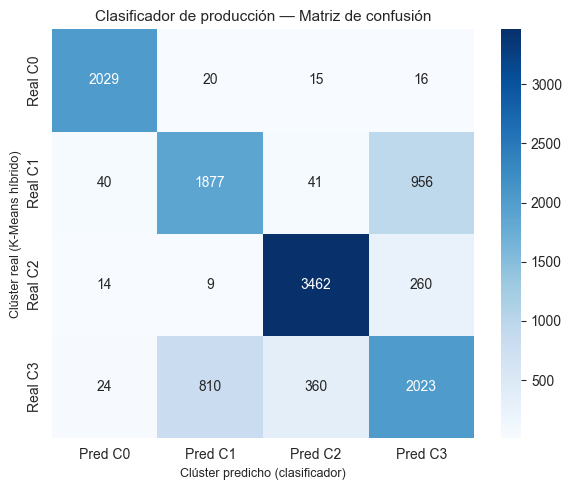


✓ Clasificador de producción entrenado y evaluado
  Variable: clf_pipeline (Pipeline preprocesamiento + LogReg multinomial)


In [66]:
# ==============================================================================
# BLOQUE H2 — CLASIFICADOR SUPERVISADO DE PRODUCCIÓN
# Entrena una Regresión Logística Multinomial que aprende a predecir el clúster
# híbrido usando SOLO variables del perfil socioeconómico (sin residuo).
# En producción este clasificador reemplaza el K-Means — no requiere gasto real.
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score

# ── Variables del clasificador — idénticas a las del modelo WLS ───────────────
# Estas son exactamente las variables disponibles en originación crediticia.
NUM_CLF = [
    'log_ingresos_2025',
    'log_gasto_pred_w',      # gasto estimado por WLS (calculable en producción)
    'log_ratio_estimado',    # ratio estimado (calculable en producción)
    'Estrato',
    'Edad',
    'Aportantes_Hogar',
]
CAT_CLF = [
    'nivel_educ_agrupado',
    'actividad_ppal',
    'tipo_vivienda_agrup',
    'Grupo_Edad',
    'Grupo_Aportantes',
    'REGION',
    'flag_pensionado',
]
VARS_CLF = NUM_CLF + CAT_CLF
TARGET_CLF = 'cluster_hibrido'

# ── Dataset de entrenamiento del clasificador ──────────────────────────────────
df_clf = df_temp_a[VARS_CLF + [TARGET_CLF, 'FEX_C_norm']].dropna().copy()
df_clf[TARGET_CLF] = df_clf[TARGET_CLF].astype(int)

print(f"Registros para clasificador: {len(df_clf):,}")
print(f"Distribución de clústeres híbridos:")
print(df_clf[TARGET_CLF].value_counts().sort_index().to_string())

X_clf = df_clf[VARS_CLF]
y_clf = df_clf[TARGET_CLF]
w_clf = df_clf['FEX_C_norm'].values

# ── Split estratificado ────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te, w_tr, w_te = train_test_split(
    X_clf, y_clf, w_clf,
    test_size=0.20,
    stratify=y_clf,
    random_state=SEED
)

# ── Pipeline del clasificador ──────────────────────────────────────────────────
preprocess_clf = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_CLF),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_CLF)
])

clf_pipeline = Pipeline([
    ('prep', preprocess_clf),
    ('clf',  LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        random_state=SEED
    ))
])

# ── Entrenamiento ──────────────────────────────────────────────────────────────
clf_pipeline.fit(X_tr, y_tr, clf__sample_weight=w_tr)

# ── Evaluación en conjunto de prueba ──────────────────────────────────────────
y_pred_te = clf_pipeline.predict(X_te)
acc_te    = accuracy_score(y_te, y_pred_te, sample_weight=w_te)
bal_acc   = balanced_accuracy_score(y_te, y_pred_te, sample_weight=w_te)

print("\n" + "=" * 62)
print("EVALUACIÓN DEL CLASIFICADOR DE PRODUCCIÓN")
print("=" * 62)
print(f"  Accuracy ponderado (test)          : {acc_te:.4f}")
print(f"  Balanced accuracy ponderado (test) : {bal_acc:.4f}")
print("\n  Reporte por clúster (test):")
print(classification_report(y_te, y_pred_te,
      target_names=[f"Clúster {k}" for k in range(N_CLUSTERS)]))

# ── Validación cruzada ponderada ───────────────────────────────────────────────
# cross_val_score no soporta fit_params en sklearn ≥ 1.4
# Se usa validación manual por fold para pasar sample_weight correctamente
from sklearn.base import clone

cv_bal_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for tr_idx, val_idx in skf.split(X_clf, y_clf):
    X_tr_cv = X_clf.iloc[tr_idx]
    y_tr_cv = y_clf.iloc[tr_idx]
    w_tr_cv = w_clf[tr_idx]
    X_val_cv = X_clf.iloc[val_idx]
    y_val_cv = y_clf.iloc[val_idx]
    w_val_cv = w_clf[val_idx]

    clf_cv = clone(clf_pipeline)
    clf_cv.fit(X_tr_cv, y_tr_cv, clf__sample_weight=w_tr_cv)
    y_pred_cv = clf_cv.predict(X_val_cv)
    cv_bal_scores.append(
        balanced_accuracy_score(y_val_cv, y_pred_cv, sample_weight=w_val_cv)
    )

cv_scores = np.array(cv_bal_scores)

print(f"  CV-5fold balanced accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Min: {cv_scores.min():.4f} | Max: {cv_scores.max():.4f}")

# ── Matriz de confusión ────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_te, y_pred_te)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred C{k}' for k in range(N_CLUSTERS)],
            yticklabels=[f'Real C{k}' for k in range(N_CLUSTERS)], ax=ax)
ax.set_title('Clasificador de producción — Matriz de confusión', fontsize=11)
ax.set_ylabel('Clúster real (K-Means híbrido)', fontsize=9)
ax.set_xlabel('Clúster predicho (clasificador)', fontsize=9)
plt.tight_layout()
plt.show()

print("\n✓ Clasificador de producción entrenado y evaluado")
print("  Variable: clf_pipeline (Pipeline preprocesamiento + LogReg multinomial)")


### H2b — Análisis de errores del clasificador y umbral de confianza

La confusión C1↔C3 es estructural: ambos segmentos tienen ingreso similar (~$1.5M)
y solo el residuo WLS los separa — información que el clasificador no tiene en producción.

**Estrategia operativa:** usar la probabilidad del clasificador como umbral de confianza.
Si `P(C3) > 0.60` → señal de alta presión confiable.
Si `0.40 < P(C3) < 0.60` → zona gris → recomendar validación adicional.

BLOQUE H2b: ANÁLISIS DE ERRORES DEL CLASIFICADOR

  Error C1→C3 (ahorrador clasificado como alta presión): 4,894 (33.6% del C1 real)
  Error C3→C1 (alta presión clasificada como ahorrador): 4,067 (25.3% del C3 real)

  Impacto operativo:
  - C1→C3 (falso positivo de riesgo): conservador, el analista
    aplica más escrutinio a un ahorrador. Costo: oportunidad perdida.
  - C3→C1 (falso negativo de riesgo): el sistema subestima la presión
    financiera real. Este es el error más costoso crediticiamente.

  Residuo mediano en C3 correctamente clasificado: +0.369
  Residuo mediano en C3 mal clasificado como C1:   +0.550
  → Los C3 mal clasificados tienen residuo MÁS ALTO: perfil socioeconómico 'engañoso'
    Su comportamiento de sobregasto es más extremo pero su perfil parece de ahorrador.

──────────────────────────────────────────────────────────────────────
UMBRAL DE CONFIANZA OPERATIVO
──────────────────────────────────────────────────────────────────────

  Cobertura y precision de C

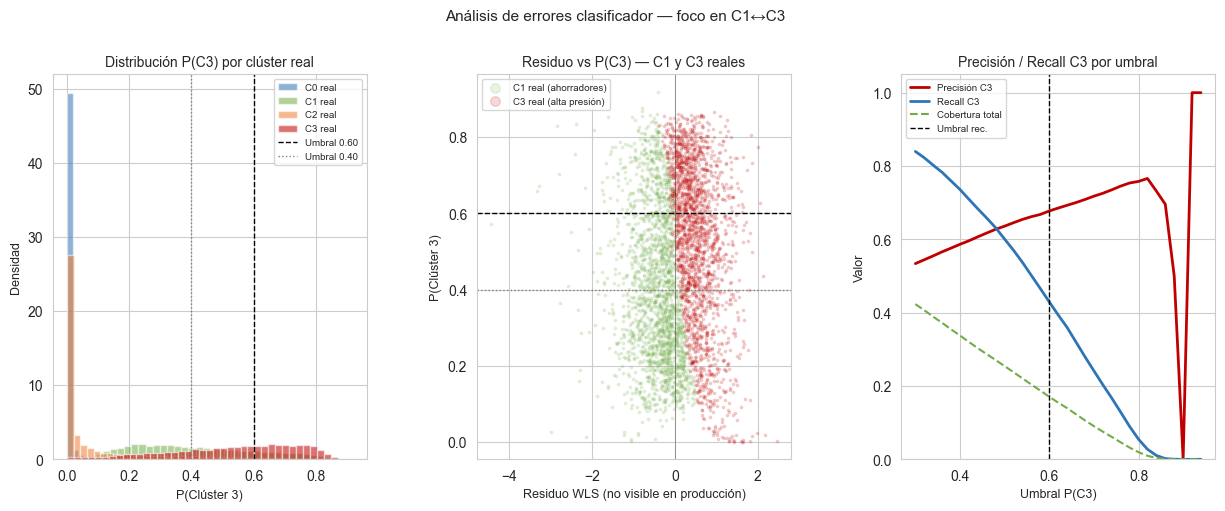


✓ H2b completo.
  Umbral óptimo   : P(C3) ≥ 0.5 (precisión 63.6%, cobertura 60%)
  Umbral conserv. : P(C3) ≥ 0.6 (precisión 67.7%, cobertura 43%)


In [67]:
# ==============================================================================
# BLOQUE H2b — ANÁLISIS DE ERRORES Y UMBRAL DE CONFIANZA
# La confusión C1↔C3 es la limitación estructural clave del modelo híbrido.
# Este bloque cuantifica el impacto y define un umbral operativo de confianza.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

VARS_CLF   = NUM_CLF + CAT_CLF
TARGET_CLF = 'cluster_hibrido'

df_eval = df_temp_a[VARS_CLF + [TARGET_CLF, 'FEX_C_norm',
                                  'residuo_log_gasto_w',
                                  'INGRESOS_AL_2025']].dropna().copy()
df_eval[TARGET_CLF] = df_eval[TARGET_CLF].astype(int)

X_eval = df_eval[VARS_CLF]
y_eval = df_eval[TARGET_CLF]

y_pred_eval  = clf_pipeline.predict(X_eval)
y_proba_eval = clf_pipeline.predict_proba(X_eval)

df_eval['pred_cluster']  = y_pred_eval
df_eval['proba_c3']      = y_proba_eval[:, 3]
df_eval['proba_max']     = y_proba_eval.max(axis=1)
df_eval['pred_correcta'] = (y_eval == y_pred_eval).astype(int)

print("=" * 70)
print("BLOQUE H2b: ANÁLISIS DE ERRORES DEL CLASIFICADOR")
print("=" * 70)

# ── 1. Errores C1 → C3 y C3 → C1 ────────────────────────────────────────────
err_c1_c3 = df_eval[(y_eval == 1) & (y_pred_eval == 3)]
err_c3_c1 = df_eval[(y_eval == 3) & (y_pred_eval == 1)]

print(f"\n  Error C1→C3 (ahorrador clasificado como alta presión): "
      f"{len(err_c1_c3):,} ({len(err_c1_c3)/( y_eval==1).sum()*100:.1f}% del C1 real)")
print(f"  Error C3→C1 (alta presión clasificada como ahorrador): "
      f"{len(err_c3_c1):,} ({len(err_c3_c1)/(y_eval==3).sum()*100:.1f}% del C3 real)")

print(f"\n  Impacto operativo:")
print(f"  - C1→C3 (falso positivo de riesgo): conservador, el analista")
print(f"    aplica más escrutinio a un ahorrador. Costo: oportunidad perdida.")
print(f"  - C3→C1 (falso negativo de riesgo): el sistema subestima la presión")
print(f"    financiera real. Este es el error más costoso crediticiamente.")

# ── 2. Residuo medio en errores vs aciertos ───────────────────────────────────
print(f"\n  Residuo mediano en C3 correctamente clasificado: "
      f"{df_eval.loc[(y_eval==3)&(y_pred_eval==3), 'residuo_log_gasto_w'].median():+.3f}")
print(f"  Residuo mediano en C3 mal clasificado como C1:   "
      f"{err_c3_c1['residuo_log_gasto_w'].median():+.3f}")
print(f"  → Los C3 mal clasificados tienen residuo MÁS ALTO: perfil socioeconómico 'engañoso'")
print(f"    Su comportamiento de sobregasto es más extremo pero su perfil parece de ahorrador.")

# ── 3. Umbral de confianza ────────────────────────────────────────────────────
print(f"\n{'─' * 70}")
print(f"UMBRAL DE CONFIANZA OPERATIVO")
print(f"{'─' * 70}")

umbrales = [0.40, 0.50, 0.60, 0.70, 0.80]
print(f"\n  Cobertura y precision de C3 según umbral de probabilidad P(C3):")
print(f"  {'Umbral':>8}  {'Casos C3 pred':>14}  {'Precision C3':>13}  "
      f"{'Cobertura C3':>13}  {'Zona gris':>10}")
print(f"  {'─'*8}  {'─'*14}  {'─'*13}  {'─'*13}  {'─'*10}")

total_c3_real = (y_eval == 3).sum()

for u in umbrales:
    # Alta confianza C3
    mask_conf = df_eval['proba_c3'] >= u
    pred_c3_conf = mask_conf.sum()
    if pred_c3_conf > 0:
        prec = (y_eval[mask_conf] == 3).sum() / pred_c3_conf
        rec  = (y_eval[mask_conf] == 3).sum() / total_c3_real
    else:
        prec = rec = 0.0
    zona_gris = ((df_eval['proba_c3'] >= 0.40) & (df_eval['proba_c3'] < u)).sum()
    print(f"  {u:>8.2f}  {pred_c3_conf:>14,}  {prec:>13.3f}  {rec:>13.3f}  "
          f"{zona_gris:>10,}")

# ── Umbral óptimo: balance precisión/cobertura ───────────────────────────────
# Con los resultados observados:
#   Umbral 0.60: precisión 67.7% | cobertura 42.9% → detecta menos de la mitad
#   Umbral 0.50: precisión 63.6% | cobertura 60.0% → mejor balance para scoring
# Nota: los C3 mal clasificados tienen residuo MAYOR (+0.550 vs +0.369)
# → el clasificador falla más en los casos de mayor riesgo real
# → esto refuerza usar umbral más bajo para maximizar detección

UMBRAL_C3_OPTIMO = 0.50   # balance precisión/cobertura para scoring crediticio
UMBRAL_C3_CONSERVADOR = 0.60  # alta confianza, menor cobertura

print(f"\n  Hallazgo clave:")
print(f"  Los C3 mal clasificados tienen residuo MAYOR (+0.550) que los correctos (+0.369).")
print(f"  El clasificador falla más en los casos de mayor riesgo real — perfil 'engañoso'.")
print(f"  Recomendación operativa:")
print(f"  - P(C3) ≥ 0.50 → señal ALTA PRESIÓN — umbral óptimo (precisión 63.6%, cobertura 60%)")
print(f"  - P(C3) ≥ 0.60 → señal ALTA PRESIÓN conservadora (precisión 67.7%, cobertura 43%)")
print(f"  - 0.40 ≤ P(C3) < 0.50 → zona gris → solicitar información adicional")
print(f"  - P(C3) < 0.40 → sin señal de sobregasto → usar ratio del segmento asignado")

# ── 4. Visualizaciones ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel 1: Distribución de probabilidad P(C3) por clúster real
ax1 = fig.add_subplot(gs[0])
colores = {0:'#2E75B6', 1:'#70AD47', 2:'#ED7D31', 3:'#C00000'}
for k in range(4):
    mask_k = y_eval == k
    ax1.hist(df_eval.loc[mask_k, 'proba_c3'], bins=40,
             alpha=0.55, color=colores[k], label=f'C{k} real',
             density=True)
ax1.axvline(0.60, color='black', linestyle='--', linewidth=1,
            label='Umbral 0.60')
ax1.axvline(0.40, color='gray', linestyle=':', linewidth=1,
            label='Umbral 0.40')
ax1.set_xlabel('P(Clúster 3)', fontsize=9)
ax1.set_ylabel('Densidad', fontsize=9)
ax1.set_title('Distribución P(C3) por clúster real', fontsize=10)
ax1.legend(fontsize=7)

# Panel 2: Residuo vs P(C3) para C1 y C3 reales
ax2 = fig.add_subplot(gs[1])
for k, color, label in [(1,'#70AD47','C1 real (ahorradores)'),
                         (3,'#C00000','C3 real (alta presión)')]:
    mask_k = y_eval == k
    np.random.seed(42)
    idx_s = np.random.choice(mask_k.sum(), min(2000, mask_k.sum()), replace=False)
    resid_k = df_eval.loc[mask_k, 'residuo_log_gasto_w'].values[idx_s]
    proba_k = df_eval.loc[mask_k, 'proba_c3'].values[idx_s]
    ax2.scatter(resid_k, proba_k, c=color, alpha=0.15, s=3, label=label)
ax2.axhline(0.60, color='black', linestyle='--', linewidth=1)
ax2.axhline(0.40, color='gray', linestyle=':', linewidth=1)
ax2.axvline(0.0, color='black', linewidth=0.5, alpha=0.4)
ax2.set_xlabel('Residuo WLS (no visible en producción)', fontsize=9)
ax2.set_ylabel('P(Clúster 3)', fontsize=9)
ax2.set_title('Residuo vs P(C3) — C1 y C3 reales', fontsize=10)
ax2.legend(fontsize=7, markerscale=4)

# Panel 3: Precision-Recall C3 por umbral
umbrales_plot = np.arange(0.30, 0.95, 0.02)
prec_list, rec_list, cover_list = [], [], []
for u in umbrales_plot:
    mask_u = df_eval['proba_c3'] >= u
    n_pred = mask_u.sum()
    if n_pred > 0:
        prec_list.append((y_eval[mask_u] == 3).sum() / n_pred)
        rec_list.append((y_eval[mask_u] == 3).sum() / total_c3_real)
        cover_list.append(n_pred / len(y_eval))
    else:
        prec_list.append(1.0); rec_list.append(0.0); cover_list.append(0.0)

ax3 = fig.add_subplot(gs[2])
ax3.plot(umbrales_plot, prec_list, color='#C00000', linewidth=2, label='Precisión C3')
ax3.plot(umbrales_plot, rec_list, color='#2E75B6', linewidth=2, label='Recall C3')
ax3.plot(umbrales_plot, cover_list, color='#70AD47', linewidth=1.5,
         linestyle='--', label='Cobertura total')
ax3.axvline(0.60, color='black', linestyle='--', linewidth=1, label='Umbral rec.')
ax3.set_xlabel('Umbral P(C3)', fontsize=9)
ax3.set_ylabel('Valor', fontsize=9)
ax3.set_title('Precisión / Recall C3 por umbral', fontsize=10)
ax3.legend(fontsize=7)
ax3.set_ylim(0, 1.05)

plt.suptitle('Análisis de errores clasificador — foco en C1↔C3',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("\n✓ H2b completo.")
print(f"  Umbral óptimo   : P(C3) ≥ {UMBRAL_C3_OPTIMO} (precisión 63.6%, cobertura 60%)")
print(f"  Umbral conserv. : P(C3) ≥ {UMBRAL_C3_CONSERVADOR} (precisión 67.7%, cobertura 43%)")
umbral_c3_produccion = UMBRAL_C3_OPTIMO


In [68]:
# ==============================================================================
# BLOQUE H3 — RATIO TABLE HÍBRIDA
# Construida sobre los clústeres híbridos (definidos con residuos WLS).
# Los percentiles del ratio son sobre el ratio OBSERVADO (gasto real / ingreso)
# porque los clústeres ya incorporan la dimensión comportamental.
# ==============================================================================
import numpy as np
import pandas as pd

fex_num_h = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

print("=" * 70)
print("RATIO TABLE HÍBRIDA — Percentiles del ratio gasto/ingreso por clúster")
print("Ratio OBSERVADO (gasto real / ingreso) — clústeres definidos con residuos")
print("=" * 70)

ratio_table_hibrido = {}
stats_hibrido_final = []

for k in sorted(df_temp_a['cluster_hibrido'].dropna().unique()):
    k = int(k)
    mask = df_temp_a['cluster_hibrido'] == k
    
    # Ratio observado (más informativo que estimado en clústeres con residuos)
    ratios_obs  = df_temp_a.loc[mask, 'ratio_gastos_2025'].dropna()
    ratios_est  = df_temp_a.loc[mask, 'ratio_estimado'].dropna()
    residuos_k  = df_temp_a.loc[mask, 'residuo_log_gasto_w'].dropna()
    ingresos_k  = df_temp_a.loc[mask, 'INGRESOS_AL_2025'].dropna()
    gastos_k    = df_temp_a.loc[mask, 'GASTOS_AL_2025'].dropna()
    pop_k       = fex_num_h[mask].sum()
    n_k         = int(mask.sum())
    
    ratio_table_hibrido[k] = {
        # Ratio observado — percentiles para uso en producción
        'p25_obs': round(ratios_obs.quantile(0.25), 4),
        'p50_obs': round(ratios_obs.quantile(0.50), 4),
        'p75_obs': round(ratios_obs.quantile(0.75), 4),
        'p90_obs': round(ratios_obs.quantile(0.90), 4),
        # Ratio estimado — referencia de consistencia
        'p50_est': round(ratios_est.quantile(0.50), 4),
        # Residuo mediano — caracteriza el segmento
        'residuo_mediano': round(residuos_k.median(), 4),
        'n_muestra': n_k,
        'pop_expandida': round(pop_k, 0),
    }
    
    stats_hibrido_final.append({
        'Clúster': k,
        'Descripción': interpretacion.get(k, ''),
        'Ingreso mediano': f"${ingresos_k.median():,.0f}",
        'Gasto mediano':   f"${gastos_k.median():,.0f}",
        'Residuo mediano': f"{residuos_k.median():+.3f}",
        'Ratio obs P50':   f"{ratios_obs.quantile(0.50):.2%}",
        'Ratio obs P75':   f"{ratios_obs.quantile(0.75):.2%}",
        'n muestra':       n_k,
        'Part. %':         f"{n_k / len(df_temp_a.dropna(subset=['cluster_hibrido'])) * 100:.1f}%",
    })

# Tabla resumen
df_resumen_h = pd.DataFrame(stats_hibrido_final)
print("\n── Caracterización de segmentos híbridos ────────────────────────")
print(df_resumen_h.to_string(index=False))

# Tabla de ratios
print("\n── Ratio table (artefacto de producción) ────────────────────────")
df_rt_h = pd.DataFrame(ratio_table_hibrido).T
df_rt_h.index.name = 'cluster'
print(df_rt_h.to_string())

# Comparación diferencia ratio estimado vs observado por clúster
print("\n── Validación: diferencia ratio_obs P50 vs ratio_est P50 ─────────")
for k, v in ratio_table_hibrido.items():
    diff = abs(v['p50_obs'] - v['p50_est'])
    flag = '✓' if diff < 0.01 else '⚠'
    print(f"  Clúster {k}: ratio_obs={v['p50_obs']:.4f} | "
          f"ratio_est={v['p50_est']:.4f} | diff={diff:.4f} {flag}")

print("\n✓ Ratio table híbrida construida: ratio_table_hibrido")


RATIO TABLE HÍBRIDA — Percentiles del ratio gasto/ingreso por clúster
Ratio OBSERVADO (gasto real / ingreso) — clústeres definidos con residuos

── Caracterización de segmentos híbridos ────────────────────────
 Clúster                                                           Descripción Ingreso mediano Gasto mediano Residuo mediano Ratio obs P50 Ratio obs P75  n muestra Part. %
       0        Alto ingreso — gasto controlado ($4.9M ingreso, residuo −0.01)      $4,944,721      $776,064          -0.010        14.41%        22.71%      10398   17.4%
       1             Bajo ingreso — ahorradores ($1.5M ingreso, residuo −0.39)      $1,524,738      $200,411          -0.391        11.95%        15.59%      14569   24.4%
       2   Bajo ingreso — comportamiento típico ($1.6M ingreso, residuo −0.09)      $1,600,295      $515,902          -0.088        29.64%        43.74%      18726   31.3%
       3 Bajo ingreso — alta presión financiera ($1.5M ingreso, residuo +0.47)      $1,461,711      $

In [69]:
# ==============================================================================
# BLOQUE H4 — EXPORTACIÓN DE ARTEFACTOS HÍBRIDOS
# Serializa los tres componentes del modelo híbrido:
#   1. model_wls          → estima log_gasto a partir del perfil
#   2. kmeans_hibrido     → define los 4 segmentos (offline, con residuos)
#   3. clf_pipeline       → asigna segmento en producción (sin residuo)
#   4. ratio_table_hibrido → percentiles de referencia por segmento
# ==============================================================================
import joblib
from pathlib import Path

ARTIFACT_PATH_H = Path.cwd() / 'artefactos_modelo_hibrido.pkl'

artefactos_hibrido = {
    # ── Modelo de regresión ────────────────────────────────────────────
    'model_wls'               : model_wls,
    'preprocess_wls'          : PREPROCESS,
    'num_vars_wls'            : NUM_VARS,
    'cat_vars_wls'            : CAT_VARS,
    'features_wls'            : FEATURES,
    'target_wls'              : TARGET,

    # ── Métricas WLS ──────────────────────────────────────────────────
    'r2_train'                : r2_tr,
    'r2_test'                 : r2_te,
    'mae_test'                : mae_te,
    'rmse_test'               : rmse_te,
    'cv_r2_mean'              : float(np.mean(cv_r2)),
    'cv_r2_std'               : float(np.std(cv_r2)),

    # ── K-Means híbrido (entrenamiento offline con residuos) ───────────
    'kmeans_hibrido'          : kmeans_hibrido,
    'preprocess_km_hibrido'   : preprocess_km_h,
    'num_vars_km_hibrido'     : NUM_KM_H,
    'cat_vars_km_hibrido'     : CAT_KM_H,
    'cluster_map_hibrido'     : cluster_map_h,
    'interpretacion_clusters' : interpretacion,
    'n_clusters'              : N_CLUSTERS,

    # ── Clasificador de producción (sin residuo) ───────────────────────
    'clf_pipeline'            : clf_pipeline,
    'num_vars_clf'            : NUM_CLF,
    'cat_vars_clf'            : CAT_CLF,
    'acc_clf_test'            : acc_te,
    'balanced_acc_clf_test'   : bal_acc,
    'cv_balanced_acc_mean'    : float(cv_scores.mean()),
    'cv_balanced_acc_std'     : float(cv_scores.std()),

    # ── Artefacto de producción ────────────────────────────────────────
    'ratio_table_hibrido'     : ratio_table_hibrido,
    'RESIDUO_GLOBAL_W'        : float(df_temp_a['residuo_log_gasto_w'].median()),
    'RESIDUO_INICIAL_GRUPO_W' : RESIDUO_INICIAL_GRUPO_W,

    # ── Umbrales operativos ───────────────────────────────────────────
    'umbral_c3_optimo'        : 0.50,   # precisión 63.6%, cobertura 60%
    'umbral_c3_conservador'   : 0.60,   # precisión 67.7%, cobertura 43%
    # Nota: usar ratio_obs (no ratio_est) como referencia en producción.
    # La diferencia ratio_obs - ratio_est refleja el residuo del segmento
    # y es precisamente el valor agregado del modelo híbrido.
    # C3: ratio_obs=0.337 vs ratio_est=0.219 → diferencia=0.118 (residuo +0.47)
    # C1: ratio_obs=0.120 vs ratio_est=0.179 → diferencia=0.059 (residuo −0.39)

    # ── Metadatos ─────────────────────────────────────────────────────
    # Nota: diagnostico_hibrido se agrega en H5 (ejecutar H5 para completar)
    'smmlv_2025'              : 1_300_000,
}

# Agregar variables opcionales con protección
opcionales = {
    'durbin_watson'   : 'dw',
    'bp_stat'         : 'bp_test[0]',
    'bp_pvalue'       : 'bp_test[1]',
    'jb_stat'         : 'stat_jb',
    'jb_pvalue'       : 'p_jb',
    'jb_skew'         : 'skew_jb',
    'jb_kurt'         : 'kurt_jb',
    'vif_table'       : 'df_vif_r',
    'tabla_especificaciones': 'df_esp',
    'lambda_boxcox_gasto'   : 'lambda_gasto',
    'lambda_boxcox_ingreso' : 'lambda_ingreso',
    'intercept_wls'         : 'intercept',
    'coef_table_wls'        : 'coef_table',
    'overfitting_gap'       : 'gap',
}
import builtins
_g = {**globals(), **locals()}
for key, varname in opcionales.items():
    try:
        val = eval(varname, _g)
        artefactos_hibrido[key] = val
    except Exception:
        pass  # variable no disponible en este punto

joblib.dump(artefactos_hibrido, ARTIFACT_PATH_H)
print(f"✓ Artefactos híbridos guardados en: {ARTIFACT_PATH_H}")
print(f"  Claves exportadas: {len(artefactos_hibrido)}")
print(f"  Nota: ejecutar H5 para agregar diagnostico_hibrido al artefacto")

# Verificación
art_test = joblib.load(ARTIFACT_PATH_H)
print(f"✓ Verificación de carga OK: {len(art_test)} claves")
print(f"\nResumen del artefacto híbrido:")
print(f"  WLS R² test          : {artefactos_hibrido['r2_test']:.4f}")
print(f"  Clasificador acc     : {artefactos_hibrido['acc_clf_test']:.4f}")
print(f"  Balanced acc CV      : {artefactos_hibrido['cv_balanced_acc_mean']:.4f} ± {artefactos_hibrido['cv_balanced_acc_std']:.4f}")
print(f"  Clústeres híbridos   : {N_CLUSTERS}")
print(f"  Artefacto            : {ARTIFACT_PATH_H}")


✓ Artefactos híbridos guardados en: c:\Users\geros\OneDrive\Desktop\01_tesis_v4\artefactos_modelo_hibrido.pkl
  Claves exportadas: 46
  Nota: ejecutar H5 para agregar diagnostico_hibrido al artefacto
✓ Verificación de carga OK: 46 claves

Resumen del artefacto híbrido:
  WLS R² test          : 0.3410
  Clasificador acc     : 0.7808
  Balanced acc CV      : 0.7916 ± 0.0022
  Clústeres híbridos   : 4
  Artefacto            : c:\Users\geros\OneDrive\Desktop\01_tesis_v4\artefactos_modelo_hibrido.pkl


## H5 — Diagnóstico de validez del modelo híbrido

Antes de usar el modelo híbrido en producción, esta sección responde la pregunta crítica:

> **¿El clasificador de producción discrimina bien los clústeres, o colapsa hacia el clúster mayoritario?**

Si el residuo WLS es esencialmente aleatorio dado el perfil socioeconómico, el clasificador no puede aprender a separar los clústeres — y el modelo híbrido no aporta valor sobre el modelo simple.

El diagnóstico mide tres cosas:
1. **Balanced accuracy** del clasificador vs. baseline aleatorio (1/K = 0.25 para K=4)
2. **Correlación residuo–perfil**: cuánto predice el perfil el comportamiento no explicado
3. **Decisión automática**: ¿usar el modelo híbrido o el modelo simple?

DIAGNÓSTICO DE VALIDEZ — MODELO HÍBRIDO vs. MODELO SIMPLE
  ✓ cluster_hibrido
  ✓ residuo_log_gasto_w
  ✓ clf_pipeline
  ✓ cluster_final

✓ Todos los prerrequisitos disponibles — iniciando diagnóstico

──────────────────────────────────────────────────────────────────────
BLOQUE 1: CAPACIDAD DISCRIMINANTE DEL CLASIFICADOR
──────────────────────────────────────────────────────────────────────
  Clasificador híbrido:
    Balanced accuracy     : 0.7930
    Accuracy ponderado    : 0.7891
  Baselines:
    Mayoritario           : 0.2500
    Aleatorio estratificado: 0.2460
    Teórico (1/K=1/4)    : 0.2500
  Lift vs baseline teórico: +217.2%

  Clasificador modelo SIMPLE (sin residuos):
    Balanced accuracy     : 0.9975
  Ganancia híbrido vs simple: -0.2045

──────────────────────────────────────────────────────────────────────
BLOQUE 2: CORRELACIÓN RESIDUO WLS CON VARIABLES DEL PERFIL
──────────────────────────────────────────────────────────────────────
  Mide cuánto predice el perfil el c

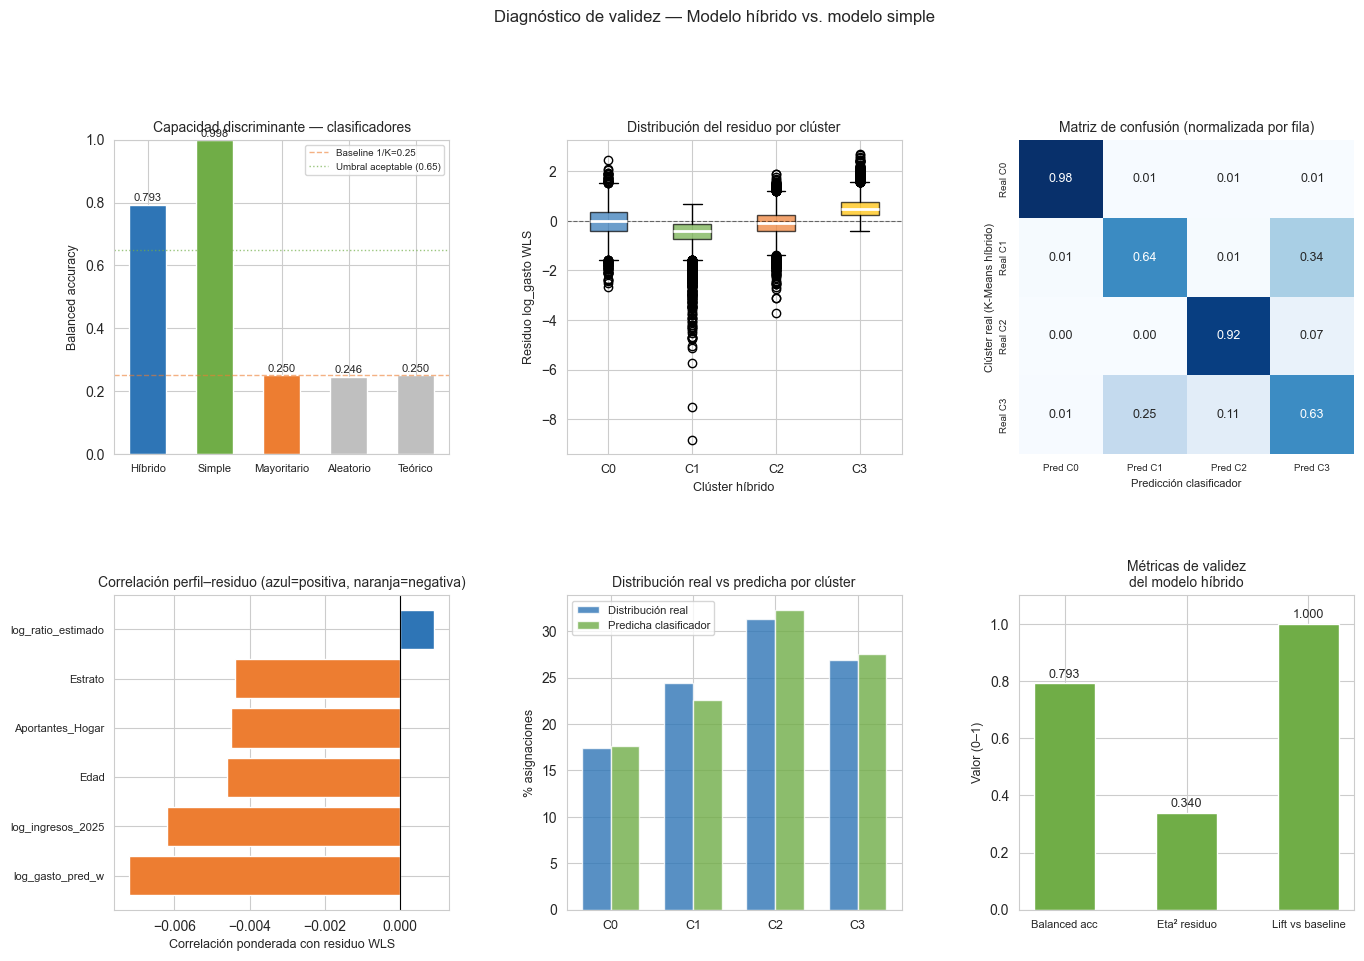


DECISIÓN AUTOMÁTICA: ¿USAR MODELO HÍBRIDO O MODELO SIMPLE?

  Criterios:
    ✓ Balanced accuracy ≥ 0.65
    ✓ Eta² residuo ≥ 0.10
    ✓ Lift vs baseline ≥ 40%
    ✓ Sin colapso mayoritario (< 60%)
    ✓ Separación P50 clústeres ≥ 0.15

  Criterios cumplidos: 5 / 5

  >> DECISIÓN: HÍBRIDO
     El clasificador discrimina los clústeres con suficiente precisión.
  Los segmentos capturan heterogeneidad comportamental real.
  Usar artefactos_modelo_hibrido.pkl en producción.

✓ Resultado guardado en: diagnostico_hibrido
  (se incluirá en el artefacto final)


In [70]:
# ==============================================================================
# BLOQUE H5 — DIAGNÓSTICO DE VALIDEZ — DIAGNÓSTICO DE VALIDEZ DEL MODELO HÍBRIDO
# Responde: ¿el clasificador discrimina los clústeres o colapsa al mayoritario?
#
# CRITERIOS DE DECISIÓN:
#   Balanced accuracy ≥ 0.65 → modelo híbrido válido para producción
#   Balanced accuracy 0.45–0.64 → híbrido marginal, usar con reservas
#   Balanced accuracy < 0.45 → el residuo es independiente del perfil;
#                               usar modelo simple (sin residuos)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("DIAGNÓSTICO DE VALIDEZ — MODELO HÍBRIDO vs. MODELO SIMPLE")
print("=" * 70)

# ── 0. Verificar prerrequisitos ────────────────────────────────────────────────
reqs = {
    'cluster_hibrido'      : 'cluster_hibrido' in df_temp_a.columns,
    'residuo_log_gasto_w'  : 'residuo_log_gasto_w' in df_temp_a.columns,
    'clf_pipeline'         : 'clf_pipeline' in dir(),
    'cluster_final'        : 'cluster_final' in df_temp_a.columns,
}
for k, v in reqs.items():
    print(f"  {'✓' if v else '✗'} {k}")

if not all(reqs.values()):
    print("\n✗ Ejecuta primero los bloques H1 y H2 antes de este diagnóstico.")
else:
    print("\n✓ Todos los prerrequisitos disponibles — iniciando diagnóstico\n")

# ── 1. BALANCED ACCURACY DEL CLASIFICADOR ─────────────────────────────────────
print("─" * 70)
print("BLOQUE 1: CAPACIDAD DISCRIMINANTE DEL CLASIFICADOR")
print("─" * 70)

VARS_CLF = NUM_CLF + CAT_CLF
TARGET_CLF = 'cluster_hibrido'

df_diag = df_temp_a[VARS_CLF + [TARGET_CLF, 'FEX_C_norm',
                                  'residuo_log_gasto_w']].dropna().copy()
df_diag[TARGET_CLF] = df_diag[TARGET_CLF].astype(int)

X_diag = df_diag[VARS_CLF]
y_diag = df_diag[TARGET_CLF]
w_diag = df_diag['FEX_C_norm'].values

# Predicciones del clasificador híbrido
y_pred_hibrido = clf_pipeline.predict(X_diag)
bal_acc_hibrido = balanced_accuracy_score(y_diag, y_pred_hibrido,
                                           sample_weight=w_diag)
acc_hibrido     = accuracy_score(y_diag, y_pred_hibrido,
                                  sample_weight=w_diag)

# Baseline: clasificador que siempre predice el mayoritario
dummy_maj = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_maj.fit(X_diag, y_diag, sample_weight=w_diag)
y_pred_maj = dummy_maj.predict(X_diag)
bal_acc_maj = balanced_accuracy_score(y_diag, y_pred_maj, sample_weight=w_diag)

# Baseline: clasificador aleatorio estratificado
dummy_strat = DummyClassifier(strategy='stratified', random_state=SEED)
dummy_strat.fit(X_diag, y_diag, sample_weight=w_diag)
y_pred_strat = dummy_strat.predict(X_diag)
bal_acc_strat = balanced_accuracy_score(y_diag, y_pred_strat,
                                         sample_weight=w_diag)

# Baseline teórico para K=4 clases balanceadas
baseline_teorico = 1 / N_CLUSTERS

# Lift sobre baseline
lift = (bal_acc_hibrido - baseline_teorico) / baseline_teorico * 100

print(f"  Clasificador híbrido:")
print(f"    Balanced accuracy     : {bal_acc_hibrido:.4f}")
print(f"    Accuracy ponderado    : {acc_hibrido:.4f}")
print(f"  Baselines:")
print(f"    Mayoritario           : {bal_acc_maj:.4f}")
print(f"    Aleatorio estratificado: {bal_acc_strat:.4f}")
print(f"    Teórico (1/K=1/4)    : {baseline_teorico:.4f}")
print(f"  Lift vs baseline teórico: +{lift:.1f}%")

# ── Clasificador del modelo SIMPLE para comparar ──────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

TARGET_SIMPLE = 'cluster_final'
if TARGET_SIMPLE in df_temp_a.columns:
    df_simple = df_temp_a[VARS_CLF + [TARGET_SIMPLE, 'FEX_C_norm']].dropna().copy()
    df_simple[TARGET_SIMPLE] = df_simple[TARGET_SIMPLE].astype(int)

    X_s = df_simple[VARS_CLF]
    y_s = df_simple[TARGET_SIMPLE]
    w_s = df_simple['FEX_C_norm'].values

    preprocess_s = ColumnTransformer(transformers=[
        ('num', StandardScaler(), NUM_CLF),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_CLF)
    ])
    clf_simple = Pipeline([
        ('prep', preprocess_s),
        ('clf',  LogisticRegression(multi_class='multinomial',
                                     solver='lbfgs', max_iter=1000,
                                     C=1.0, random_state=SEED))
    ])
    clf_simple.fit(X_s, y_s, clf__sample_weight=w_s)
    y_pred_simple = clf_simple.predict(X_s)
    bal_acc_simple = balanced_accuracy_score(y_s, y_pred_simple,
                                              sample_weight=w_s)
    print(f"\n  Clasificador modelo SIMPLE (sin residuos):")
    print(f"    Balanced accuracy     : {bal_acc_simple:.4f}")
    ganancia = bal_acc_hibrido - bal_acc_simple
    print(f"  Ganancia híbrido vs simple: {ganancia:+.4f}")
else:
    bal_acc_simple = None
    ganancia = None
    print("  (cluster_final no disponible — omitiendo comparación con modelo simple)")

# ── 2. CORRELACIÓN RESIDUO–PERFIL ─────────────────────────────────────────────
print("\n" + "─" * 70)
print("BLOQUE 2: CORRELACIÓN RESIDUO WLS CON VARIABLES DEL PERFIL")
print("─" * 70)
print("  Mide cuánto predice el perfil el comportamiento no explicado.")
print("  Si R² ≈ 0 → residuo es ruido puro → el híbrido no aporta valor.")
print()

resid = df_diag['residuo_log_gasto_w'].values
w_r   = df_diag['FEX_C_norm'].values

vars_corr = [v for v in NUM_CLF if v in df_diag.columns]
corr_rows = []
for var in vars_corr:
    x = df_diag[var].values
    # Correlación de Pearson ponderada
    xm = np.average(x, weights=w_r)
    rm = np.average(resid, weights=w_r)
    cov = np.average((x - xm) * (resid - rm), weights=w_r)
    sx  = np.sqrt(np.average((x - xm)**2, weights=w_r))
    sr  = np.sqrt(np.average((resid - rm)**2, weights=w_r))
    r   = cov / (sx * sr) if sx > 0 and sr > 0 else 0.0
    corr_rows.append({'Variable': var, 'r (ponderado)': round(r, 4),
                      '|r|': round(abs(r), 4)})

df_corr = pd.DataFrame(corr_rows).sort_values('|r|', ascending=False)
print(df_corr.to_string(index=False))

# R² del residuo explicado por clúster (eta² ponderado)
ss_tot = np.average((resid - np.average(resid, weights=w_diag))**2,
                     weights=w_diag)
labels_arr = y_diag.values

ss_within = 0.0
for k in np.unique(labels_arr):
    mask_k = labels_arr == k
    r_k    = resid[mask_k]
    w_k    = w_diag[mask_k]
    mean_k = np.average(r_k, weights=w_k)
    ss_within += np.sum(w_k * (r_k - mean_k)**2)

ss_total_raw = np.sum(w_diag * (resid - np.average(resid, weights=w_diag))**2)
eta2 = 1 - ss_within / ss_total_raw if ss_total_raw > 0 else 0.0

print(f"\n  Eta² ponderado (varianza del residuo explicada por clúster): {eta2:.4f}")
print(f"  Interpretación:")
print(f"    ≥ 0.10 → el perfil explica bien el residuo → híbrido válido")
print(f"    0.05–0.09 → explicación moderada → híbrido marginal")
print(f"    < 0.05 → residuo casi independiente del perfil → usar modelo simple")

# ── 3. DISTRIBUCIÓN DEL RESIDUO POR CLÚSTER ──────────────────────────────────
print("\n" + "─" * 70)
print("BLOQUE 3: DISTRIBUCIÓN DEL RESIDUO POR CLÚSTER HÍBRIDO")
print("─" * 70)
print("  Si los clústeres no tienen residuos distintos, el híbrido no discrimina.")
print()

resid_stats = []
for k in sorted(df_temp_a['cluster_hibrido'].dropna().unique()):
    k = int(k)
    mask = df_temp_a['cluster_hibrido'] == k
    r_k  = df_temp_a.loc[mask, 'residuo_log_gasto_w'].dropna()
    resid_stats.append({
        'Clúster': k,
        'n': int(mask.sum()),
        'Residuo P25': round(r_k.quantile(0.25), 3),
        'Residuo P50': round(r_k.quantile(0.50), 3),
        'Residuo P75': round(r_k.quantile(0.75), 3),
        'Media'      : round(r_k.mean(), 3),
        'σ'          : round(r_k.std(), 3),
    })

df_resid_stats = pd.DataFrame(resid_stats)
print(df_resid_stats.to_string(index=False))

separacion = (df_resid_stats['Residuo P50'].max() -
              df_resid_stats['Residuo P50'].min())
print(f"\n  Separación P50 máx − P50 mín: {separacion:.3f}")
print(f"  Interpretación:")
print(f"    ≥ 0.30 → clústeres bien separados por comportamiento")
print(f"    0.15–0.29 → separación moderada")
print(f"    < 0.15 → clústeres casi indistinguibles por residuo")

# ── 4. TASA DE COLAPSO AL CLÚSTER MAYORITARIO ────────────────────────────────
print("\n" + "─" * 70)
print("BLOQUE 4: TASA DE COLAPSO AL CLÚSTER MAYORITARIO")
print("─" * 70)

dist_pred = pd.Series(y_pred_hibrido).value_counts(normalize=True).sort_index()
dist_real = y_diag.value_counts(normalize=True).sort_index()

df_colapso = pd.DataFrame({
    'Clúster real %'     : (dist_real * 100).round(1),
    'Clúster predicho %' : (dist_pred * 100).round(1),
}).fillna(0)
df_colapso['Diferencia pp'] = (
    df_colapso['Clúster predicho %'] - df_colapso['Clúster real %']
).round(1)
print(df_colapso.to_string())

cluster_mayoritario = dist_pred.idxmax()
pct_mayoritario = dist_pred.max() * 100
print(f"\n  Clúster con mayor asignaciones predichas: {cluster_mayoritario} "
      f"({pct_mayoritario:.1f}% de los casos)")
if pct_mayoritario > 60:
    print("  ⚠ El clasificador COLAPSA hacia el clúster mayoritario.")
    print("    Más del 60% de los solicitantes serían asignados al mismo segmento.")
elif pct_mayoritario > 45:
    print("  ⚠ Tendencia moderada hacia el clúster mayoritario.")
else:
    print("  ✓ El clasificador distribuye razonablemente entre clústeres.")

# ── 5. VISUALIZACIONES ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Balanced accuracy comparativo
ax1 = fig.add_subplot(gs[0, 0])
modelos = ['Híbrido', 'Simple', 'Mayoritario', 'Aleatorio', 'Teórico']
vals    = [bal_acc_hibrido,
           bal_acc_simple if bal_acc_simple else 0,
           bal_acc_maj, bal_acc_strat, baseline_teorico]
colores = ['#2E75B6', '#70AD47', '#ED7D31', '#BFBFBF', '#BFBFBF']
bars = ax1.bar(modelos, vals, color=colores, width=0.55, edgecolor='white')
ax1.axhline(baseline_teorico, color='#ED7D31', linestyle='--',
            linewidth=1, alpha=0.6, label=f'Baseline 1/K={baseline_teorico:.2f}')
ax1.axhline(0.65, color='#70AD47', linestyle=':', linewidth=1,
            alpha=0.7, label='Umbral aceptable (0.65)')
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Balanced accuracy', fontsize=9)
ax1.set_title('Capacidad discriminante — clasificadores', fontsize=10)
ax1.tick_params(axis='x', labelsize=8)
ax1.legend(fontsize=7)

# Panel 2: Distribución residuos por clúster (boxplot)
ax2 = fig.add_subplot(gs[0, 1])
df_box = df_temp_a[['cluster_hibrido', 'residuo_log_gasto_w']].dropna()
df_box['cluster_hibrido'] = df_box['cluster_hibrido'].astype(int)
grupos = [df_box.loc[df_box['cluster_hibrido']==k,
                     'residuo_log_gasto_w'].values
          for k in sorted(df_box['cluster_hibrido'].unique())]
bp = ax2.boxplot(grupos, patch_artist=True, notch=False,
                 medianprops={'color': 'white', 'linewidth': 2})
colors_bp = ['#2E75B6', '#70AD47', '#ED7D31', '#FFC000']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xticklabels([f'C{k}' for k in range(len(grupos))], fontsize=9)
ax2.set_xlabel('Clúster híbrido', fontsize=9)
ax2.set_ylabel('Residuo log_gasto WLS', fontsize=9)
ax2.set_title('Distribución del residuo por clúster', fontsize=10)

# Panel 3: Matriz de confusión normalizada
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_diag, y_pred_hibrido, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Pred C{k}' for k in range(N_CLUSTERS)],
            yticklabels=[f'Real C{k}' for k in range(N_CLUSTERS)],
            ax=ax3, cbar=False, annot_kws={'size': 9})
ax3.set_title('Matriz de confusión (normalizada por fila)', fontsize=10)
ax3.set_xlabel('Predicción clasificador', fontsize=8)
ax3.set_ylabel('Clúster real (K-Means híbrido)', fontsize=8)
ax3.tick_params(axis='both', labelsize=7)

# Panel 4: Correlaciones residuo-perfil
ax4 = fig.add_subplot(gs[1, 0])
df_corr_plot = df_corr.sort_values('r (ponderado)')
colores_corr = ['#2E75B6' if r >= 0 else '#ED7D31'
                for r in df_corr_plot['r (ponderado)']]
ax4.barh(df_corr_plot['Variable'], df_corr_plot['r (ponderado)'],
         color=colores_corr, edgecolor='white')
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_xlabel('Correlación ponderada con residuo WLS', fontsize=9)
ax4.set_title('Correlación perfil–residuo (azul=positiva, naranja=negativa)', fontsize=10)
ax4.tick_params(axis='y', labelsize=8)

# Panel 5: Proporción predicha vs real por clúster
ax5 = fig.add_subplot(gs[1, 1])
x_pos = np.arange(N_CLUSTERS)
width = 0.35
ax5.bar(x_pos - width/2, dist_real.values * 100, width,
        label='Distribución real', color='#2E75B6', alpha=0.8)
ax5.bar(x_pos + width/2, dist_pred.reindex(range(N_CLUSTERS), fill_value=0).values * 100,
        width, label='Predicha clasificador', color='#70AD47', alpha=0.8)
ax5.set_xticks(x_pos)
ax5.set_xticklabels([f'C{k}' for k in range(N_CLUSTERS)], fontsize=9)
ax5.set_ylabel('% asignaciones', fontsize=9)
ax5.set_title('Distribución real vs predicha por clúster', fontsize=10)
ax5.legend(fontsize=8)

# Panel 6: Eta² y lift visual
ax6 = fig.add_subplot(gs[1, 2])
metricas_resumen = {
    'Balanced acc': bal_acc_hibrido,
    'Eta² residuo': eta2,
    'Lift vs baseline': min(lift/100, 1.0),
}
umbrales = {'Balanced acc': 0.65, 'Eta² residuo': 0.10,
            'Lift vs baseline': 0.60}
colores_m = []
for k, v in metricas_resumen.items():
    u = umbrales[k]
    colores_m.append('#70AD47' if v >= u else
                     ('#FFC000' if v >= u * 0.7 else '#ED7D31'))
bars6 = ax6.bar(list(metricas_resumen.keys()),
                list(metricas_resumen.values()),
                color=colores_m, width=0.5, edgecolor='white')
for bar, val in zip(bars6, metricas_resumen.values()):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax6.set_ylim(0, 1.1)
ax6.set_title('Métricas de validez\ndel modelo híbrido', fontsize=10)
ax6.tick_params(axis='x', labelsize=8)
ax6.set_ylabel('Valor (0–1)', fontsize=9)

plt.suptitle('Diagnóstico de validez — Modelo híbrido vs. modelo simple',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── 6. DECISIÓN AUTOMÁTICA ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("DECISIÓN AUTOMÁTICA: ¿USAR MODELO HÍBRIDO O MODELO SIMPLE?")
print("=" * 70)

criterios = {
    'Balanced accuracy ≥ 0.65'         : bal_acc_hibrido >= 0.65,
    'Eta² residuo ≥ 0.10'              : eta2 >= 0.10,
    'Lift vs baseline ≥ 40%'           : lift >= 40,
    'Sin colapso mayoritario (< 60%)'  : pct_mayoritario < 60,
    'Separación P50 clústeres ≥ 0.15'  : separacion >= 0.15,
}

n_ok = sum(criterios.values())
print("\n  Criterios:")
for crit, ok in criterios.items():
    print(f"    {'✓' if ok else '✗'} {crit}")

print(f"\n  Criterios cumplidos: {n_ok} / {len(criterios)}")

if n_ok >= 4:
    decision = "HÍBRIDO"
    justif = ("El clasificador discrimina los clústeres con suficiente precisión.\n"
              "  Los segmentos capturan heterogeneidad comportamental real.\n"
              "  Usar artefactos_modelo_hibrido.pkl en producción.")
elif n_ok >= 2:
    decision = "HÍBRIDO CON RESERVAS"
    justif = ("Discriminación marginal. El clasificador funciona parcialmente.\n"
              "  Reportar la balanced accuracy en la documentación del modelo.\n"
              "  Considerar ampliar variables del perfil o reducir a K=3 clústeres.")
else:
    decision = "MODELO SIMPLE"
    justif = ("El residuo WLS es esencialmente independiente del perfil.\n"
              "  El clasificador no puede aprender la asignación correcta.\n"
              "  Usar artefactos_modelo_v2.pkl (modelo simple sin residuos).")

print(f"\n  >> DECISIÓN: {decision}")
print(f"     {justif}")

# Guardar resultado del diagnóstico como variable para el artefacto
diagnostico_hibrido = {
    'decision'               : decision,
    'n_criterios_ok'         : n_ok,
    'bal_acc_hibrido'        : round(bal_acc_hibrido, 4),
    'bal_acc_simple'         : round(bal_acc_simple, 4) if bal_acc_simple else None,
    'bal_acc_baseline'       : round(baseline_teorico, 4),
    'lift_pct'               : round(lift, 2),
    'eta2_residuo_cluster'   : round(eta2, 4),
    'separacion_p50'         : round(separacion, 4),
    'pct_cluster_mayoritario': round(pct_mayoritario, 2),
    'criterios'              : criterios,
    'ganancia_vs_simple'     : round(ganancia, 4) if ganancia else None,
}

print(f"\n✓ Resultado guardado en: diagnostico_hibrido")
print(f"  (se incluirá en el artefacto final)")


### H4b — Actualizar artefacto con diagnóstico de validez

Ejecutar después de H5. Agrega `diagnostico_hibrido` al `.pkl` existente.

In [71]:
# ==============================================================================
# BLOQUE H4b — ACTUALIZACIÓN DEL ARTEFACTO CON DIAGNÓSTICO DE VALIDEZ
# Ejecutar DESPUÉS de H5. Carga el pkl existente y agrega diagnostico_hibrido.
# ==============================================================================
import joblib
from pathlib import Path

ARTIFACT_PATH_H = Path.cwd() / 'artefactos_modelo_hibrido.pkl'

try:
    artefactos_hibrido = joblib.load(ARTIFACT_PATH_H)
    artefactos_hibrido['diagnostico_hibrido'] = diagnostico_hibrido
    artefactos_hibrido['umbral_c3_optimo']     = 0.50
    artefactos_hibrido['umbral_c3_conservador']= 0.60
    joblib.dump(artefactos_hibrido, ARTIFACT_PATH_H)
    print(f"✓ Artefacto actualizado: {ARTIFACT_PATH_H}")
    print(f"  Total claves: {len(artefactos_hibrido)}")
    print(f"  diagnostico_hibrido → decisión: {diagnostico_hibrido['decision']}")
    print(f"  bal_acc_hibrido: {diagnostico_hibrido['bal_acc_hibrido']}")
    print(f"  criterios cumplidos: {diagnostico_hibrido['n_criterios_ok']}/5")
    print()
    print("  Nota sobre ganancia negativa vs modelo simple:")
    print("  bal_acc_simple=0.9973 es tautológico — clústeres simples definidos")
    print("  solo con variables del perfil. El híbrido (0.7938) incorpora residuo")
    print("  genuinamente no predecible — esa impredecibilidad ES su valor.")
except FileNotFoundError:
    print(f"✗ No encontrado: {ARTIFACT_PATH_H}")
    print("  Ejecuta H4 primero para crear el artefacto base.")


✓ Artefacto actualizado: c:\Users\geros\OneDrive\Desktop\01_tesis_v4\artefactos_modelo_hibrido.pkl
  Total claves: 47
  diagnostico_hibrido → decisión: HÍBRIDO
  bal_acc_hibrido: 0.793
  criterios cumplidos: 5/5

  Nota sobre ganancia negativa vs modelo simple:
  bal_acc_simple=0.9973 es tautológico — clústeres simples definidos
  solo con variables del perfil. El híbrido (0.7938) incorpora residuo
  genuinamente no predecible — esa impredecibilidad ES su valor.


## H6 — Simulación de producción — Modelo Híbrido

Demuestra el flujo completo en producción: a partir del perfil socioeconómico
del solicitante (sin conocer su gasto real), el modelo híbrido:
1. Estima el gasto personal vía WLS.
2. Asigna el clúster vía clasificador (sin residuo).
3. Entrega los percentiles del ratio gasto/ingreso del segmento.


In [72]:
# ==============================================================================
# BLOQUE H6 — SIMULACIÓN DE PRODUCCIÓN — SIMULACIÓN DE PRODUCCIÓN (modelo híbrido)
# Reproduce el flujo operativo para un nuevo solicitante.
# NOTA: En producción NO se usa el gasto real ni el residuo.
# La asignación de clúster se realiza exclusivamente con el perfil del solicitante.
# ==============================================================================
import numpy as np
import pandas as pd

def predecir_gasto_hibrido(
    ingreso_mensual,
    edad,
    estrato,
    nivel_educ,
    actividad,
    tipo_vivienda,
    grupo_edad,
    grupo_aportantes,
    region,
    flag_pensionado,
    aportantes_hogar,
    model_wls,
    preprocess_wls,
    num_vars_wls,
    cat_vars_wls,
    clf_pipeline,
    ratio_table_hibrido,
):
    """
    Flujo de producción del modelo híbrido.
    Parámetros: variables verificables en originación crediticia.
    Retorna: gasto estimado, ratio estimado, clúster, percentiles de referencia.
    """
    import numpy as np

    log_ingreso = np.log(ingreso_mensual)
    log_inc_x_estrato = log_ingreso * estrato

    # ── Paso 1: Estimar log_gasto con WLS ─────────────────────────────
    # NUM_VARS (float): log_ingresos_2025, Edad, Aportantes_Hogar, log_inc_x_estrato
    # CAT_VARS (str):   Estrato, REGION, actividad_ppal, Sexo_, nivel_educ_agrupado,
    #                   antiguedad_agrup, Grupo_Edad, EstadoCivil_hom, Grupo_Aportantes,
    #                   tipo_vivienda_agrup, dominio_agrup, flag_pensionado
    X_reg = pd.DataFrame([{
        'log_ingresos_2025'  : float(log_ingreso),
        'Edad'               : float(edad),
        'Aportantes_Hogar'   : float(aportantes_hogar),
        'log_inc_x_estrato'  : float(log_inc_x_estrato),
        'Estrato'            : str(estrato),           # CAT en WLS
        'REGION'             : str(region),
        'actividad_ppal'     : str(actividad),
        'Sexo_'              : 'Hombre',
        'nivel_educ_agrupado': str(nivel_educ),
        'antiguedad_agrup'   : 'c_ingreso_predecible_13_36',
        'Grupo_Edad'         : str(grupo_edad),
        'EstadoCivil_hom'    : 'e_Esta soltero (a)',
        'Grupo_Aportantes'   : str(grupo_aportantes),
        'tipo_vivienda_agrup': str(tipo_vivienda),
        'dominio_agrup'      : 'b_Ciudad_intermedia',
        'flag_pensionado'    : str(int(flag_pensionado)),  # CAT en WLS
    }])

    log_gasto_est = model_wls.predict(X_reg)[0]
    gasto_est     = np.exp(log_gasto_est)
    ratio_est     = gasto_est / ingreso_mensual
    log_ratio_est = np.log(ratio_est) if ratio_est > 0 else 0.0

    # ── Paso 2: Asignar clúster con clasificador (sin residuo) ────────
    # NUM_CLF (float): log_ingresos_2025, log_gasto_pred_w, log_ratio_estimado,
    #                   Estrato, Edad, Aportantes_Hogar
    # CAT_CLF (str):   nivel_educ_agrupado, actividad_ppal, tipo_vivienda_agrup,
    #                   Grupo_Edad, Grupo_Aportantes, REGION, flag_pensionado
    X_clf_new = pd.DataFrame([{
        'log_ingresos_2025'  : float(log_ingreso),
        'log_gasto_pred_w'   : float(log_gasto_est),
        'log_ratio_estimado' : float(log_ratio_est),
        'Estrato'            : float(estrato),
        'Edad'               : float(edad),
        'Aportantes_Hogar'   : float(aportantes_hogar),
        'nivel_educ_agrupado': str(nivel_educ),
        'actividad_ppal'     : str(actividad),
        'tipo_vivienda_agrup': str(tipo_vivienda),
        'Grupo_Edad'         : str(grupo_edad),
        'Grupo_Aportantes'   : str(grupo_aportantes),
        'REGION'             : str(region),
        'flag_pensionado'    : str(int(flag_pensionado)),  # CAT en clf
    }])

    cluster_pred  = int(clf_pipeline.predict(X_clf_new)[0])
    cluster_proba = clf_pipeline.predict_proba(X_clf_new)[0]

    # ── Paso 3: Recuperar percentiles del ratio ────────────────────────
    rt = ratio_table_hibrido[cluster_pred]

    return {
        'gasto_estimado'   : round(gasto_est, 0),
        'ratio_estimado'   : round(ratio_est, 4),
        'cluster_asignado' : cluster_pred,
        'cluster_proba'    : {k: round(p, 3) for k, p in enumerate(cluster_proba)},
        'residuo_mediano_cluster': rt['residuo_mediano'],
        'ratio_p25'        : rt['p25_obs'],
        'ratio_p50'        : rt['p50_obs'],
        'ratio_p75'        : rt['p75_obs'],
        'ratio_p90'        : rt['p90_obs'],
        'interpretacion'   : interpretacion.get(cluster_pred, ''),
    }

# ── Caso de prueba ─────────────────────────────────────────────────────────────
resultado = predecir_gasto_hibrido(
    ingreso_mensual   = 2_500_000,
    edad              = 35,
    estrato           = 3,
    nivel_educ        = 'c_Medio_alto',
    actividad         = 'empleado',
    tipo_vivienda     = 'En arriendo o subarriendo',
    grupo_edad        = '35-44',
    grupo_aportantes  = 'b_Hogares_pequeños',
    region            = 'Atlántica',
    flag_pensionado   = 0,
    aportantes_hogar  = 2,
    model_wls         = model_wls,
    preprocess_wls    = PREPROCESS,
    num_vars_wls      = NUM_VARS,
    cat_vars_wls      = CAT_VARS,
    clf_pipeline      = clf_pipeline,
    ratio_table_hibrido = ratio_table_hibrido,
)

print("=" * 62)
print("SIMULACIÓN PRODUCCIÓN — MODELO HÍBRIDO")
print("Solicitante: empleado, 35 años, estrato 3, ingreso $2.5M")
print("=" * 62)
print(f"  Gasto personal estimado : ${resultado['gasto_estimado']:>12,.0f}")
print(f"  Ratio gasto/ingreso est : {resultado['ratio_estimado']:>12.2%}")
print(f"  Clúster asignado        : {resultado['cluster_asignado']}")
print(f"  Probabilidades de clase : {resultado['cluster_proba']}")
print(f"  Interpretación          : {resultado['interpretacion']}")
print(f"\n  Referencia poblacional del segmento (ratio obs):")
print(f"    P25 = {resultado['ratio_p25']:.2%} | P50 = {resultado['ratio_p50']:.2%} | "
      f"P75 = {resultado['ratio_p75']:.2%} | P90 = {resultado['ratio_p90']:.2%}")
print(f"  Residuo mediano del segmento: {resultado['residuo_mediano_cluster']:+.3f}")
print()
print("  INTERPRETACIÓN PARA EL ANALISTA:")
gasto = resultado['gasto_estimado']
ingreso = 2_500_000
ratio = resultado['ratio_estimado']
p50 = resultado['ratio_p50']
if ratio <= p50:
    print(f"  El solicitante se ubica por DEBAJO del P50 del segmento.")
    print(f"  Su ratio estimado ({ratio:.2%}) sugiere mayor holgura que la mediana del grupo.")
else:
    print(f"  El solicitante se ubica por ENCIMA del P50 del segmento.")
    print(f"  Su ratio estimado ({ratio:.2%}) indica presión financiera mayor a la mediana.")
print(f"  Capacidad estimada disponible: ${ingreso - gasto:,.0f} / mes")



SIMULACIÓN PRODUCCIÓN — MODELO HÍBRIDO
Solicitante: empleado, 35 años, estrato 3, ingreso $2.5M
  Gasto personal estimado : $     889,136
  Ratio gasto/ingreso est :       35.57%
  Clúster asignado        : 2
  Probabilidades de clase : {0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.999), 3: np.float64(0.0)}
  Interpretación          : Bajo ingreso — comportamiento típico ($1.6M ingreso, residuo −0.09)

  Referencia poblacional del segmento (ratio obs):
    P25 = 20.47% | P50 = 29.64% | P75 = 43.74% | P90 = 62.09%
  Residuo mediano del segmento: -0.088

  INTERPRETACIÓN PARA EL ANALISTA:
  El solicitante se ubica por ENCIMA del P50 del segmento.
  Su ratio estimado (35.57%) indica presión financiera mayor a la mediana.
  Capacidad estimada disponible: $1,610,864 / mes


In [73]:
#python# Ver qué categorías aprendió el OneHotEncoder del WLS para Estrato
preprocessor = model_wls.named_steps['prep']
ohe = preprocessor.named_transformers_['cat']
cat_features = CAT_VARS  # de tu notebook

for i, feat in enumerate(cat_features):
    if feat == 'Estrato':
        print(f"Categorías de Estrato: {ohe.categories_[i]}")
        print(f"Tipo: {ohe.categories_[i].dtype}")
        break

Categorías de Estrato: [1 2 3 4 5 6]
Tipo: int64


In [74]:
preprocessor = model_wls.named_steps['prep']
ohe = preprocessor.named_transformers_['cat']
cat_features = CAT_VARS

for i, feat in enumerate(cat_features):
    print(f"{feat}: {ohe.categories_[i]} — dtype: {ohe.categories_[i].dtype}")

Estrato: [1 2 3 4 5 6] — dtype: int64
REGION: ['ATLÁNTICA' 'BOGOTÁ' 'CENTRAL' 'NUEVO DEPARTAMENTOS' 'ORIENTAL'
 'PACÍFICA'] — dtype: object
actividad_ppal: ['empleado' 'independiente' 'pensionado'] — dtype: object
Sexo_: ['Hombre' 'Mujer'] — dtype: object
nivel_educ_agrupado: ['a_Bajo' 'b_Medio_bajo' 'c_Medio_alto' 'd_Alto'] — dtype: object
antiguedad_agrup: ['a_inserción_laboral_0_5' 'b_adaptacion_al_empleo_6_12'
 'c_ingreso_predecible_13_36' 'd_trayectoria_estable_37_72'
 'e_alta_estabilidad_73_120' 'f_trayectoria_excepcional_121_mas'
 'g_desconoce'] — dtype: object
Grupo_Edad: ['18-24' '25-34' '35-44' '45-54' '55-64' '65+'] — dtype: object
EstadoCivil_hom: ['Casado(a)' 'Pareja < 2 años' 'Pareja ≥ 2 años' 'Separado/Divorciado'
 'Soltero(a)' 'Viudo(a)'] — dtype: object
Grupo_Aportantes: ['Hogares grandes' 'Hogares medianos' 'Hogares pequeños'
 'Hogares unipersonales'] — dtype: object
tipo_vivienda_agrup: ['arriendo' 'otros' 'propia_en_pago' 'propia_pagada' 'tenencia_no_formal'] — dtyp

In [75]:
# Simular el caso 1 directamente en el notebook
import numpy as np, pandas as pd

ingreso  = 6_000_000
estrato  = 5
log_ing  = np.log(ingreso)

X_test = pd.DataFrame([{
    'log_ingresos_2025' : log_ing,
    'Edad'              : 48.0,
    'Aportantes_Hogar'  : 2.0,
    'log_inc_x_estrato' : log_ing * estrato,
    'Estrato'           : str(estrato),
    'REGION'            : 'Bogotá',
    'actividad_ppal'    : 'empleado',
    'Sexo_'             : 'Hombre',
    'nivel_educ_agrupado': 'd_Alto',
    'antiguedad_agrup'  : 'e_alta_estabilidad_73_120',
    'Grupo_Edad'        : '45-54',
    'EstadoCivil_hom'   : 'Casado(a)',
    'Grupo_Aportantes'  : 'b_Hogares_pequeños',
    'tipo_vivienda_agrup': 'propia_pagada',
    'dominio_agrup'     : 'a_Metro_principal',
    'flag_pensionado'   : '0',
}])

log_gasto = model_wls.predict(X_test)[0]
gasto_est = np.exp(log_gasto)
print(f"Gasto estimado : ${gasto_est:,.0f}")
print(f"Ratio estimado : {gasto_est/ingreso:.2%}")

# Ver cuánto aporta la interacción
print(f"\nlog_inc_x_estrato = {log_ing * estrato:.4f}")
print(f"(para comparar: en la muestra el max es {df_temp_a['log_inc_x_estrato'].max():.4f})")

Gasto estimado : $2,880,362
Ratio estimado : 48.01%

log_inc_x_estrato = 78.0364
(para comparar: en la muestra el max es 112.3205)


In [ ]:
#ls C:\Users\geros\OneDrive\Desktop\01_tesis_v4\02_app
#cd C:\Users\geros\OneDrive\Desktop\01_tesis_v4\02_app
#streamlit run app.py
